###**Importing Essential Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import zscore
import os
import math
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_predict
from xgboost import XGBClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/datasets/final_df.csv")
df.head()

Mounted at /content/drive


,id,age,year,sex,part,job,study_hours,health,therapy,total_empathy,...,burnout_cynicism,burnout_efficacy,age_capped,lang_final_French,lang_final_German,lang_final_Italian,lang_final_Other,depression_category,age_group_23_plus,study_group
0,2,18,1,0,1,0,56,3,0,88,...,13,20,18,0.0,0.0,0.0,1.0,1,False,high
1,4,26,4,0,1,0,20,4,0,109,...,11,26,26,1.0,0.0,0.0,0.0,0,True,moderate
2,9,21,3,1,0,0,36,3,0,106,...,7,23,21,1.0,0.0,0.0,0.0,1,False,high
3,10,21,2,1,0,1,51,5,0,101,...,10,21,21,1.0,0.0,0.0,0.0,0,False,high
4,13,21,3,0,1,0,22,4,0,102,...,14,23,21,1.0,0.0,0.0,0.0,0,False,moderate


In [ ]:
df = pd.get_dummies(df, columns=["study_group"], drop_first=True)
df

,id,age,year,sex,part,job,study_hours,health,therapy,total_empathy,...,burnout_efficacy,age_capped,lang_final_French,lang_final_German,lang_final_Italian,lang_final_Other,depression_category,age_group_23_plus,study_group_low,study_group_moderate
0,2,18,1,0,1,0,56,3,0,88,...,20,18,0.0,0.0,0.0,1.0,1,False,False,False
1,4,26,4,0,1,0,20,4,0,109,...,26,26,1.0,0.0,0.0,0.0,0,True,False,True
2,9,21,3,1,0,0,36,3,0,106,...,23,21,1.0,0.0,0.0,0.0,1,False,False,False
3,10,21,2,1,0,1,51,5,0,101,...,21,21,1.0,0.0,0.0,0.0,0,False,False,False
4,13,21,3,0,1,0,22,4,0,102,...,23,21,1.0,0.0,0.0,0.0,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876,1781,21,2,0,1,0,45,3,0,106,...,34,21,1.0,0.0,0.0,0.0,1,False,False,False
877,1785,20,2,1,0,0,13,3,0,113,...,24,20,1.0,0.0,0.0,0.0,1,False,True,False
878,1787,19,1,0,0,0,50,5,0,100,...,31,19,1.0,0.0,0.0,0.0,0,False,False,False
879,1789,24,5,1,0,0,20,2,1,120,...,19,24,1.0,0.0,0.0,0.0,1,True,False,True


## **Split Dataset**

In [ ]:
X = df[["age_capped", "age_group_23_plus", "year", "sex", "lang_final_French", "lang_final_German",
                "lang_final_Italian", "lang_final_Other", "part", "job",
                "study_hours", "study_group_low", "study_group_moderate", "health", "therapy", "total_empathy", "cog_empathy",
                "aff_empathy", "motivation", "emotion_rec_acc"]]

y = df[["depression_score", "depression_category", "anxiety_score", "burnout_exhaustion",
          "burnout_cynicism", "burnout_efficacy"]]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=20)


In [ ]:
print(f"train X shape: {X_train.shape}")
print(f"train y shape: {y_train.shape}")
print(f"test X shape: {X_test.shape}")
print(f"test y shape: {y_test.shape}")

train X shape: (660, 20)
train y shape: (660, 6)
test X shape: (221, 20)
test y shape: (221, 6)


## **Normalizing**

Scaling AFTER splitting

In [ ]:
X_train

,age_capped,age_group_23_plus,year,sex,lang_final_French,lang_final_German,lang_final_Italian,lang_final_Other,part,job,study_hours,study_group_low,study_group_moderate,health,therapy,total_empathy,cog_empathy,aff_empathy,motivation,emotion_rec_acc
730,21,False,3,1,1.0,0.0,0.0,0.0,0,0,30,False,True,3,0,103,62,40,26,0.833333
868,25,True,6,0,1.0,0.0,0.0,0.0,1,0,2,True,False,2,0,110,55,38,29,0.785714
30,23,True,4,1,1.0,0.0,0.0,0.0,1,1,7,True,False,4,1,104,64,39,26,0.833333
261,26,True,2,1,1.0,0.0,0.0,0.0,0,1,24,False,True,4,0,112,64,37,22,0.785714
788,22,False,3,1,0.0,1.0,0.0,0.0,1,1,30,False,True,5,0,118,62,35,30,0.595238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,22,False,2,1,0.0,0.0,0.0,1.0,1,0,30,False,True,4,0,115,59,32,21,0.690476
223,23,True,6,1,1.0,0.0,0.0,0.0,1,0,6,True,False,4,1,109,67,44,26,0.904762
271,27,True,6,0,0.0,1.0,0.0,0.0,0,1,0,False,False,5,0,94,64,35,25,0.619048
474,21,False,1,1,0.0,0.0,0.0,1.0,1,1,30,False,True,4,0,98,61,30,34,0.761905


In [ ]:
X_train_orig = X_train.copy()
X_test_orig = X_test.copy()

In [ ]:
num_cols = ["age_capped", "study_hours", "total_empathy",
            "cog_empathy", "aff_empathy",
            "motivation", "emotion_rec_acc"]
cat_cols = ["year", "sex", "lang_final_French", "lang_final_German",
            "lang_final_Italian", "lang_final_Other", "part", "job", "health", "therapy"]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
X_train

,age_capped,age_group_23_plus,year,sex,lang_final_French,lang_final_German,lang_final_Italian,lang_final_Other,part,job,study_hours,study_group_low,study_group_moderate,health,therapy,total_empathy,cog_empathy,aff_empathy,motivation,emotion_rec_acc
730,-0.414655,False,3,1,1.0,0.0,0.0,0.0,0,0,0.270040,False,True,3,0,-0.369671,0.499420,0.987109,0.555045,1.203187
868,0.893217,True,6,0,1.0,0.0,0.0,0.0,1,0,-1.461513,True,False,2,0,0.428404,-0.546035,0.611176,1.158554,0.687536
30,0.239281,True,4,1,1.0,0.0,0.0,0.0,1,1,-1.152307,True,False,4,1,-0.255661,0.798121,0.799143,0.555045,1.203187
261,1.220185,True,2,1,1.0,0.0,0.0,0.0,0,1,-0.101007,False,True,4,0,0.656426,0.798121,0.423210,-0.249633,0.687536
788,-0.087687,False,3,1,0.0,1.0,0.0,0.0,1,1,0.270040,False,True,5,0,1.340491,0.499420,0.047276,1.359724,-1.375071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,-0.087687,False,2,1,0.0,0.0,0.0,1.0,1,0,0.270040,False,True,4,0,0.998458,0.051368,-0.516623,-0.450803,-0.343768
223,0.239281,True,6,1,1.0,0.0,0.0,0.0,1,0,-1.214148,True,False,4,1,0.314393,1.246173,1.738976,0.555045,1.976665
271,1.547153,True,6,0,0.0,1.0,0.0,0.0,0,1,-1.585195,False,False,5,0,-1.395769,0.798121,0.047276,0.353876,-1.117245
474,-0.414655,False,1,1,0.0,0.0,0.0,1.0,1,1,0.270040,False,True,4,0,-0.939726,0.350069,-0.892556,2.164402,0.429710


In [ ]:
X_test

,age_capped,age_group_23_plus,year,sex,lang_final_French,lang_final_German,lang_final_Italian,lang_final_Other,part,job,study_hours,study_group_low,study_group_moderate,health,therapy,total_empathy,cog_empathy,aff_empathy,motivation,emotion_rec_acc
347,0.239281,True,5,1,1.0,0.0,0.0,0.0,1,0,-0.657578,True,False,5,0,0.542415,0.350069,0.611176,-0.249633,1.203187
559,-0.087687,False,5,1,1.0,0.0,0.0,0.0,0,0,-0.657578,True,False,5,0,0.428404,0.051368,0.235243,0.756215,0.687536
785,0.239281,True,6,1,1.0,0.0,0.0,0.0,0,0,-1.214148,True,False,5,0,-1.395769,0.947472,0.235243,0.353876,-1.632897
828,0.239281,True,4,0,1.0,0.0,0.0,0.0,1,1,-0.224690,False,True,3,1,0.656426,-0.695386,-0.328657,-0.048464,0.945362
56,-1.068591,False,1,1,1.0,0.0,0.0,0.0,1,0,-0.101007,False,True,5,0,0.314393,-1.740841,0.423210,1.762063,1.203187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,-1.395558,False,1,0,1.0,0.0,0.0,0.0,0,0,0.517404,False,False,5,0,-0.369671,-0.396685,1.175076,-0.450803,-0.343768
63,-0.414655,False,3,0,1.0,0.0,0.0,0.0,1,0,-0.101007,False,True,4,0,0.542415,-0.844737,0.799143,-1.054312,-0.859420
178,0.239281,True,4,1,1.0,0.0,0.0,0.0,1,1,-0.657578,True,False,2,0,0.086372,-1.442140,0.611176,-1.858990,1.976665
791,0.893217,True,6,0,1.0,0.0,0.0,0.0,1,0,0.270040,False,True,5,0,0.998458,-0.396685,-0.140690,-1.054312,-3.437678


In [ ]:
range_df = X_train[num_cols].agg(['min', 'max']).T
range_df["range"] = range_df["max"] - range_df["min"]
range_df

,min,max,range
age_capped,-1.722526,4.162896,5.885422
study_hours,-1.585195,2.743686,4.328882
total_empathy,-4.474061,2.138567,6.612628
cog_empathy,-3.234349,2.440979,5.675328
aff_empathy,-3.148155,2.490842,5.638997
motivation,-3.468347,2.365572,5.833918
emotion_rec_acc,-3.437678,2.492317,5.929995


## **Training**

The goal is to use demographic and background features of students to predict their mental wellbeing.

We can train 3 models:
1. one that predicts depression
2. one for predicting anxiety
3. and lastly a multi-output regression model that predicts burn-out scores

In [ ]:
y_train[['depression_score','anxiety_score',"burnout_exhaustion", "burnout_cynicism"]].corr()


,depression_score,anxiety_score,burnout_exhaustion,burnout_cynicism
depression_score,1.000000,0.725637,0.633946,0.458207
anxiety_score,0.725637,1.000000,0.553297,0.365595
burnout_exhaustion,0.633946,0.553297,1.000000,0.522403
burnout_cynicism,0.458207,0.365595,0.522403,1.000000


Depression, anxiety, and burnout are highly correlated. If you include depression and anxiety to predict burnout:

- R² will increase (probably a lot)
- But interpretability changes
- You are partially predicting one distress measure using another

I think it's better if we don't include them, because our research question would be changed.

Possible Models to use:
- random forest
- xgboost
- linear regression
- SVR

In [ ]:
y_train_depression = y_train["depression_category"]
y_train_anxiety = (y_train['anxiety_score'] >= 44).astype(int)

**Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_cf_matrix(clf, y, y_pred):
    cm = confusion_matrix(y, y_pred, labels=clf.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=clf.classes_)
    disp.plot()
    plt.show()

**Training functions**

In [ ]:
def clf_train(model, model_name, X, y):
    print(f"-----------model: {model_name}-----------")

    scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    y_pred = cross_val_predict(model, X, y, cv=5)

    print(f"mean AUC: {scores.mean()}")
    print(classification_report(y, y_pred))

    model.fit(X, y)
    if hasattr(model, 'coef_'):
        importance = pd.Series(model.coef_[0], index=X.columns)
    elif hasattr(model, 'feature_importances_'):
        importance = pd.Series(model.feature_importances_, index=X.columns)
    else:
        print("No feature importance available for this model")
        return

    print("\nTop 10 features:")
    print(importance.abs().sort_values(ascending=False).head(10))

    plot_cf_matrix(model, y, y_pred)

    return model

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

def clf_train_smote(model, model_name, X, y):
    print(f"-----------model: {model_name}-----------")

    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   model)
    ])

    # AUC + predictions via cross validation (SMOTE only applied to train folds)
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc')
    y_pred = cross_val_predict(pipeline, X, y, cv=5)

    print(f"mean AUC: {scores.mean():.4f}")
    print(classification_report(y, y_pred))

    model.fit(X, y)
    if hasattr(model, 'coef_'):
        importance = pd.Series(model.coef_[0], index=X.columns)
    elif hasattr(model, 'feature_importances_'):
        importance = pd.Series(model.feature_importances_, index=X.columns)
    else:
        print("No feature importance available for this model")
        return

    print("\nTop 10 features:")
    print(importance.abs().sort_values(ascending=False).head(10))

    plot_cf_matrix(model, y, y_pred)

**Testing**

In [ ]:
def clf_test(model, model_name, X_train, y_train, X_test, y_test):
    print(f"-----------model: {model_name}-----------")

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, y_proba)
    cv_auc   = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc').mean()
    gap      = test_auc - cv_auc
    flag     = "check split" if abs(gap) > 0.05 else "✅"

    print(f"CV AUC:   {cv_auc:.4f}")
    print(f"Test AUC: {test_auc:.4f}")
    print(f"Gap:      {gap:+.4f}  {flag}")
    print(classification_report(y_test, y_pred))

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    RocCurveDisplay.from_predictions(
        y_test, y_proba,
        name=model_name, ax=axes[0]
    )
    axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
    axes[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['No', 'Yes']
    ).plot(ax=axes[1], colorbar=False, cmap='Blues')
    axes[1].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

    axes[2].bar(['CV AUC', 'Test AUC'], [cv_auc, test_auc],
                color=['#457B9D', '#E63946'], alpha=0.85,
                edgecolor='white', width=0.4)
    for i, val in enumerate([cv_auc, test_auc]):
        axes[2].text(i, val + 0.005, f'{val:.4f}', ha='center', fontweight='bold')
    axes[2].set_ylim(0.5, 0.85)
    axes[2].set_title('CV vs Test AUC', fontsize=12, fontweight='bold')
    axes[2].spines['top'].set_visible(False)
    axes[2].spines['right'].set_visible(False)
    axes[2].grid(axis='y', alpha=0.3)

    plt.suptitle(f'Test Results — {model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'test_{model_name.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()



### **1. How do demographic characteristics (sex, age, year of study, and mother tongue) and health traits relate to mental health outcomes depression among medical students in Switzerland?**

depression_category
0    59.023837
1    40.976163
Name: proportion, dtype: float64


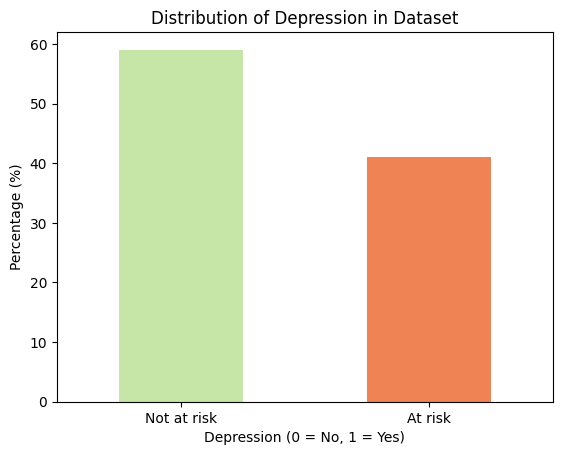

In [ ]:
percentages = df["depression_category"].value_counts(normalize=True) * 100
print(percentages)
plt.figure()
percentages.sort_index().plot(kind='bar', color=['#C5E6A6', '#EF8354'])

plt.xlabel("Depression (0 = No, 1 = Yes)")
plt.ylabel("Percentage (%)")
plt.title("Distribution of Depression in Dataset")

plt.xticks([0,1], ["Not at risk", "At risk"], rotation=0)

plt.show()

**Models**

In [ ]:
names = [
    "Logistic Regression",
    "Linear SVM",
    "Random Forest",
    "AdaBoost",
    "XGBoost"
]

classifiers = [
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    SVC(kernel="linear", C=0.025, probability=True, class_weight='balanced'),
    RandomForestClassifier(max_depth=10, n_estimators=50, class_weight='balanced'),
    AdaBoostClassifier(random_state=42),
    XGBClassifier(n_estimators=100, max_depth=3,
                  learning_rate=0.05, subsample=0.8,
                  eval_metric='auc', random_state=42),

]


**Training with all the features**

In [ ]:
X_train_selected = X_train[['age_capped', 'year', 'sex', 'lang_final_French',
       'lang_final_German', 'lang_final_Italian', 'lang_final_Other', 'part',
       'job', 'study_hours', 'health', 'therapy', 'total_empathy', 'cog_empathy', 'aff_empathy',
       'motivation', 'emotion_rec_acc']]

-----------model: Logistic Regression-----------
mean AUC: 0.7167351210707134
              precision    recall  f1-score   support

           0       0.74      0.69      0.71       398
           1       0.57      0.63      0.60       262

    accuracy                           0.67       660
   macro avg       0.65      0.66      0.66       660
weighted avg       0.67      0.67      0.67       660


Top 10 features:
therapy               1.056974
health                0.536377
part                  0.491111
aff_empathy           0.336040
year                  0.205541
lang_final_German     0.205303
sex                   0.173560
job                   0.143123
lang_final_Italian    0.133051
total_empathy         0.115578
dtype: float64


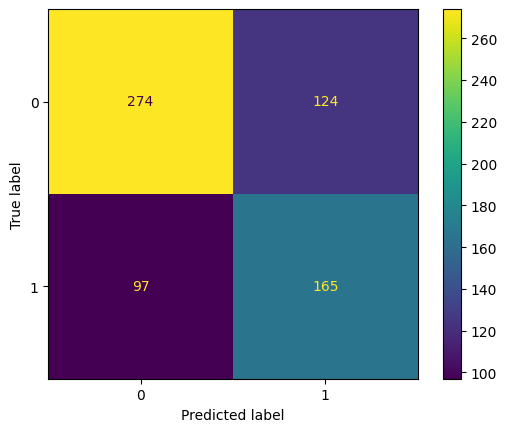

-----------model: Linear SVM-----------
mean AUC: 0.7149066478661057
              precision    recall  f1-score   support

           0       0.73      0.69      0.71       398
           1       0.56      0.61      0.59       262

    accuracy                           0.66       660
   macro avg       0.65      0.65      0.65       660
weighted avg       0.66      0.66      0.66       660


Top 10 features:
therapy            0.527129
health             0.510677
aff_empathy        0.286530
part               0.266201
year               0.161306
study_hours        0.154589
total_empathy      0.133548
job                0.101263
sex                0.081945
emotion_rec_acc    0.077357
dtype: float64


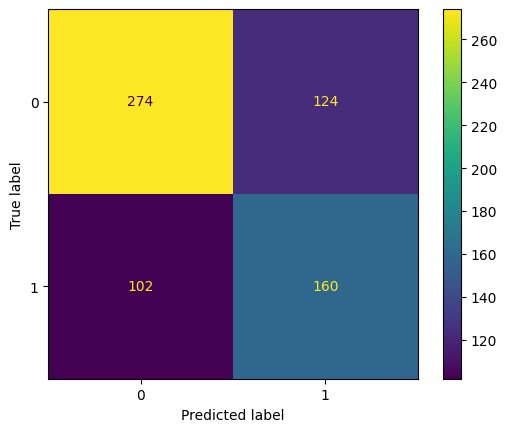

-----------model: Random Forest-----------
mean AUC: 0.6893591542503353
              precision    recall  f1-score   support

           0       0.68      0.78      0.73       398
           1       0.58      0.45      0.51       262

    accuracy                           0.65       660
   macro avg       0.63      0.62      0.62       660
weighted avg       0.64      0.65      0.64       660


Top 10 features:
health             0.128093
aff_empathy        0.110648
study_hours        0.107805
motivation         0.097564
total_empathy      0.095695
emotion_rec_acc    0.083925
cog_empathy        0.081675
age_capped         0.080852
year               0.060913
therapy            0.044661
dtype: float64


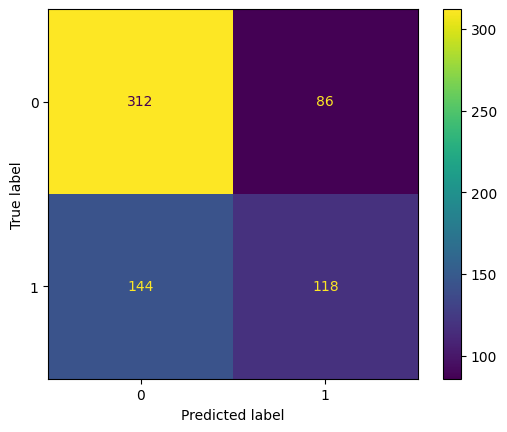

-----------model: AdaBoost-----------
mean AUC: 0.713052276046738
              precision    recall  f1-score   support

           0       0.70      0.81      0.75       398
           1       0.63      0.48      0.55       262

    accuracy                           0.68       660
   macro avg       0.67      0.65      0.65       660
weighted avg       0.67      0.68      0.67       660


Top 10 features:
study_hours        0.356365
health             0.258660
therapy            0.092923
year               0.090415
aff_empathy        0.069308
part               0.060855
emotion_rec_acc    0.035447
total_empathy      0.021789
cog_empathy        0.014238
age_capped         0.000000
dtype: float64


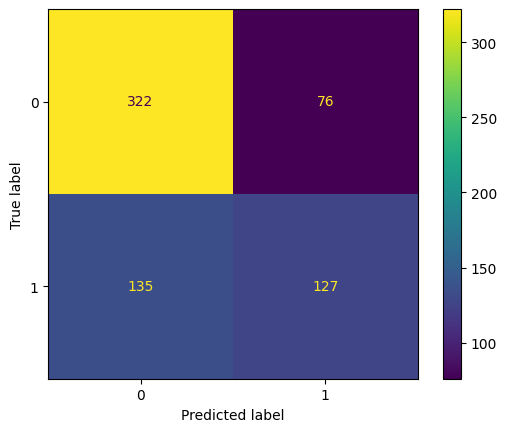

-----------model: XGBoost-----------
mean AUC: 0.7009962728041006
              precision    recall  f1-score   support

           0       0.70      0.81      0.75       398
           1       0.62      0.47      0.53       262

    accuracy                           0.67       660
   macro avg       0.66      0.64      0.64       660
weighted avg       0.66      0.67      0.66       660


Top 10 features:
health                0.128911
therapy               0.085421
year                  0.081630
lang_final_French     0.070406
age_capped            0.066799
lang_final_Italian    0.066772
aff_empathy           0.064754
study_hours           0.057128
part                  0.057005
sex                   0.053367
dtype: float32


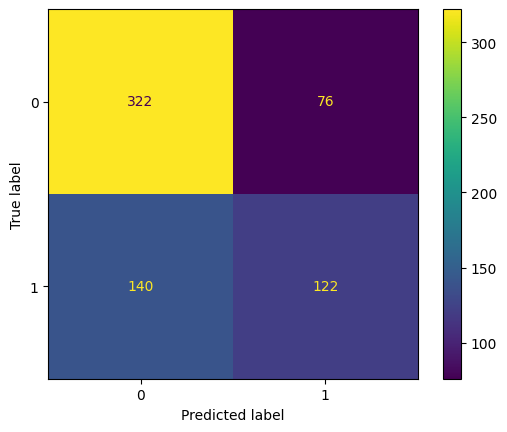

In [ ]:
for name, clf in zip(names, classifiers):
    clf_train(clf, name, X_train_selected, y_train_depression)

**Training with SMOTE**

-----------model: Logistic Regression-----------
mean AUC: 0.7122
              precision    recall  f1-score   support

           0       0.73      0.69      0.71       398
           1       0.57      0.62      0.59       262

    accuracy                           0.66       660
   macro avg       0.65      0.65      0.65       660
weighted avg       0.67      0.66      0.66       660


Top 10 features:
therapy               1.056974
health                0.536377
part                  0.491111
aff_empathy           0.336040
year                  0.205541
lang_final_German     0.205303
sex                   0.173560
job                   0.143123
lang_final_Italian    0.133051
total_empathy         0.115578
dtype: float64


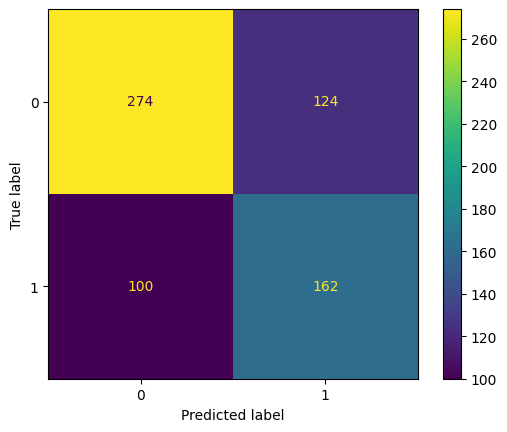

-----------model: Linear SVM-----------
mean AUC: 0.7100
              precision    recall  f1-score   support

           0       0.73      0.70      0.71       398
           1       0.57      0.61      0.59       262

    accuracy                           0.66       660
   macro avg       0.65      0.65      0.65       660
weighted avg       0.66      0.66      0.66       660


Top 10 features:
therapy            0.527129
health             0.510677
aff_empathy        0.286530
part               0.266201
year               0.161306
study_hours        0.154589
total_empathy      0.133548
job                0.101263
sex                0.081945
emotion_rec_acc    0.077357
dtype: float64


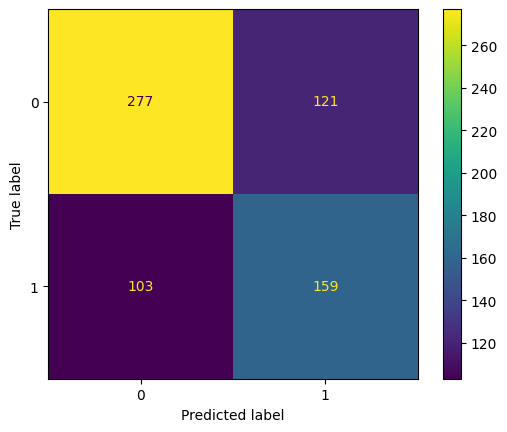

-----------model: Random Forest-----------
mean AUC: 0.6873
              precision    recall  f1-score   support

           0       0.70      0.71      0.71       398
           1       0.55      0.54      0.55       262

    accuracy                           0.64       660
   macro avg       0.63      0.63      0.63       660
weighted avg       0.64      0.64      0.64       660


Top 10 features:
aff_empathy        0.119190
health             0.112778
study_hours        0.110366
total_empathy      0.103268
motivation         0.095103
cog_empathy        0.090896
emotion_rec_acc    0.082441
age_capped         0.075901
year               0.062861
therapy            0.046176
dtype: float64


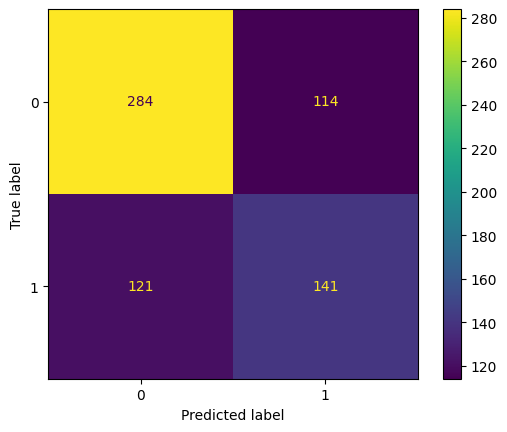

-----------model: AdaBoost-----------
mean AUC: 0.7099
              precision    recall  f1-score   support

           0       0.73      0.70      0.72       398
           1       0.57      0.61      0.59       262

    accuracy                           0.67       660
   macro avg       0.65      0.66      0.65       660
weighted avg       0.67      0.67      0.67       660


Top 10 features:
study_hours        0.356365
health             0.258660
therapy            0.092923
year               0.090415
aff_empathy        0.069308
part               0.060855
emotion_rec_acc    0.035447
total_empathy      0.021789
cog_empathy        0.014238
age_capped         0.000000
dtype: float64


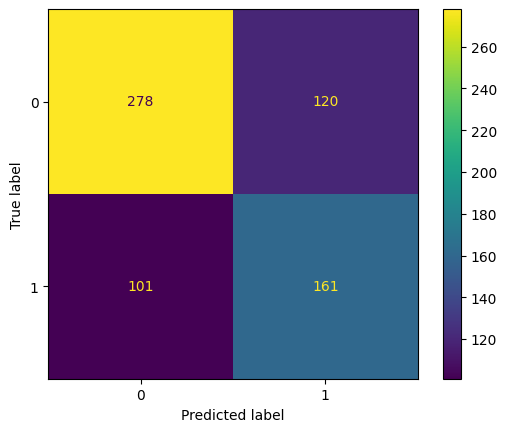

-----------model: XGBoost-----------
mean AUC: 0.6974
              precision    recall  f1-score   support

           0       0.72      0.70      0.71       398
           1       0.56      0.58      0.57       262

    accuracy                           0.65       660
   macro avg       0.64      0.64      0.64       660
weighted avg       0.66      0.65      0.65       660


Top 10 features:
health                0.128911
therapy               0.085421
year                  0.081630
lang_final_French     0.070406
age_capped            0.066799
lang_final_Italian    0.066772
aff_empathy           0.064754
study_hours           0.057128
part                  0.057005
sex                   0.053367
dtype: float32


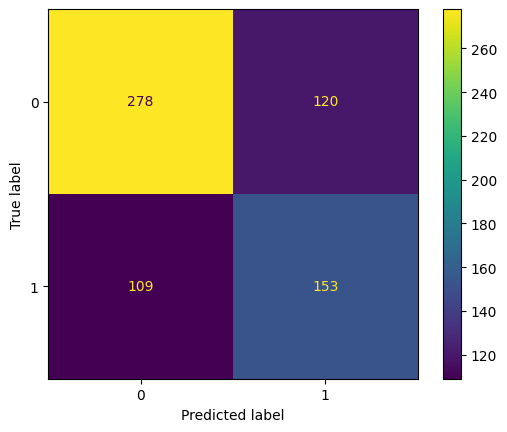

In [ ]:
for name, clf in zip(names, classifiers):
    clf_train_smote(clf, name, X_train_selected, y_train_depression)

**The best models so far: LogisticRegression and LinearSVM**

**Grid Search**

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(
    SVC(kernel='linear', probability=True, random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=5
)
grid.fit(X_train_selected, y_train_depression)
print(f"Best SVM: {grid.best_params_}, AUC: {grid.best_score_:.4f}")

Best SVM: {'C': 0.01}, AUC: 0.7183


In [ ]:
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
                 'solver': ['lbfgs', 'liblinear']}
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    scoring='roc_auc',
    cv=5
)
grid_lr.fit(X_train_selected, y_train_depression)
print(f"Best LR: {grid_lr.best_params_}, AUC: {grid_lr.best_score_:.4f}")

Best LR: {'C': 0.1, 'solver': 'lbfgs'}, AUC: 0.7186


The best params would be chosen and changed in the models.

In [ ]:
classifiers = [
    LogisticRegression(max_iter=1000, C=0.1, class_weight='balanced'),
    SVC(kernel="linear", C=0.01, probability=True, class_weight='balanced'),
    RandomForestClassifier(max_depth=10, n_estimators=50, class_weight='balanced'),
    AdaBoostClassifier(random_state=42),
    XGBClassifier(n_estimators=100, max_depth=3,
                  learning_rate=0.05, subsample=0.8,
                  eval_metric='auc', random_state=42),

]

**without language**

-----------model: Logistic Regression-----------
mean AUC: 0.7189885359445904
              precision    recall  f1-score   support

           0       0.74      0.68      0.71       398
           1       0.57      0.63      0.60       262

    accuracy                           0.66       660
   macro avg       0.65      0.66      0.65       660
weighted avg       0.67      0.66      0.66       660


Top 10 features:
therapy          0.747800
health           0.512884
part             0.371871
aff_empathy      0.298066
year             0.193152
total_empathy    0.111151
job              0.109574
study_hours      0.102806
cog_empathy      0.086904
sex              0.084237
dtype: float64


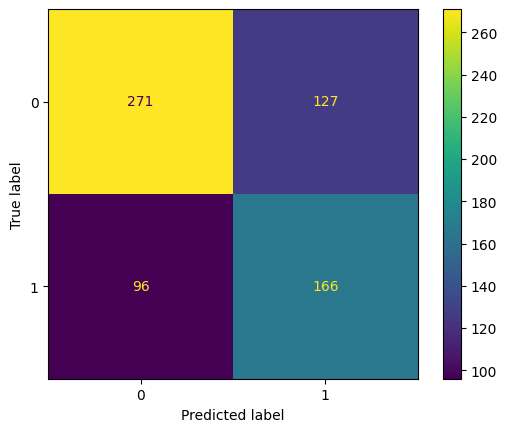

-----------model: Linear SVM-----------
mean AUC: 0.7075313240616561
              precision    recall  f1-score   support

           0       0.73      0.66      0.69       398
           1       0.55      0.63      0.58       262

    accuracy                           0.65       660
   macro avg       0.64      0.64      0.64       660
weighted avg       0.66      0.65      0.65       660


Top 10 features:
health             0.467027
therapy            0.329228
aff_empathy        0.235054
part               0.182233
year               0.177636
total_empathy      0.110394
study_hours        0.108114
emotion_rec_acc    0.089415
motivation         0.084270
job                0.078260
dtype: float64


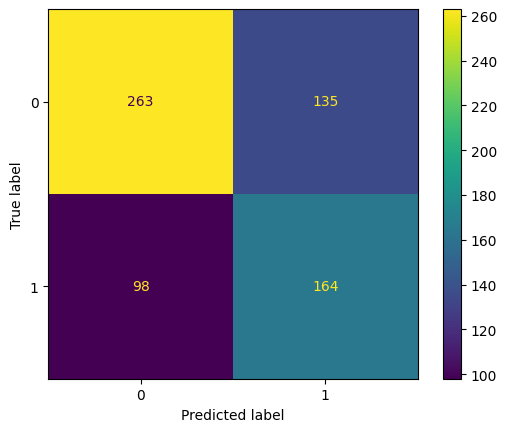

-----------model: Random Forest-----------
mean AUC: 0.6778687466700961
              precision    recall  f1-score   support

           0       0.68      0.78      0.73       398
           1       0.57      0.45      0.51       262

    accuracy                           0.65       660
   macro avg       0.63      0.62      0.62       660
weighted avg       0.64      0.65      0.64       660


Top 10 features:
study_hours        0.117838
aff_empathy        0.115185
total_empathy      0.105802
health             0.105562
cog_empathy        0.104716
motivation         0.103178
emotion_rec_acc    0.084055
age_capped         0.082427
year               0.067848
therapy            0.050285
dtype: float64


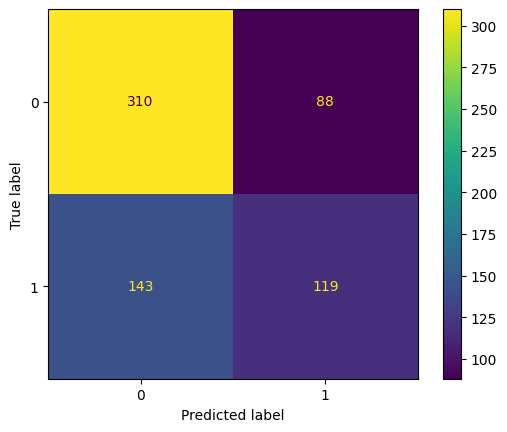

-----------model: AdaBoost-----------
mean AUC: 0.713052276046738
              precision    recall  f1-score   support

           0       0.70      0.81      0.75       398
           1       0.63      0.48      0.55       262

    accuracy                           0.68       660
   macro avg       0.67      0.65      0.65       660
weighted avg       0.67      0.68      0.67       660


Top 10 features:
study_hours        0.356365
health             0.258660
therapy            0.092923
year               0.090415
aff_empathy        0.069308
part               0.060855
emotion_rec_acc    0.035447
total_empathy      0.021789
cog_empathy        0.014238
job                0.000000
dtype: float64


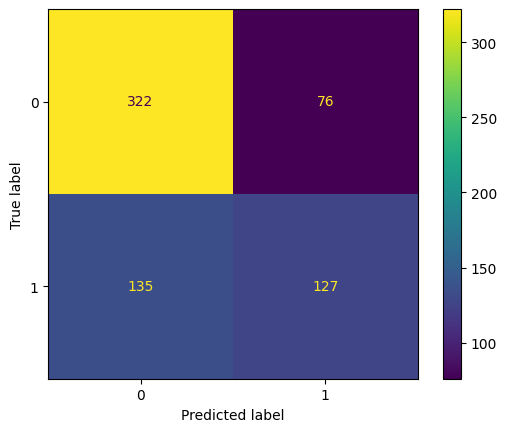

-----------model: XGBoost-----------
mean AUC: 0.6976302681376423
              precision    recall  f1-score   support

           0       0.69      0.80      0.74       398
           1       0.60      0.45      0.51       262

    accuracy                           0.66       660
   macro avg       0.64      0.63      0.63       660
weighted avg       0.65      0.66      0.65       660


Top 10 features:
health             0.159408
therapy            0.104086
year               0.097263
aff_empathy        0.079338
age_capped         0.078095
part               0.073323
study_hours        0.067059
emotion_rec_acc    0.063793
sex                0.060492
motivation         0.057881
dtype: float32


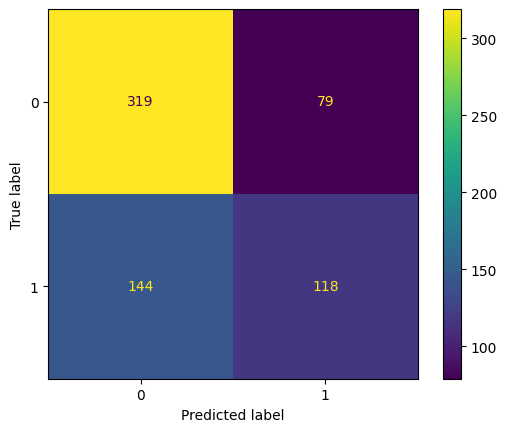

In [ ]:
X_train_selected = X_train[["age_capped", "year", "sex", "part", "job","study_hours", "health",
                   "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]
for name, clf in zip(names, classifiers):
    clf_train(clf, name, X_train_selected, y_train_depression)

**after grouping age**

-----------model: Logistic Regression-----------
mean AUC: 0.7221609928165934
              precision    recall  f1-score   support

           0       0.74      0.69      0.72       398
           1       0.57      0.63      0.60       262

    accuracy                           0.67       660
   macro avg       0.66      0.66      0.66       660
weighted avg       0.67      0.67      0.67       660


Top 10 features:
therapy          0.746601
health           0.514723
part             0.367063
aff_empathy      0.297568
year             0.180942
total_empathy    0.110862
job              0.107228
study_hours      0.103899
cog_empathy      0.086523
sex              0.085034
dtype: float64


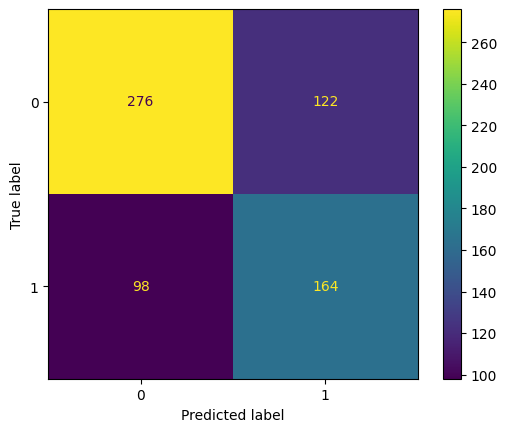

-----------model: Linear SVM-----------
mean AUC: 0.7096445384982821
              precision    recall  f1-score   support

           0       0.73      0.66      0.69       398
           1       0.55      0.63      0.58       262

    accuracy                           0.65       660
   macro avg       0.64      0.64      0.64       660
weighted avg       0.66      0.65      0.65       660


Top 10 features:
health               0.471562
therapy              0.325730
aff_empathy          0.233570
part                 0.185732
year                 0.173587
study_hours          0.114099
total_empathy        0.112429
motivation           0.091866
emotion_rec_acc      0.091775
age_group_23_plus    0.080832
dtype: float64


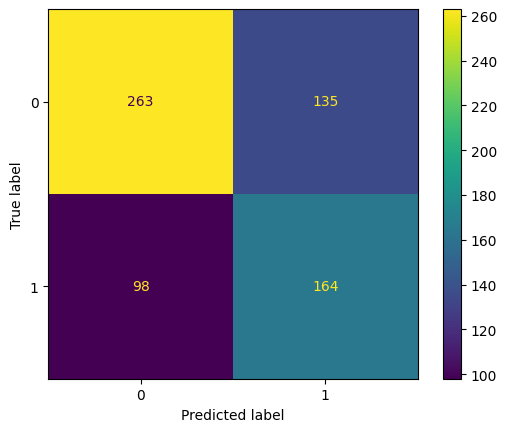

-----------model: Random Forest-----------
mean AUC: 0.6704813203872794
              precision    recall  f1-score   support

           0       0.68      0.79      0.73       398
           1       0.58      0.45      0.51       262

    accuracy                           0.65       660
   macro avg       0.63      0.62      0.62       660
weighted avg       0.64      0.65      0.64       660


Top 10 features:
health             0.130163
aff_empathy        0.124074
study_hours        0.117843
total_empathy      0.105445
motivation         0.104831
cog_empathy        0.101562
emotion_rec_acc    0.100829
year               0.073970
therapy            0.047873
part               0.030973
dtype: float64


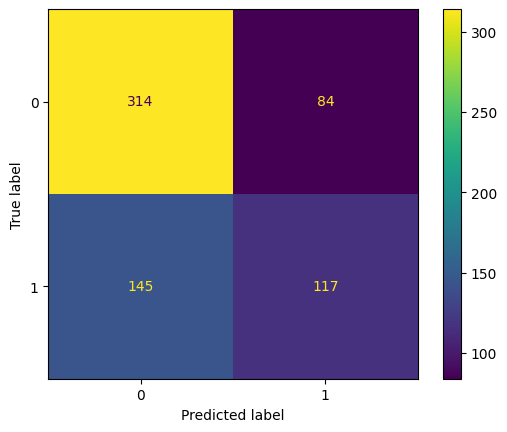

-----------model: AdaBoost-----------
mean AUC: 0.7156724683544304
              precision    recall  f1-score   support

           0       0.70      0.81      0.75       398
           1       0.62      0.48      0.55       262

    accuracy                           0.68       660
   macro avg       0.66      0.65      0.65       660
weighted avg       0.67      0.68      0.67       660


Top 10 features:
study_hours        0.356365
health             0.258660
therapy            0.092923
year               0.090415
aff_empathy        0.069308
part               0.060855
emotion_rec_acc    0.035447
total_empathy      0.021789
cog_empathy        0.014238
job                0.000000
dtype: float64


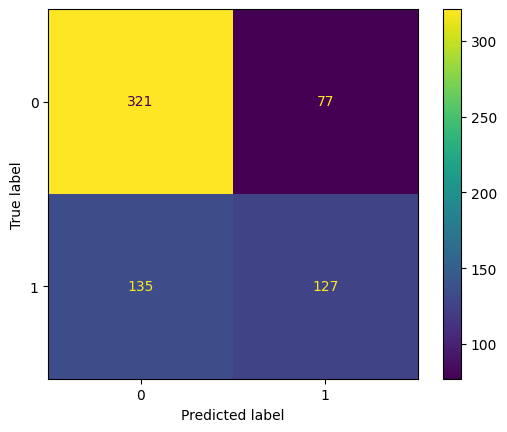

-----------model: XGBoost-----------
mean AUC: 0.7020967716007422
              precision    recall  f1-score   support

           0       0.69      0.80      0.74       398
           1       0.60      0.45      0.52       262

    accuracy                           0.66       660
   macro avg       0.65      0.63      0.63       660
weighted avg       0.65      0.66      0.65       660


Top 10 features:
health               0.154985
age_group_23_plus    0.112710
therapy              0.111260
year                 0.083769
aff_empathy          0.077465
part                 0.069489
sex                  0.064892
study_hours          0.063285
emotion_rec_acc      0.060019
motivation           0.054756
dtype: float32


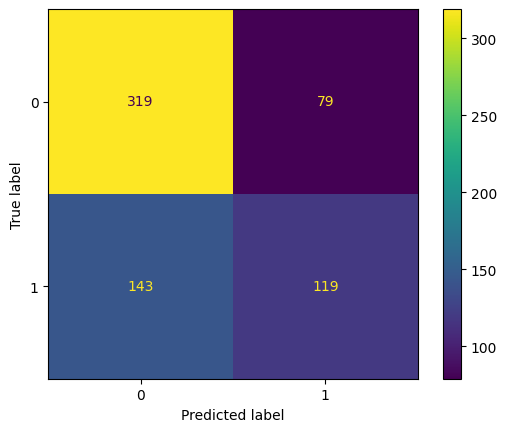

In [ ]:
X_train_selected = X_train[["age_group_23_plus", "year", "sex", "part", "job","study_hours", "health",
                   "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]

for name, clf in zip(names, classifiers):
    clf_train(clf, name, X_train_selected, y_train_depression)

**After grouping study hours**

-----------model: Logistic Regression-----------
mean AUC: 0.7222999531516967
              precision    recall  f1-score   support

           0       0.74      0.69      0.71       398
           1       0.57      0.64      0.60       262

    accuracy                           0.67       660
   macro avg       0.66      0.66      0.66       660
weighted avg       0.67      0.67      0.67       660


Top 10 features:
therapy            0.744577
health             0.516829
part               0.361342
aff_empathy        0.294679
year               0.193843
study_group_low    0.175203
total_empathy      0.112646
job                0.105481
sex                0.095922
cog_empathy        0.088030
dtype: float64


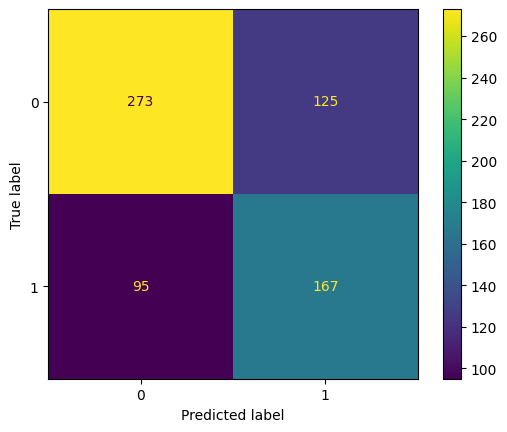

-----------model: Linear SVM-----------
mean AUC: 0.7109308344509563
              precision    recall  f1-score   support

           0       0.74      0.69      0.71       398
           1       0.57      0.63      0.60       262

    accuracy                           0.67       660
   macro avg       0.66      0.66      0.66       660
weighted avg       0.67      0.67      0.67       660


Top 10 features:
health             0.464742
therapy            0.334286
aff_empathy        0.231254
year               0.189098
part               0.169493
study_group_low    0.125520
total_empathy      0.105238
motivation         0.090444
job                0.083334
emotion_rec_acc    0.077761
dtype: float64


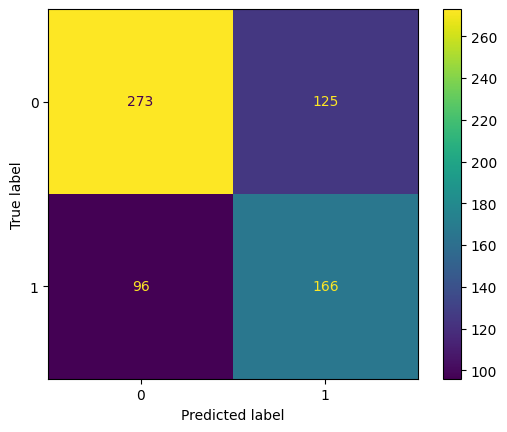

-----------model: Random Forest-----------
mean AUC: 0.6675067631496757
              precision    recall  f1-score   support

           0       0.69      0.79      0.73       398
           1       0.59      0.46      0.51       262

    accuracy                           0.66       660
   macro avg       0.64      0.62      0.62       660
weighted avg       0.65      0.66      0.65       660


Top 10 features:
health             0.133868
aff_empathy        0.132413
total_empathy      0.121339
cog_empathy        0.114648
motivation         0.111743
emotion_rec_acc    0.103680
year               0.083484
therapy            0.050955
part               0.034399
study_group_low    0.024865
dtype: float64


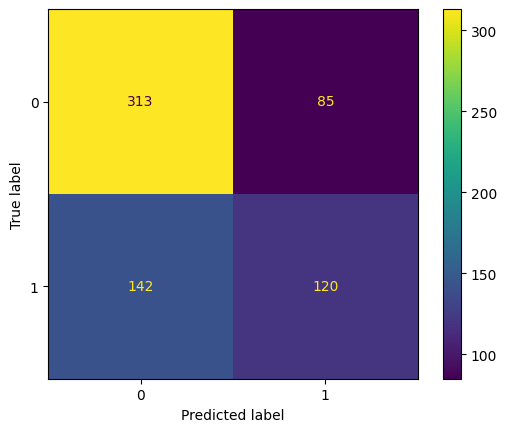

-----------model: AdaBoost-----------
mean AUC: 0.7175116604049163
              precision    recall  f1-score   support

           0       0.71      0.82      0.76       398
           1       0.64      0.48      0.55       262

    accuracy                           0.68       660
   macro avg       0.67      0.65      0.65       660
weighted avg       0.68      0.68      0.68       660


Top 10 features:
health             0.243238
aff_empathy        0.152406
total_empathy      0.117031
motivation         0.082988
cog_empathy        0.082672
therapy            0.082386
year               0.080163
emotion_rec_acc    0.072615
part               0.053955
study_group_low    0.032546
dtype: float64


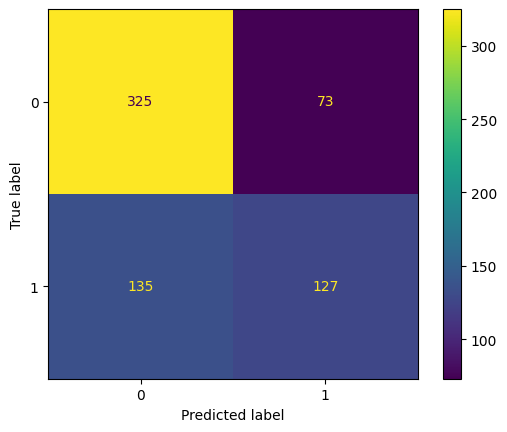

-----------model: XGBoost-----------
mean AUC: 0.6994478904484577
              precision    recall  f1-score   support

           0       0.70      0.81      0.75       398
           1       0.62      0.47      0.53       262

    accuracy                           0.67       660
   macro avg       0.66      0.64      0.64       660
weighted avg       0.67      0.67      0.66       660


Top 10 features:
health               0.149034
therapy              0.102944
age_group_23_plus    0.095366
year                 0.084553
aff_empathy          0.072028
part                 0.062086
sex                  0.060071
emotion_rec_acc      0.058709
study_group_low      0.056075
cog_empathy          0.052694
dtype: float32


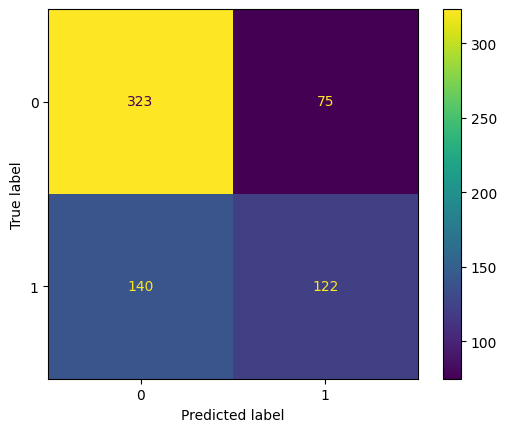

In [ ]:
X_train_selected = X_train[["age_group_23_plus", "year", "sex", "part", "job", "health",
                   "study_group_low", "study_group_moderate", "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]

for name, clf in zip(names, classifiers):
    clf_train(clf, name, X_train_selected, y_train_depression)

**Feature Importance on the Best Model**

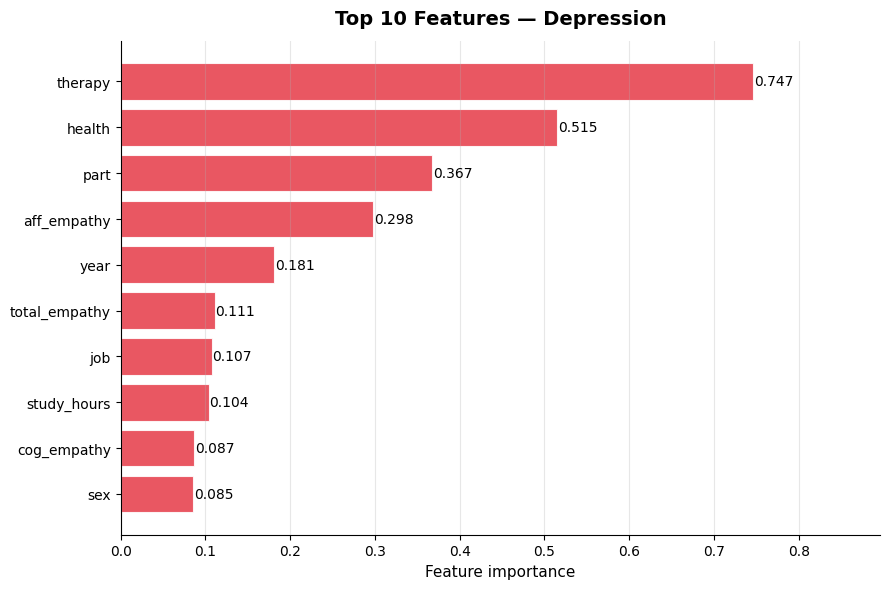

In [ ]:
X_train_selected = X_train[["age_group_23_plus", "year", "sex", "part", "job","study_hours", "health",
                   "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]

clf = LogisticRegression(max_iter=1000, C=0.1, class_weight='balanced')
clf.fit(X_train_selected, y_train_depression)

importance = pd.Series(
    np.abs(clf.coef_[0]),
    index=X_train_selected.columns
).sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(importance.index, importance.values,
               color='#E63946', alpha=0.85,
               edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, importance.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('Top 10 Features — Depression',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Feature importance', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, importance.values.max() * 1.2)

plt.tight_layout()
plt.savefig('feature_importance_depression.png', dpi=150, bbox_inches='tight')
plt.show()

**Train on Top features**

-----------model: Logistic Regression-----------
mean AUC: 0.7272292443644246
              precision    recall  f1-score   support

           0       0.75      0.69      0.72       398
           1       0.58      0.65      0.62       262

    accuracy                           0.68       660
   macro avg       0.67      0.67      0.67       660
weighted avg       0.69      0.68      0.68       660


Top 10 features:
therapy          0.758320
health           0.514108
part             0.375472
aff_empathy      0.297177
year             0.191465
total_empathy    0.111519
cog_empathy      0.107260
job              0.104866
study_hours      0.103187
sex              0.091337
dtype: float64


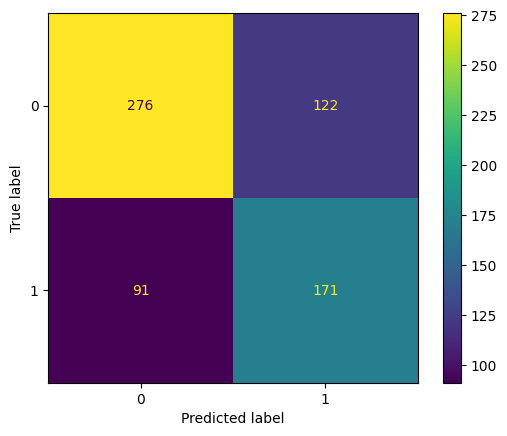

-----------model: Linear SVM-----------
mean AUC: 0.7154373541731733
              precision    recall  f1-score   support

           0       0.74      0.66      0.69       398
           1       0.55      0.64      0.59       262

    accuracy                           0.65       660
   macro avg       0.64      0.65      0.64       660
weighted avg       0.66      0.65      0.65       660


Top 10 features:
health           0.467745
therapy          0.342250
aff_empathy      0.245590
part             0.199831
year             0.175168
study_hours      0.124147
total_empathy    0.112441
job              0.103479
cog_empathy      0.045853
sex              0.018102
dtype: float64


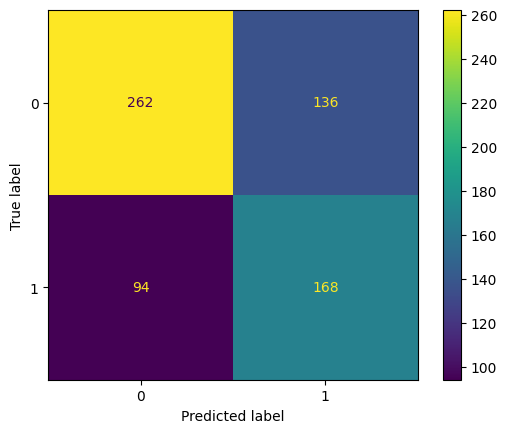

-----------model: Random Forest-----------
mean AUC: 0.6747921336187098
              precision    recall  f1-score   support

           0       0.68      0.75      0.72       398
           1       0.56      0.47      0.51       262

    accuracy                           0.64       660
   macro avg       0.62      0.61      0.61       660
weighted avg       0.63      0.64      0.63       660


Top 10 features:
study_hours      0.167296
aff_empathy      0.164456
health           0.145326
total_empathy    0.143905
cog_empathy      0.141230
year             0.096381
therapy          0.052433
part             0.035133
job              0.027721
sex              0.026118
dtype: float64


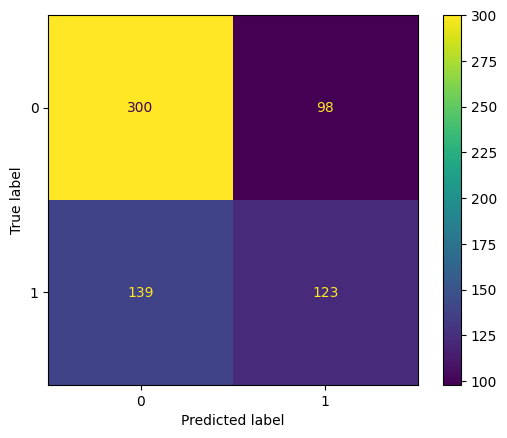

-----------model: AdaBoost-----------
mean AUC: 0.7195271593852768
              precision    recall  f1-score   support

           0       0.70      0.81      0.75       398
           1       0.63      0.47      0.54       262

    accuracy                           0.68       660
   macro avg       0.66      0.64      0.65       660
weighted avg       0.67      0.68      0.67       660


Top 10 features:
study_hours      0.368499
health           0.268407
therapy          0.096424
year             0.093822
aff_empathy      0.071920
part             0.063148
total_empathy    0.022610
cog_empathy      0.015169
sex              0.000000
job              0.000000
dtype: float64


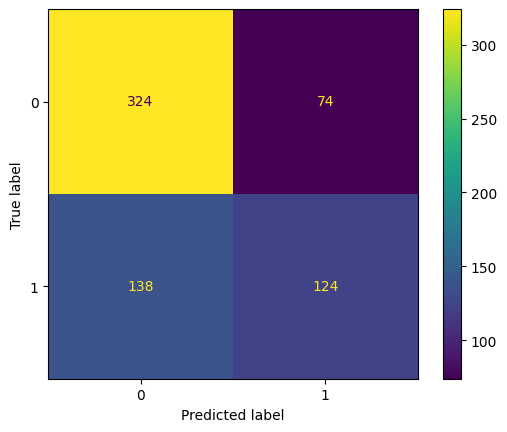

-----------model: XGBoost-----------
mean AUC: 0.6994013636530654
              precision    recall  f1-score   support

           0       0.69      0.79      0.74       398
           1       0.60      0.46      0.52       262

    accuracy                           0.66       660
   macro avg       0.64      0.63      0.63       660
weighted avg       0.65      0.66      0.65       660


Top 10 features:
health           0.199541
therapy          0.136868
year             0.115146
part             0.095628
aff_empathy      0.095011
study_hours      0.088301
sex              0.074835
cog_empathy      0.069532
total_empathy    0.069471
job              0.055666
dtype: float32


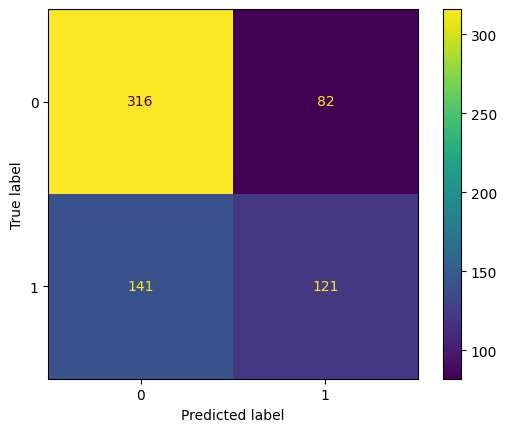

In [ ]:
X_train_selected = X_train[["year", "sex", "part", "job","study_hours", "health",
                   "therapy", "total_empathy", "cog_empathy","aff_empathy"]]


for name, clf in zip(names, classifiers):
    clf_train(clf, name, X_train_selected, y_train_depression)

In [ ]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

-----------model: XGBoost-----------
mean AUC: 0.7272292443644246
              precision    recall  f1-score   support

           0       0.75      0.69      0.72       398
           1       0.58      0.65      0.62       262

    accuracy                           0.68       660
   macro avg       0.67      0.67      0.67       660
weighted avg       0.69      0.68      0.68       660


Top 10 features:
therapy          0.758320
health           0.514108
part             0.375472
aff_empathy      0.297177
year             0.191465
total_empathy    0.111519
cog_empathy      0.107260
job              0.104866
study_hours      0.103187
sex              0.091337
dtype: float64


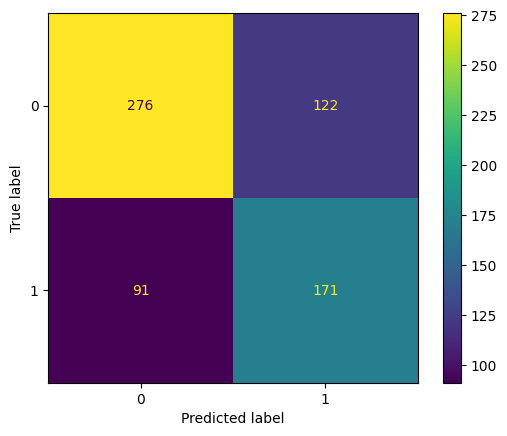

In [ ]:
X_train_selected = X_train[["year", "sex", "part", "job","study_hours", "health",
                   "therapy", "total_empathy", "cog_empathy","aff_empathy"]]

clf = LogisticRegression(max_iter=1000, C=0.1, class_weight='balanced')
best_model = clf_train(clf, name, X_train_selected, y_train_depression)

-----------model: Logistic Regression-----------
CV AUC:   0.7272
Test AUC: 0.7416
Gap:      +0.0144  ✅
              precision    recall  f1-score   support

           0       0.73      0.75      0.74       122
           1       0.68      0.66      0.67        99

    accuracy                           0.71       221
   macro avg       0.70      0.70      0.70       221
weighted avg       0.71      0.71      0.71       221



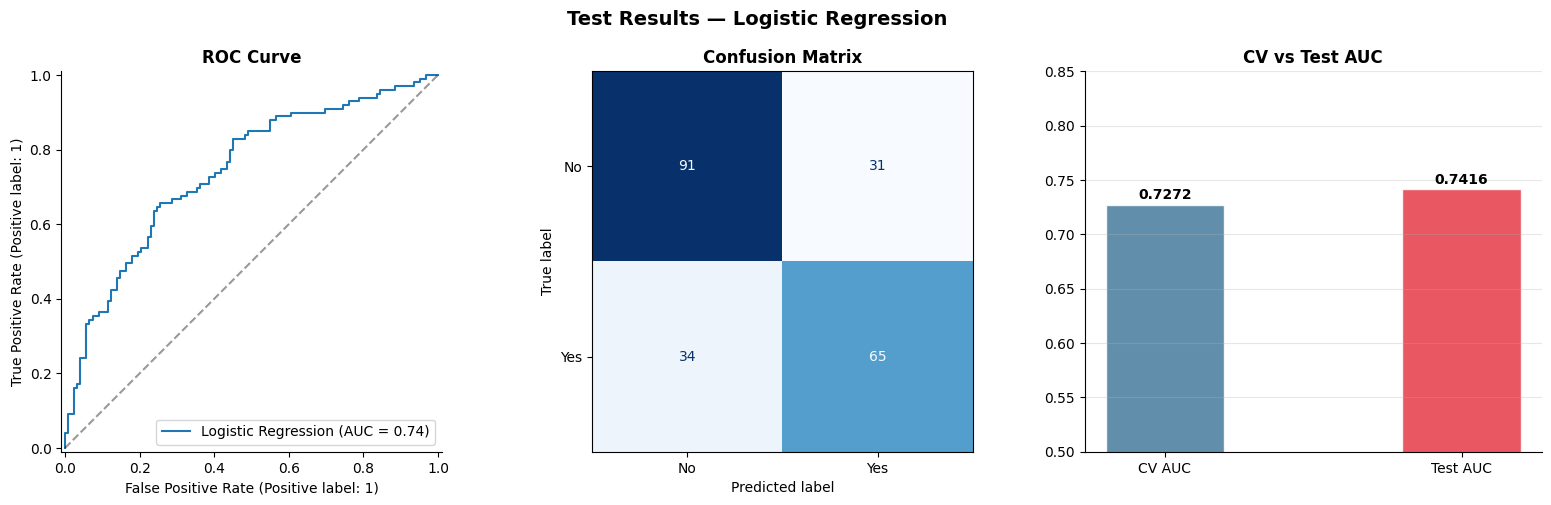

In [ ]:
X_test_selected = X_test[["year", "sex", "part", "job","study_hours", "health",
                   "therapy", "total_empathy", "cog_empathy","aff_empathy"]]
clf_test(best_model,'Logistic Regression', X_train_selected, y_train_depression, X_test_selected, y_test["depression_category"])

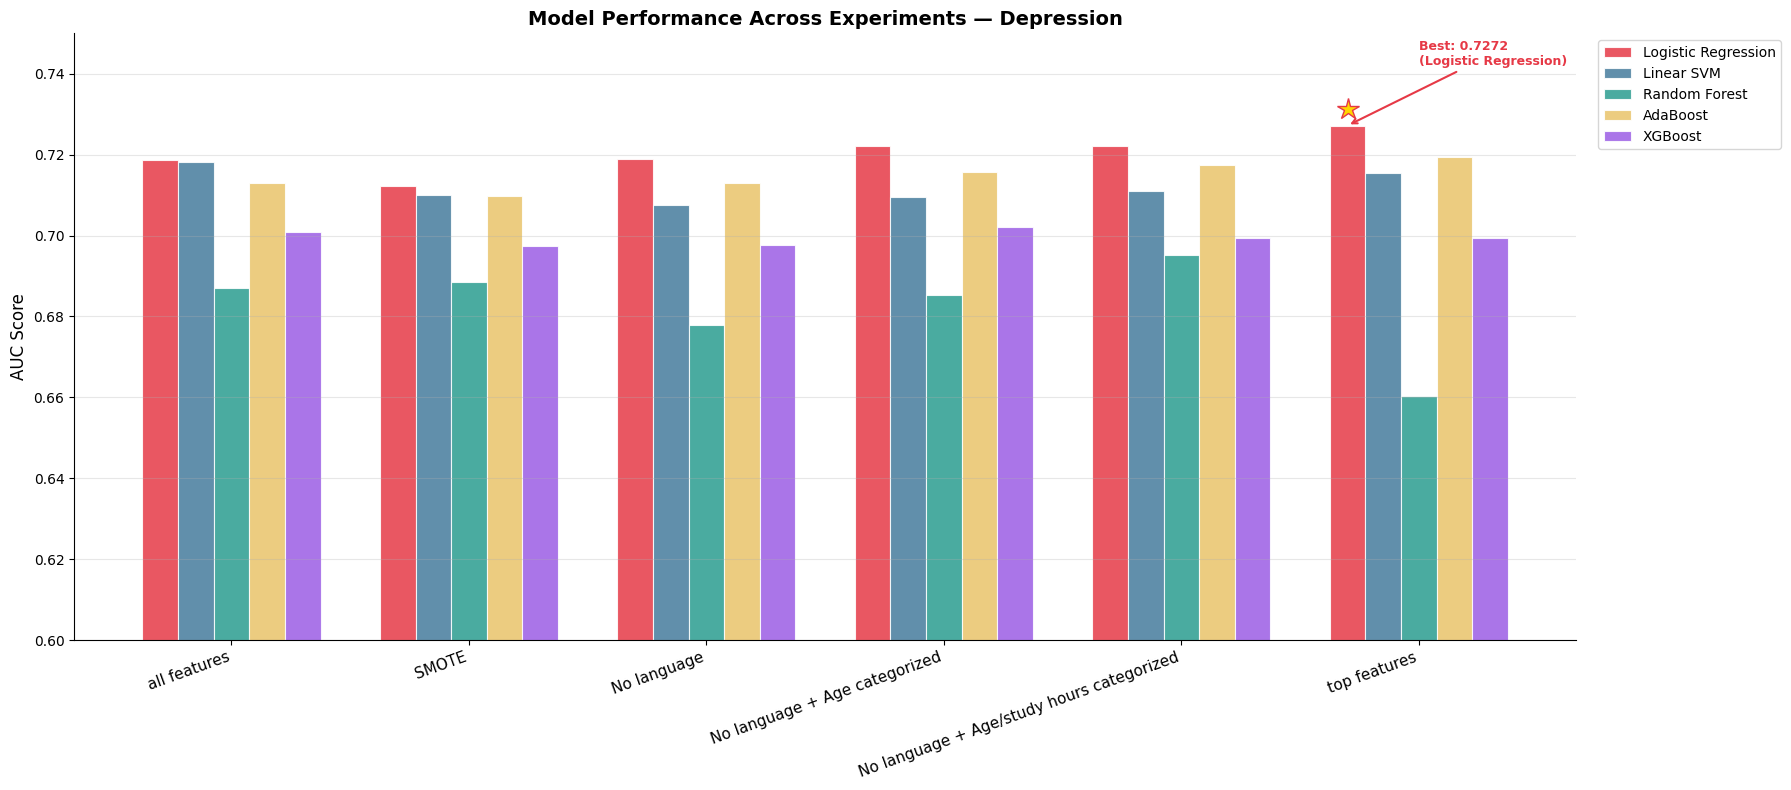

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

experiments = [
    'all features',
    'SMOTE',
    'No language',
    'No language + Age categorized',
    'No language + Age/study hours categorized',
    'top features'
]

models = ["Logistic Regression",
    "Linear SVM",
    "Random Forest",
    "AdaBoost",
    "XGBoost"]
colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#9B5DE5']

auc_results = {
    'Logistic Regression': [0.7186, 0.7122, 0.7189, 0.7221, 0.7222, 0.7272],
    'Linear SVM':          [0.7183, 0.71,   0.7075, 0.7096, 0.7109, 0.7154],
    'Random Forest':       [0.687,  0.6884, 0.6779, 0.6852, 0.6951, 0.6603],
    'AdaBoost':            [0.713,  0.7099, 0.713,  0.7156, 0.7175, 0.7195],
    'XGBoost':             [0.7009, 0.6974, 0.6976, 0.702,  0.6994, 0.6994],
}

fig, ax = plt.subplots(figsize=(18, 8))
x     = np.arange(len(experiments))
width = 0.15
n     = len(models)

best_auc, best_model_i, best_exp_i = 0, 0, 0
for i, model in enumerate(models):
    for j, auc in enumerate(auc_results[model]):
        if auc > best_auc:
            best_auc, best_model_i, best_exp_i = auc, i, j

for i, (model, color) in enumerate(zip(models, colors)):
    offset = (i - n/2 + 0.5) * width
    ax.bar(x + offset, auc_results[model], width,
           label=model, color=color,
           alpha=0.85, edgecolor='white', linewidth=0.8)

best_x = x[best_exp_i] + (best_model_i - n/2 + 0.5) * width
ax.annotate(
    f'Best: {best_auc:.4f}\n({models[best_model_i]})',
    xy=(best_x, best_auc),
    xytext=(best_x + 0.3, best_auc + 0.015),
    fontsize=9, fontweight='bold', color=colors[best_model_i],
    arrowprops=dict(arrowstyle='->', color=colors[best_model_i], lw=1.5),
)
ax.plot(best_x, best_auc + 0.004, '*',
        markersize=16, color='gold',
        markeredgecolor=colors[best_model_i], markeredgewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(experiments, rotation=20, ha='right', fontsize=11)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_ylim(0.60, 0.750)
ax.set_title('Model Performance Across Experiments — Depression',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('depression_experiment_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

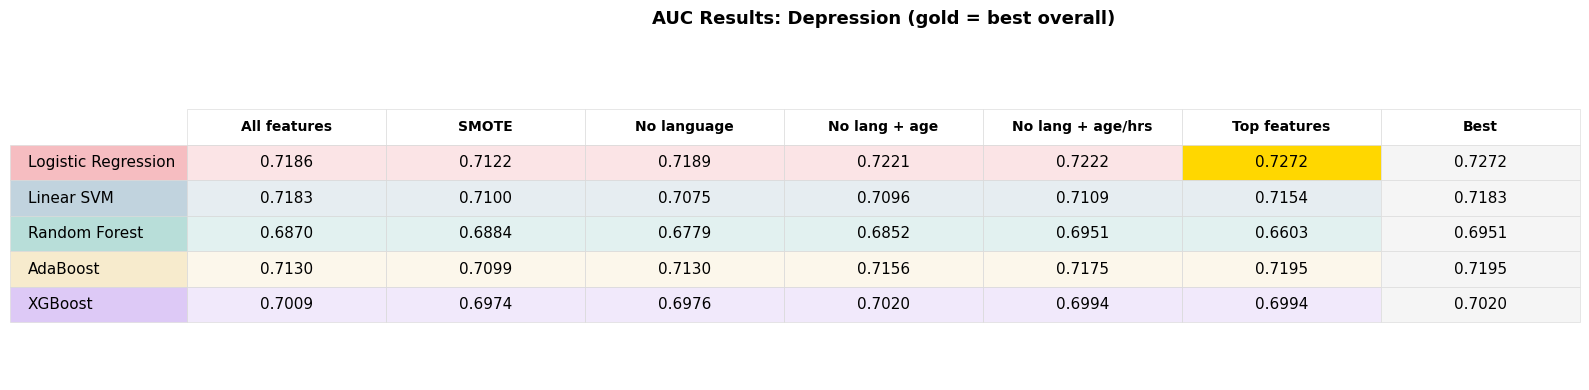

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

experiments = ['All features', 'SMOTE', 'No language', 'No lang + age', 'No lang + age/hrs', 'Top features']
models      = ['Logistic Regression', 'Linear SVM', 'Random Forest', 'AdaBoost', 'XGBoost']
colors      = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#9B5DE5']

auc_results = {
    'Logistic Regression': [0.7186, 0.7122, 0.7189, 0.7221, 0.7222, 0.7272],
    'Linear SVM':          [0.7183, 0.71,   0.7075, 0.7096, 0.7109, 0.7154],
    'Random Forest':       [0.687,  0.6884, 0.6779, 0.6852, 0.6951, 0.6603],
    'AdaBoost':            [0.713,  0.7099, 0.713,  0.7156, 0.7175, 0.7195],
    'XGBoost':             [0.7009, 0.6974, 0.6976, 0.702,  0.6994, 0.6994],
}

global_best = max(v for vals in auc_results.values() for v in vals)

cell_text   = []
cell_colors = []

for model, color in zip(models, colors):
    row        = [f'{v:.4f}' for v in auc_results[model]]
    row.append(f'{max(auc_results[model]):.4f}')
    cell_text.append(row)

    row_colors = []
    for v in auc_results[model]:
        if v == global_best:
            row_colors.append('#FFD700')
        else:
            row_colors.append(color + '22')
    row_colors.append('#f5f5f5')
    cell_colors.append(row_colors)

col_labels  = experiments + ['Best']
row_colors  = [c + '55' for c in colors]

fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')

table = ax.table(
    cellText=cell_text,
    rowLabels=models,
    colLabels=col_labels,
    cellColours=cell_colors,
    rowColours=row_colors,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#dddddd')
    cell.set_linewidth(0.5)
    if row == 0:
        cell.set_text_props(fontweight='bold', fontsize=10)

ax.set_title('AUC Results: Depression (gold = best overall)',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('auc_table.png', dpi=600, bbox_inches='tight')
plt.show()

### **2. How do demographic characteristics (sex, age, year of study, and mother tongue) and health traits relate to mental health outcomes anxiety among medical students in Switzerland?**

anxiety_score
0    51.759364
1    48.240636
Name: proportion, dtype: float64


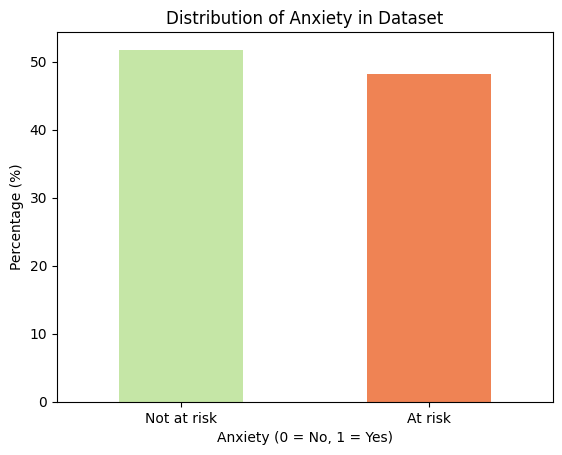

In [ ]:
percentages = (df['anxiety_score'] >= 44).astype(int).value_counts(normalize=True) * 100
print(percentages)
plt.figure()
percentages.sort_index().plot(kind='bar', color=['#C5E6A6', '#EF8354'])

plt.xlabel("Anxiety (0 = No, 1 = Yes)")
plt.ylabel("Percentage (%)")
plt.title("Distribution of Anxiety in Dataset")

plt.xticks([0,1], ["Not at risk", "At risk"], rotation=0)

plt.show()

**Models**

In [ ]:
names = [
    "Logistic Regression",
    "Linear SVM",
    "Random Forest",
    "AdaBoost",
    "XGBoost"
]

classifiers = [
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    SVC(kernel="linear", C=0.025, probability=True, class_weight='balanced'),
    RandomForestClassifier(max_depth=10, n_estimators=50, class_weight='balanced'),
    AdaBoostClassifier(random_state=42),
    XGBClassifier(n_estimators=100, max_depth=3,
                  learning_rate=0.05, subsample=0.8,
                  eval_metric='auc', random_state=42),

]


**Training with all the features**

In [ ]:
X_train_selected = X_train[['age_capped', 'year', 'sex', 'lang_final_French',
       'lang_final_German', 'lang_final_Italian', 'lang_final_Other', 'part',
       'job', 'study_hours', 'health', 'therapy', 'total_empathy', 'cog_empathy', 'aff_empathy',
       'motivation', 'emotion_rec_acc']]

-----------model: Logistic Regression-----------
mean AUC: 0.7532789226102251
              precision    recall  f1-score   support

           0       0.70      0.67      0.68       351
           1       0.64      0.68      0.66       309

    accuracy                           0.67       660
   macro avg       0.67      0.67      0.67       660
weighted avg       0.67      0.67      0.67       660


Top 10 features:
therapy               0.960060
aff_empathy           0.604180
sex                   0.458562
health                0.395897
motivation            0.325821
lang_final_French     0.293350
study_hours           0.249273
cog_empathy           0.217697
job                   0.188383
lang_final_Italian    0.155423
dtype: float64


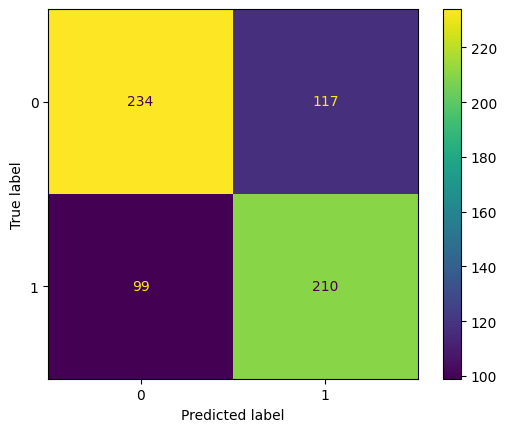

-----------model: Linear SVM-----------
mean AUC: 0.7576962781448076
              precision    recall  f1-score   support

           0       0.72      0.69      0.71       351
           1       0.66      0.70      0.68       309

    accuracy                           0.69       660
   macro avg       0.69      0.69      0.69       660
weighted avg       0.70      0.69      0.69       660


Top 10 features:
aff_empathy          0.553758
therapy              0.503834
health               0.334061
motivation           0.320797
sex                  0.275000
study_hours          0.171599
lang_final_French    0.155198
total_empathy        0.126699
cog_empathy          0.126653
lang_final_Other     0.114795
dtype: float64


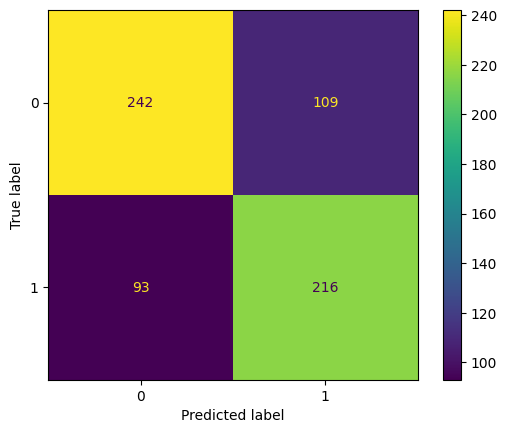

-----------model: Random Forest-----------
mean AUC: 0.722105685408059
              precision    recall  f1-score   support

           0       0.69      0.70      0.69       351
           1       0.65      0.63      0.64       309

    accuracy                           0.67       660
   macro avg       0.67      0.67      0.67       660
weighted avg       0.67      0.67      0.67       660


Top 10 features:
aff_empathy        0.136496
motivation         0.116807
study_hours        0.103351
total_empathy      0.097061
cog_empathy        0.096271
health             0.093691
emotion_rec_acc    0.076523
age_capped         0.074241
year               0.049509
therapy            0.042525
dtype: float64


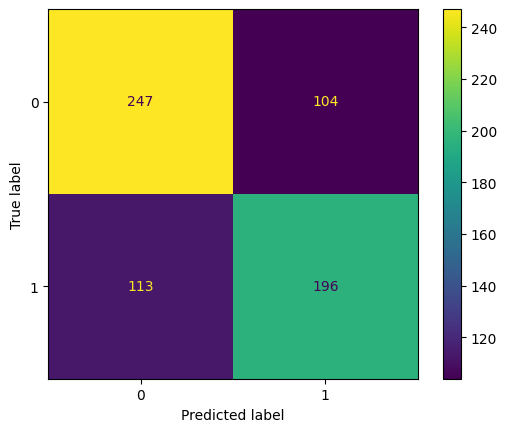

-----------model: AdaBoost-----------
mean AUC: 0.7493388783254791
              precision    recall  f1-score   support

           0       0.70      0.74      0.72       351
           1       0.68      0.63      0.66       309

    accuracy                           0.69       660
   macro avg       0.69      0.69      0.69       660
weighted avg       0.69      0.69      0.69       660


Top 10 features:
motivation           0.238815
aff_empathy          0.156654
health               0.142880
emotion_rec_acc      0.099522
therapy              0.089103
total_empathy        0.083277
study_hours          0.082708
cog_empathy          0.052990
sex                  0.036558
lang_final_French    0.017494
dtype: float64


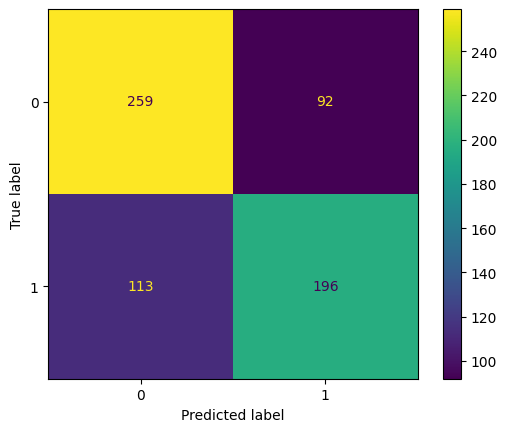

-----------model: XGBoost-----------
mean AUC: 0.7402209768393545
              precision    recall  f1-score   support

           0       0.69      0.72      0.71       351
           1       0.67      0.64      0.65       309

    accuracy                           0.68       660
   macro avg       0.68      0.68      0.68       660
weighted avg       0.68      0.68      0.68       660


Top 10 features:
health                0.125161
therapy               0.119970
sex                   0.098543
aff_empathy           0.077566
motivation            0.065409
lang_final_Italian    0.057475
lang_final_French     0.056701
study_hours           0.053012
cog_empathy           0.049313
job                   0.044693
dtype: float32


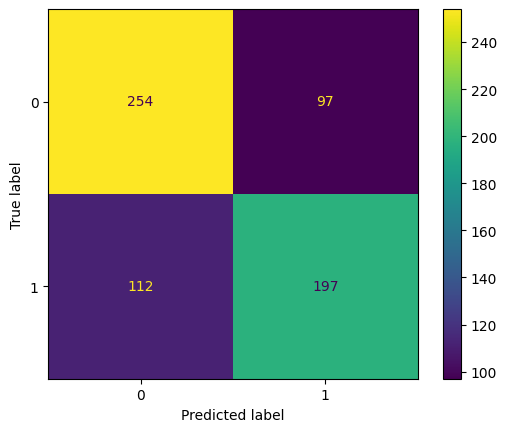

In [ ]:
for name, clf in zip(names, classifiers):
    clf_train(clf, name, X_train_selected, y_train_anxiety)

**Training with SMOTE**

-----------model: Logistic Regression-----------
mean AUC: 0.7557
              precision    recall  f1-score   support

           0       0.71      0.67      0.69       351
           1       0.65      0.69      0.67       309

    accuracy                           0.68       660
   macro avg       0.68      0.68      0.68       660
weighted avg       0.68      0.68      0.68       660


Top 10 features:
therapy               0.960060
aff_empathy           0.604180
sex                   0.458562
health                0.395897
motivation            0.325821
lang_final_French     0.293350
study_hours           0.249273
cog_empathy           0.217697
job                   0.188383
lang_final_Italian    0.155423
dtype: float64


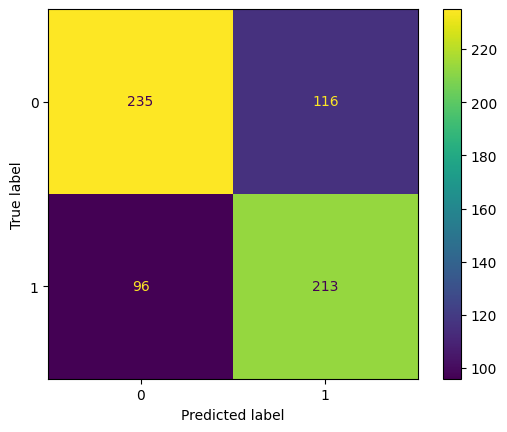

-----------model: Linear SVM-----------
mean AUC: 0.7563
              precision    recall  f1-score   support

           0       0.72      0.69      0.70       351
           1       0.66      0.70      0.68       309

    accuracy                           0.69       660
   macro avg       0.69      0.69      0.69       660
weighted avg       0.69      0.69      0.69       660


Top 10 features:
aff_empathy          0.553758
therapy              0.503834
health               0.334061
motivation           0.320797
sex                  0.275000
study_hours          0.171599
lang_final_French    0.155198
total_empathy        0.126699
cog_empathy          0.126653
lang_final_Other     0.114795
dtype: float64


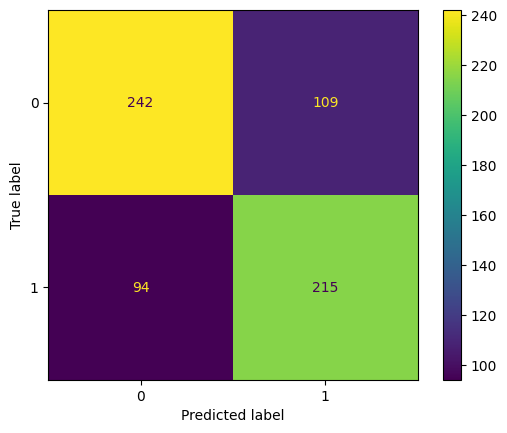

-----------model: Random Forest-----------
mean AUC: 0.7160
              precision    recall  f1-score   support

           0       0.69      0.69      0.69       351
           1       0.65      0.65      0.65       309

    accuracy                           0.67       660
   macro avg       0.67      0.67      0.67       660
weighted avg       0.67      0.67      0.67       660


Top 10 features:
aff_empathy        0.141362
motivation         0.122995
study_hours        0.110793
health             0.100117
total_empathy      0.094114
cog_empathy        0.093322
emotion_rec_acc    0.073187
age_capped         0.072386
therapy            0.046442
year               0.045182
dtype: float64


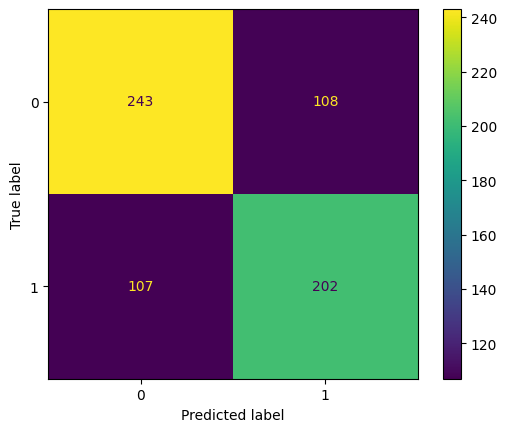

-----------model: AdaBoost-----------
mean AUC: 0.7401
              precision    recall  f1-score   support

           0       0.71      0.68      0.70       351
           1       0.66      0.69      0.67       309

    accuracy                           0.69       660
   macro avg       0.69      0.69      0.69       660
weighted avg       0.69      0.69      0.69       660


Top 10 features:
motivation           0.238815
aff_empathy          0.156654
health               0.142880
emotion_rec_acc      0.099522
therapy              0.089103
total_empathy        0.083277
study_hours          0.082708
cog_empathy          0.052990
sex                  0.036558
lang_final_French    0.017494
dtype: float64


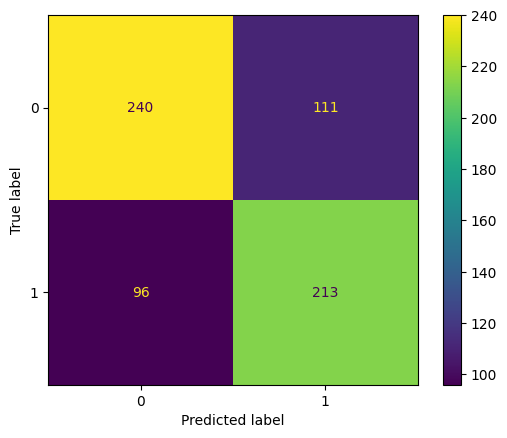

-----------model: XGBoost-----------
mean AUC: 0.7416
              precision    recall  f1-score   support

           0       0.70      0.69      0.70       351
           1       0.66      0.67      0.66       309

    accuracy                           0.68       660
   macro avg       0.68      0.68      0.68       660
weighted avg       0.68      0.68      0.68       660


Top 10 features:
health                0.125161
therapy               0.119970
sex                   0.098543
aff_empathy           0.077566
motivation            0.065409
lang_final_Italian    0.057475
lang_final_French     0.056701
study_hours           0.053012
cog_empathy           0.049313
job                   0.044693
dtype: float32


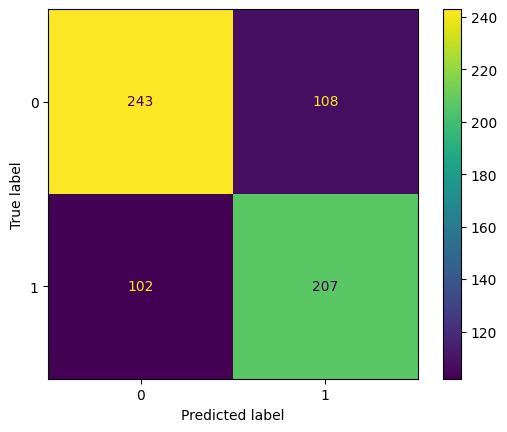

In [ ]:
for name, clf in zip(names, classifiers):
    clf_train_smote(clf, name, X_train_selected, y_train_anxiety)

**The best models so far: LogisticRegression and LinearSVM**

**Grid Search**

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(
    SVC(kernel='linear', probability=True, random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=5
)
grid.fit(X_train_selected, y_train_anxiety)
print(f"Best SVM: {grid.best_params_}, AUC: {grid.best_score_:.4f}")

Best SVM: {'C': 0.1}, AUC: 0.7601


In [ ]:
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
                 'solver': ['lbfgs', 'liblinear']}
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    scoring='roc_auc',
    cv=5
)
grid_lr.fit(X_train_selected, y_train_anxiety)
print(f"Best LR: {grid_lr.best_params_}, AUC: {grid_lr.best_score_:.4f}")

Best LR: {'C': 0.1, 'solver': 'liblinear'}, AUC: 0.7604


The best params would be chosen and changed in the models.

In [ ]:
classifiers = [
    LogisticRegression(max_iter=1000, C=0.1, class_weight='balanced'),
    SVC(kernel="linear", C=0.1, probability=True, class_weight='balanced'),
    RandomForestClassifier(max_depth=10, n_estimators=50, class_weight='balanced'),
    AdaBoostClassifier(random_state=42),
    XGBClassifier(n_estimators=100, max_depth=3,
                  learning_rate=0.05, subsample=0.8,
                  eval_metric='auc', random_state=42),

]

**without language**

-----------model: Logistic Regression-----------
mean AUC: 0.7602365860951006
              precision    recall  f1-score   support

           0       0.73      0.68      0.70       351
           1       0.66      0.71      0.68       309

    accuracy                           0.69       660
   macro avg       0.69      0.69      0.69       660
weighted avg       0.70      0.69      0.69       660


Top 10 features:
therapy          0.681921
aff_empathy      0.542801
sex              0.380995
health           0.378984
motivation       0.318648
study_hours      0.222450
cog_empathy      0.184597
job              0.142988
age_capped       0.131760
total_empathy    0.129209
dtype: float64


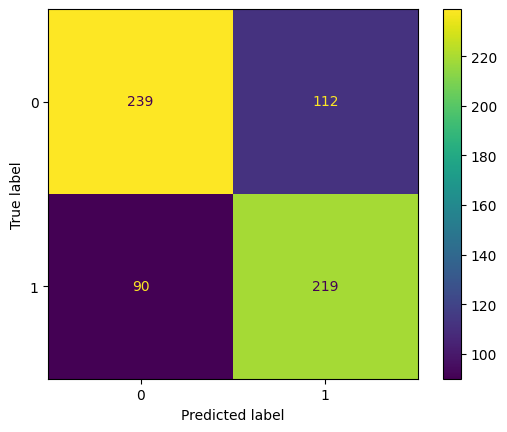

-----------model: Linear SVM-----------
mean AUC: 0.7590840335508556
              precision    recall  f1-score   support

           0       0.72      0.68      0.70       351
           1       0.66      0.70      0.68       309

    accuracy                           0.69       660
   macro avg       0.69      0.69      0.69       660
weighted avg       0.69      0.69      0.69       660


Top 10 features:
therapy          0.714690
aff_empathy      0.593792
sex              0.386204
health           0.353933
motivation       0.328739
study_hours      0.215719
cog_empathy      0.200127
age_capped       0.125940
total_empathy    0.117825
job              0.058616
dtype: float64


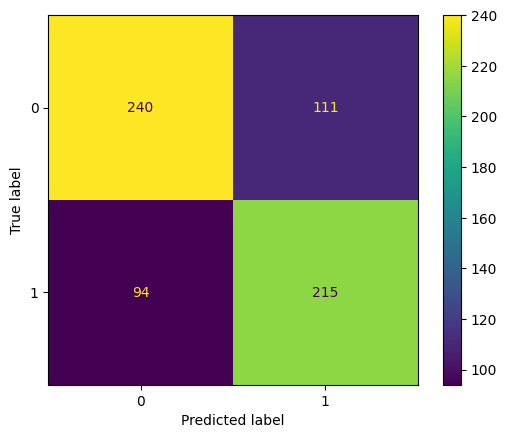

-----------model: Random Forest-----------
mean AUC: 0.7327036146014108
              precision    recall  f1-score   support

           0       0.69      0.71      0.70       351
           1       0.66      0.64      0.65       309

    accuracy                           0.68       660
   macro avg       0.68      0.67      0.68       660
weighted avg       0.68      0.68      0.68       660


Top 10 features:
aff_empathy        0.137813
motivation         0.127095
study_hours        0.113826
health             0.100563
total_empathy      0.099197
cog_empathy        0.096739
emotion_rec_acc    0.079748
age_capped         0.068078
year               0.050655
therapy            0.047625
dtype: float64


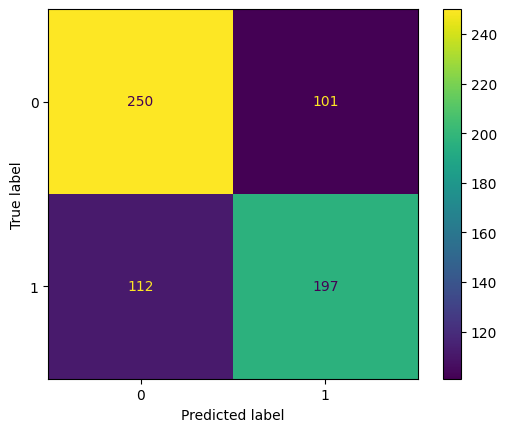

-----------model: AdaBoost-----------
mean AUC: 0.746179036141758
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       351
           1       0.67      0.65      0.66       309

    accuracy                           0.69       660
   macro avg       0.69      0.69      0.69       660
weighted avg       0.69      0.69      0.69       660


Top 10 features:
motivation         0.233249
aff_empathy        0.171917
health             0.148163
emotion_rec_acc    0.099448
therapy            0.088722
total_empathy      0.083188
study_hours        0.081926
cog_empathy        0.052763
sex                0.036402
age_capped         0.004221
dtype: float64


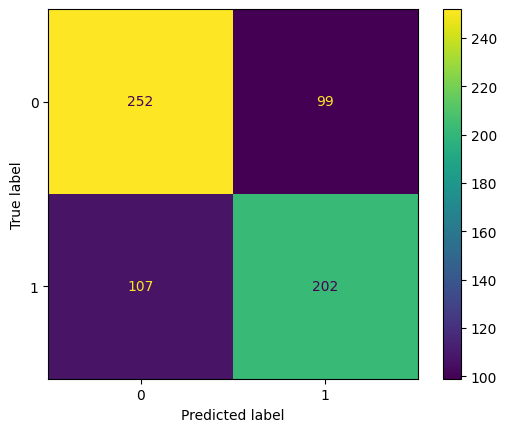

-----------model: XGBoost-----------
mean AUC: 0.742479807453925
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       351
           1       0.67      0.63      0.65       309

    accuracy                           0.68       660
   macro avg       0.68      0.68      0.68       660
weighted avg       0.68      0.68      0.68       660


Top 10 features:
therapy            0.149841
health             0.142742
sex                0.119622
aff_empathy        0.087241
motivation         0.079850
cog_empathy        0.062359
study_hours        0.061392
emotion_rec_acc    0.055365
total_empathy      0.051322
age_capped         0.050859
dtype: float32


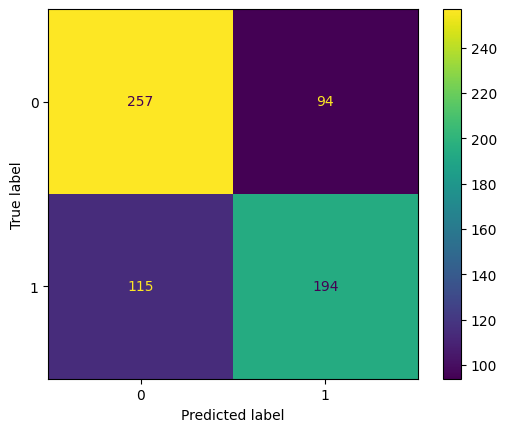

In [ ]:
X_train_selected = X_train[["age_capped", "year", "sex", "part", "job","study_hours", "health",
                   "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]
for name, clf in zip(names, classifiers):
    clf_train(clf, name, X_train_selected, y_train_anxiety)

**after grouping age**

-----------model: Logistic Regression-----------
mean AUC: 0.7599986061264468
              precision    recall  f1-score   support

           0       0.72      0.68      0.70       351
           1       0.66      0.70      0.68       309

    accuracy                           0.69       660
   macro avg       0.69      0.69      0.69       660
weighted avg       0.69      0.69      0.69       660


Top 10 features:
therapy              0.673959
aff_empathy          0.539474
health               0.389435
sex                  0.374953
motivation           0.318051
study_hours          0.227338
cog_empathy          0.185666
total_empathy        0.122959
age_group_23_plus    0.118346
job                  0.108477
dtype: float64


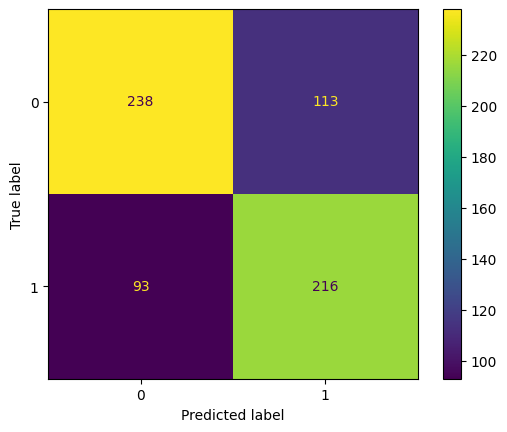

-----------model: Linear SVM-----------
mean AUC: 0.7588465323937278
              precision    recall  f1-score   support

           0       0.71      0.69      0.70       351
           1       0.66      0.69      0.67       309

    accuracy                           0.69       660
   macro avg       0.69      0.69      0.69       660
weighted avg       0.69      0.69      0.69       660


Top 10 features:
therapy              0.690585
aff_empathy          0.602466
sex                  0.414933
health               0.374283
motivation           0.334403
study_hours          0.224442
cog_empathy          0.219261
total_empathy        0.107875
age_group_23_plus    0.101953
job                  0.089634
dtype: float64


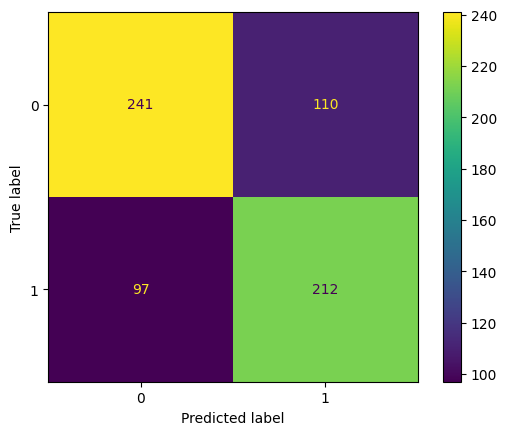

-----------model: Random Forest-----------
mean AUC: 0.7224274041924736
              precision    recall  f1-score   support

           0       0.66      0.70      0.68       351
           1       0.63      0.59      0.61       309

    accuracy                           0.65       660
   macro avg       0.65      0.64      0.64       660
weighted avg       0.65      0.65      0.65       660


Top 10 features:
aff_empathy        0.145698
motivation         0.124006
study_hours        0.117380
health             0.113757
total_empathy      0.110291
cog_empathy        0.108224
emotion_rec_acc    0.087480
year               0.054429
therapy            0.042784
sex                0.039008
dtype: float64


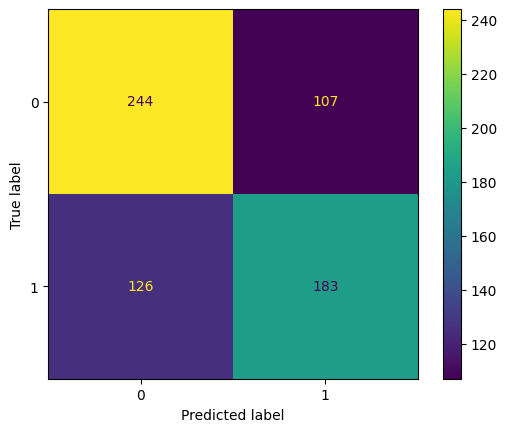

-----------model: AdaBoost-----------
mean AUC: 0.7486618175472721
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       351
           1       0.67      0.64      0.66       309

    accuracy                           0.68       660
   macro avg       0.68      0.68      0.68       660
weighted avg       0.68      0.68      0.68       660


Top 10 features:
motivation         0.230415
aff_empathy        0.169766
health             0.142805
total_empathy      0.101375
emotion_rec_acc    0.098487
therapy            0.087666
study_hours        0.081382
cog_empathy        0.052135
sex                0.035969
job                0.000000
dtype: float64


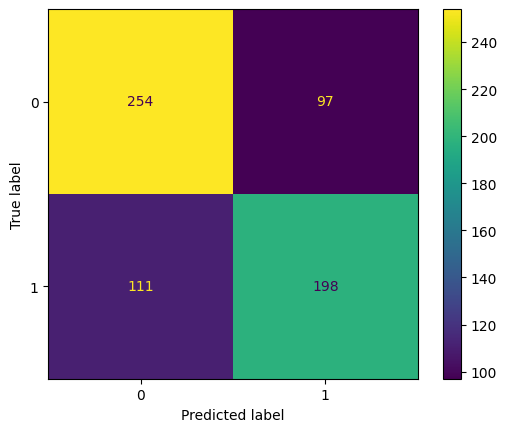

-----------model: XGBoost-----------
mean AUC: 0.7429367106924997
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       351
           1       0.67      0.62      0.65       309

    accuracy                           0.68       660
   macro avg       0.68      0.68      0.68       660
weighted avg       0.68      0.68      0.68       660


Top 10 features:
therapy            0.154407
health             0.137760
sex                0.125502
aff_empathy        0.088585
motivation         0.080254
cog_empathy        0.062223
study_hours        0.060765
emotion_rec_acc    0.058032
year               0.051727
total_empathy      0.048924
dtype: float32


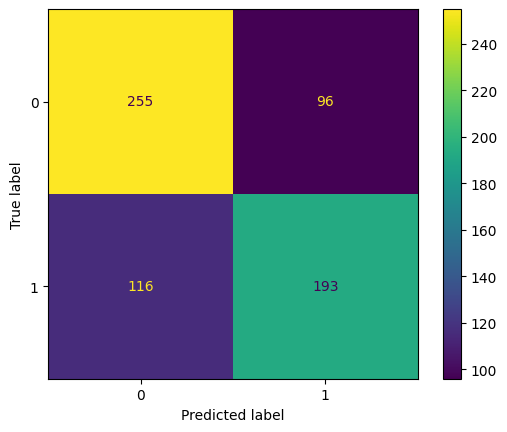

In [ ]:
X_train_selected = X_train[["age_group_23_plus", "year", "sex", "part", "job","study_hours", "health",
                   "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]

for name, clf in zip(names, classifiers):
    clf_train(clf, name, X_train_selected, y_train_anxiety)

**After grouping study hours**

-----------model: Logistic Regression-----------
mean AUC: 0.755525878698952
              precision    recall  f1-score   support

           0       0.72      0.67      0.70       351
           1       0.65      0.71      0.68       309

    accuracy                           0.69       660
   macro avg       0.69      0.69      0.69       660
weighted avg       0.69      0.69      0.69       660


Top 10 features:
therapy              0.663791
aff_empathy          0.538397
health               0.392780
sex                  0.355186
motivation           0.314326
study_group_low      0.233861
cog_empathy          0.188205
job                  0.132862
total_empathy        0.113174
age_group_23_plus    0.105184
dtype: float64


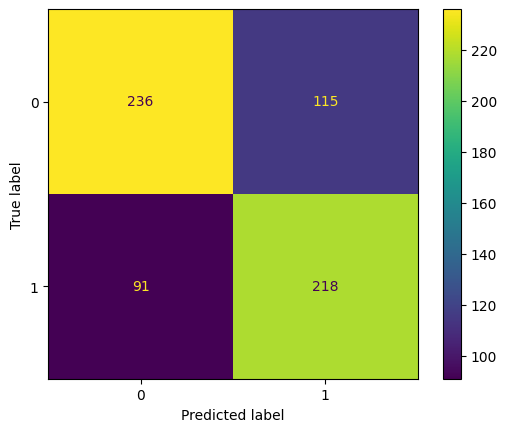

-----------model: Linear SVM-----------
mean AUC: 0.754419887915542
              precision    recall  f1-score   support

           0       0.72      0.69      0.70       351
           1       0.66      0.69      0.67       309

    accuracy                           0.69       660
   macro avg       0.69      0.69      0.69       660
weighted avg       0.69      0.69      0.69       660


Top 10 features:
therapy                 0.630374
aff_empathy             0.604726
health                  0.395140
motivation              0.361130
sex                     0.357489
study_group_low         0.272355
cog_empathy             0.201917
age_group_23_plus       0.128221
study_group_moderate    0.127506
total_empathy           0.116072
dtype: float64


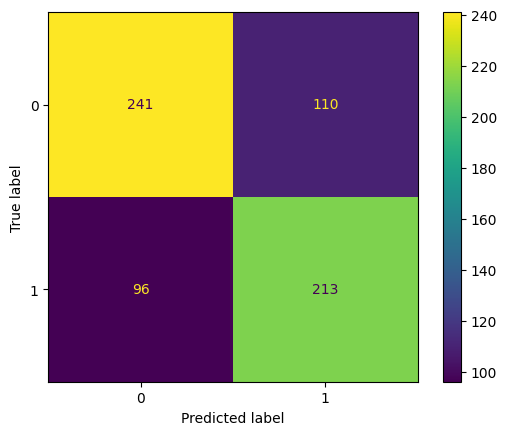

-----------model: Random Forest-----------
mean AUC: 0.7200994491539401
              precision    recall  f1-score   support

           0       0.68      0.70      0.69       351
           1       0.65      0.62      0.63       309

    accuracy                           0.66       660
   macro avg       0.66      0.66      0.66       660
weighted avg       0.66      0.66      0.66       660


Top 10 features:
aff_empathy        0.166928
motivation         0.132496
total_empathy      0.118398
cog_empathy        0.113020
emotion_rec_acc    0.105085
health             0.103909
therapy            0.059438
year               0.056724
sex                0.039499
job                0.023526
dtype: float64


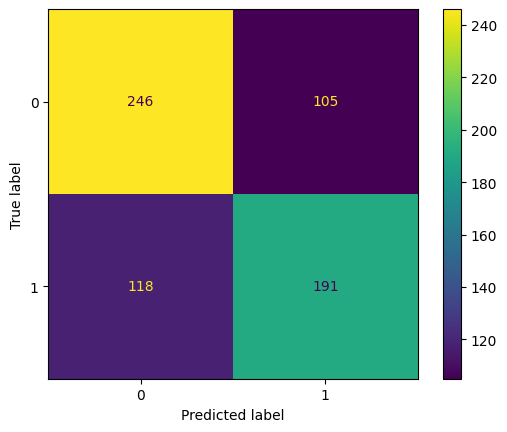

-----------model: AdaBoost-----------
mean AUC: 0.7417918670138227
              precision    recall  f1-score   support

           0       0.69      0.75      0.72       351
           1       0.69      0.62      0.65       309

    accuracy                           0.69       660
   macro avg       0.69      0.69      0.69       660
weighted avg       0.69      0.69      0.69       660


Top 10 features:
motivation         0.267551
aff_empathy        0.176254
health             0.148143
emotion_rec_acc    0.111789
therapy            0.099166
total_empathy      0.098196
cog_empathy        0.047873
study_group_low    0.029115
sex                0.021912
year               0.000000
dtype: float64


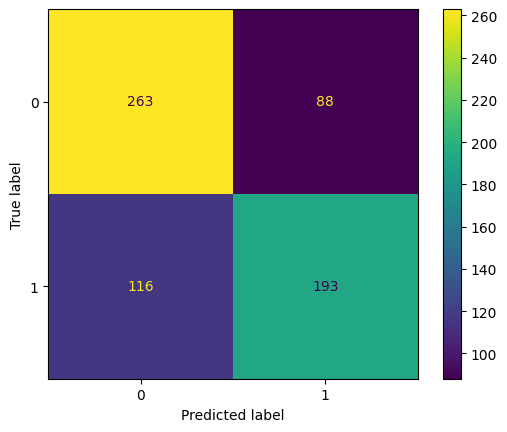

-----------model: XGBoost-----------
mean AUC: 0.7446849898970769
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       351
           1       0.67      0.63      0.65       309

    accuracy                           0.68       660
   macro avg       0.68      0.68      0.68       660
weighted avg       0.68      0.68      0.68       660


Top 10 features:
sex                     0.134960
therapy                 0.134067
health                  0.129871
aff_empathy             0.082413
motivation              0.073950
cog_empathy             0.057578
study_group_moderate    0.055233
emotion_rec_acc         0.052419
year                    0.051813
total_empathy           0.051001
dtype: float32


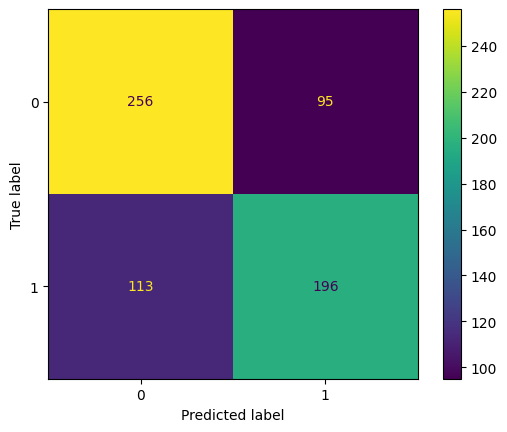

In [ ]:
X_train_selected = X_train[["age_group_23_plus", "year", "sex", "part", "job", "health",
                   "study_group_low", "study_group_moderate", "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]

for name, clf in zip(names, classifiers):
    clf_train(clf, name, X_train_selected, y_train_anxiety)

**Top Features**

-----------model: Logistic Regression-----------
mean AUC: 0.7678857811065228
              precision    recall  f1-score   support

           0       0.73      0.69      0.71       351
           1       0.67      0.72      0.69       309

    accuracy                           0.70       660
   macro avg       0.70      0.70      0.70       660
weighted avg       0.70      0.70      0.70       660


Top 10 features:
therapy              0.685642
aff_empathy          0.552802
health               0.383857
sex                  0.364587
motivation           0.316990
lang_final_French    0.292944
study_hours          0.215042
cog_empathy          0.185360
total_empathy        0.116647
job                  0.110613
dtype: float64


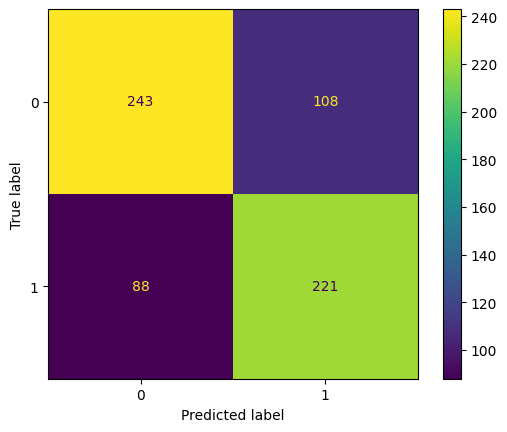

-----------model: Linear SVM-----------
mean AUC: 0.7655333481587568
              precision    recall  f1-score   support

           0       0.71      0.69      0.70       351
           1       0.66      0.69      0.67       309

    accuracy                           0.69       660
   macro avg       0.69      0.69      0.69       660
weighted avg       0.69      0.69      0.69       660


Top 10 features:
therapy              0.734883
aff_empathy          0.611294
sex                  0.388755
health               0.363577
motivation           0.321436
lang_final_French    0.242882
study_hours          0.225263
cog_empathy          0.212259
total_empathy        0.121026
job                  0.050397
dtype: float64


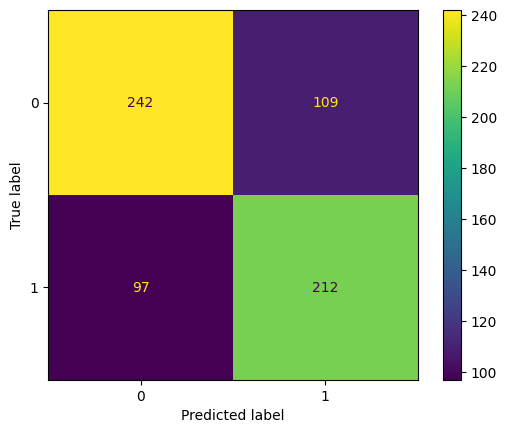

-----------model: Random Forest-----------
mean AUC: 0.7226358308497203
              precision    recall  f1-score   support

           0       0.68      0.71      0.69       351
           1       0.65      0.61      0.63       309

    accuracy                           0.67       660
   macro avg       0.66      0.66      0.66       660
weighted avg       0.66      0.67      0.66       660


Top 10 features:
aff_empathy          0.178777
motivation           0.151313
study_hours          0.144127
total_empathy        0.138366
cog_empathy          0.131058
health               0.115181
therapy              0.054232
sex                  0.039505
job                  0.027945
lang_final_French    0.019497
dtype: float64


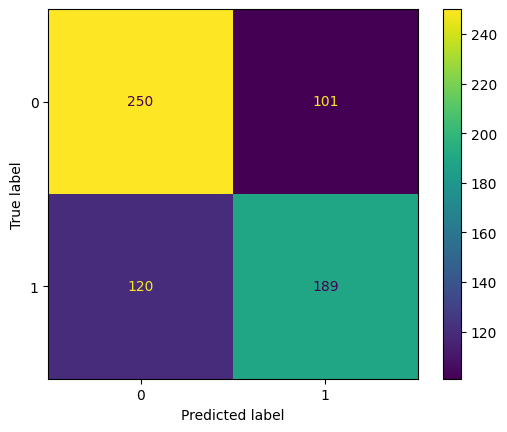

-----------model: AdaBoost-----------
mean AUC: 0.7563649480170287
              precision    recall  f1-score   support

           0       0.70      0.73      0.72       351
           1       0.68      0.65      0.67       309

    accuracy                           0.69       660
   macro avg       0.69      0.69      0.69       660
weighted avg       0.69      0.69      0.69       660


Top 10 features:
motivation           0.266137
aff_empathy          0.166089
health               0.154803
total_empathy        0.110850
therapy              0.096538
study_hours          0.089610
cog_empathy          0.057411
sex                  0.039609
lang_final_French    0.018953
job                  0.000000
dtype: float64


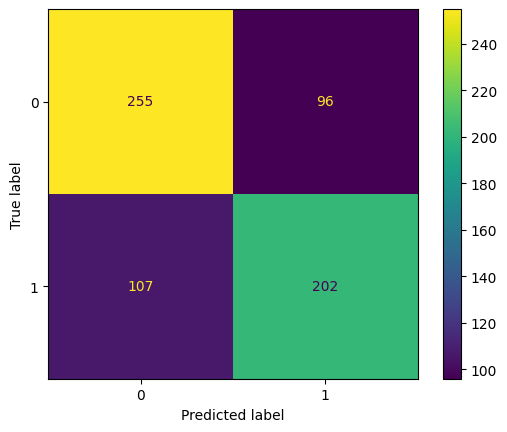

-----------model: XGBoost-----------
mean AUC: 0.7450187747319452
              precision    recall  f1-score   support

           0       0.69      0.72      0.71       351
           1       0.67      0.63      0.65       309

    accuracy                           0.68       660
   macro avg       0.68      0.68      0.68       660
weighted avg       0.68      0.68      0.68       660


Top 10 features:
therapy              0.174920
health               0.165082
sex                  0.136486
aff_empathy          0.107195
motivation           0.088461
lang_final_French    0.077216
study_hours          0.070850
cog_empathy          0.069698
total_empathy        0.062285
job                  0.047807
dtype: float32


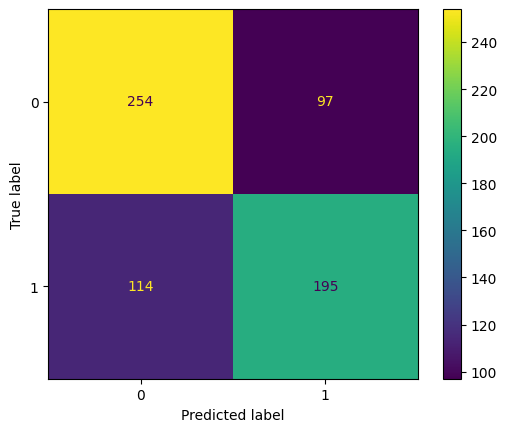

In [ ]:
X_train_selected = X_train[["sex", "job", "health",
                   "study_hours", "therapy", "cog_empathy","aff_empathy",
                   "motivation", "total_empathy", "lang_final_French"]]

for name, clf in zip(names, classifiers):
    clf_train(clf, name, X_train_selected, y_train_anxiety)

**Best model**

-----------model: Logistic Regression-----------
mean AUC: 0.7678857811065228
              precision    recall  f1-score   support

           0       0.73      0.69      0.71       351
           1       0.67      0.72      0.69       309

    accuracy                           0.70       660
   macro avg       0.70      0.70      0.70       660
weighted avg       0.70      0.70      0.70       660


Top 10 features:
therapy              0.685642
aff_empathy          0.552802
health               0.383857
sex                  0.364587
motivation           0.316990
lang_final_French    0.292944
study_hours          0.215042
cog_empathy          0.185360
total_empathy        0.116647
job                  0.110613
dtype: float64


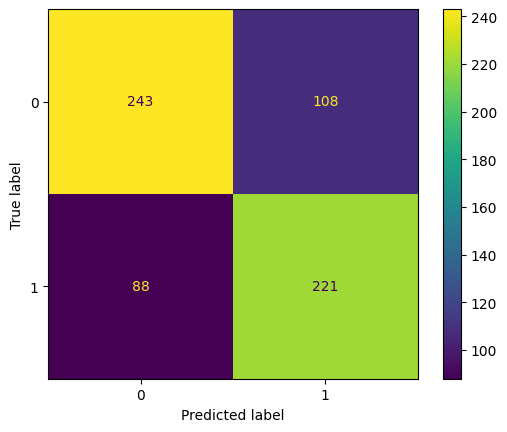

In [ ]:
X_train_selected = X_train[["sex", "job", "health",
                   "study_hours", "therapy", "cog_empathy","aff_empathy",
                   "motivation", "total_empathy", "lang_final_French"]]
clf = LogisticRegression(max_iter=1000, C=0.1, class_weight='balanced')
best_model = clf_train(clf, "Logistic Regression", X_train_selected, y_train_anxiety)

**Testing on the Best Model**

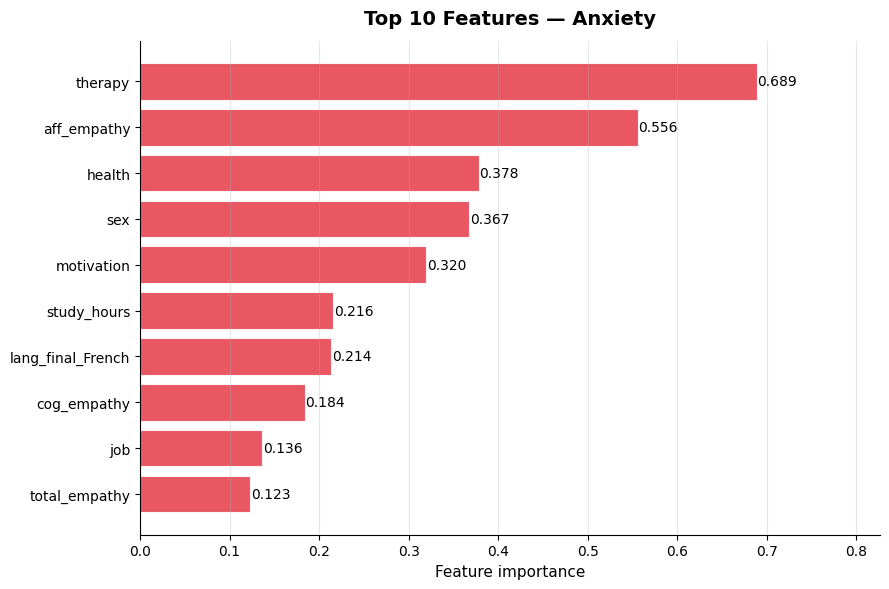

In [ ]:
X_train_selected = X_train[['age_capped', 'year', 'sex', 'lang_final_French',
       'lang_final_German', 'lang_final_Italian', 'lang_final_Other', 'part',
       'job', 'study_hours', 'health', 'therapy', 'total_empathy', 'cog_empathy', 'aff_empathy',
       'motivation', 'emotion_rec_acc']]

clf = LogisticRegression(max_iter=1000, C=0.1, class_weight='balanced')
clf.fit(X_train_selected, y_train_anxiety)

importance = pd.Series(
    np.abs(clf.coef_[0]),
    index=X_train_selected.columns
).sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(importance.index, importance.values,
               color='#E63946', alpha=0.85,
               edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, importance.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('Top 10 Features — Anxiety',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Feature importance', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, importance.values.max() * 1.2)

plt.tight_layout()
plt.savefig('feature_importance_anxiety.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
y_test

,depression_score,depression_category,anxiety_score,burnout_exhaustion,burnout_cynicism,burnout_efficacy
347,6,0,46,19,18,23
559,6,0,27,12,5,28
785,13,0,44,14,17,18
828,24,1,62,18,20,17
56,4,0,34,26,23,15
...,...,...,...,...,...,...
292,31,1,51,13,7,23
63,6,0,44,17,13,20
178,15,0,59,18,9,20
791,5,0,39,21,7,26


-----------model: Logistic Regression-----------
CV AUC:   0.7595
Test AUC: 0.8121
Gap:      +0.0526  check split
              precision    recall  f1-score   support

           0       0.70      0.76      0.73       105
           1       0.76      0.70      0.73       116

    accuracy                           0.73       221
   macro avg       0.73      0.73      0.73       221
weighted avg       0.73      0.73      0.73       221



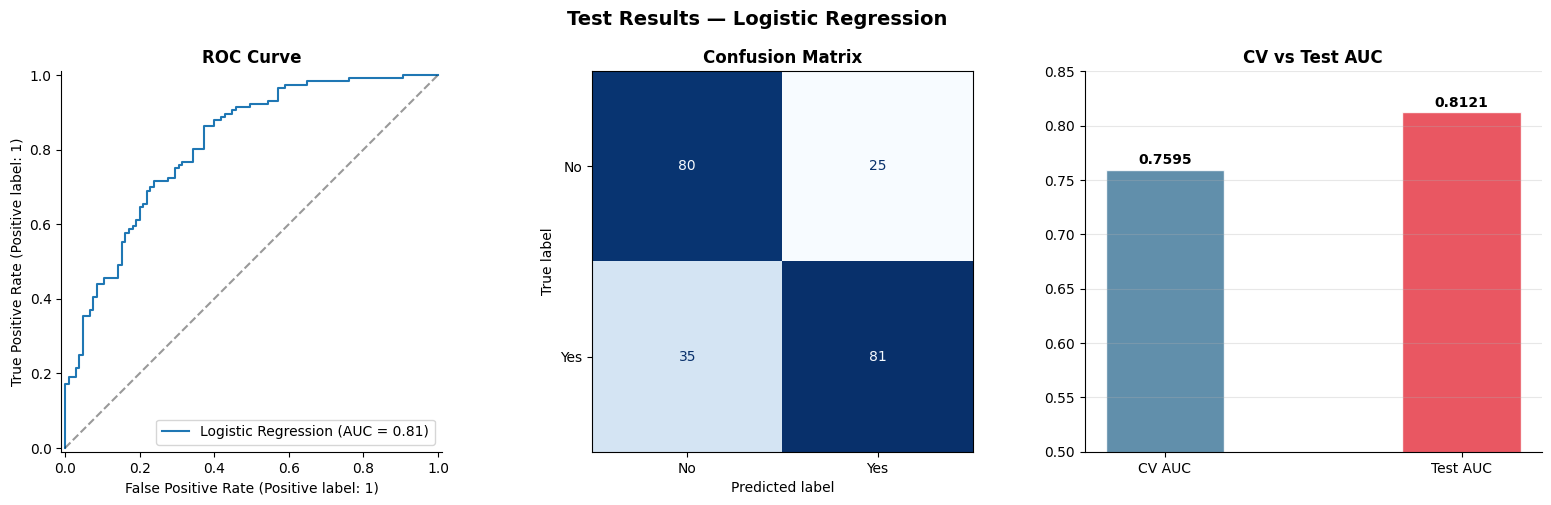

In [ ]:
X_test_selected = X_test[["sex", "job", "health",
                   "study_hours", "therapy", "cog_empathy","aff_empathy",
                   "motivation", "total_empathy", "lang_final_French"]]
y_test_anxiety = (y_test['anxiety_score'] >= 44).astype(int)
clf_test(best_model, "Logistic Regression",X_train_selected, y_train_anxiety, X_test_selected, y_test_anxiety)

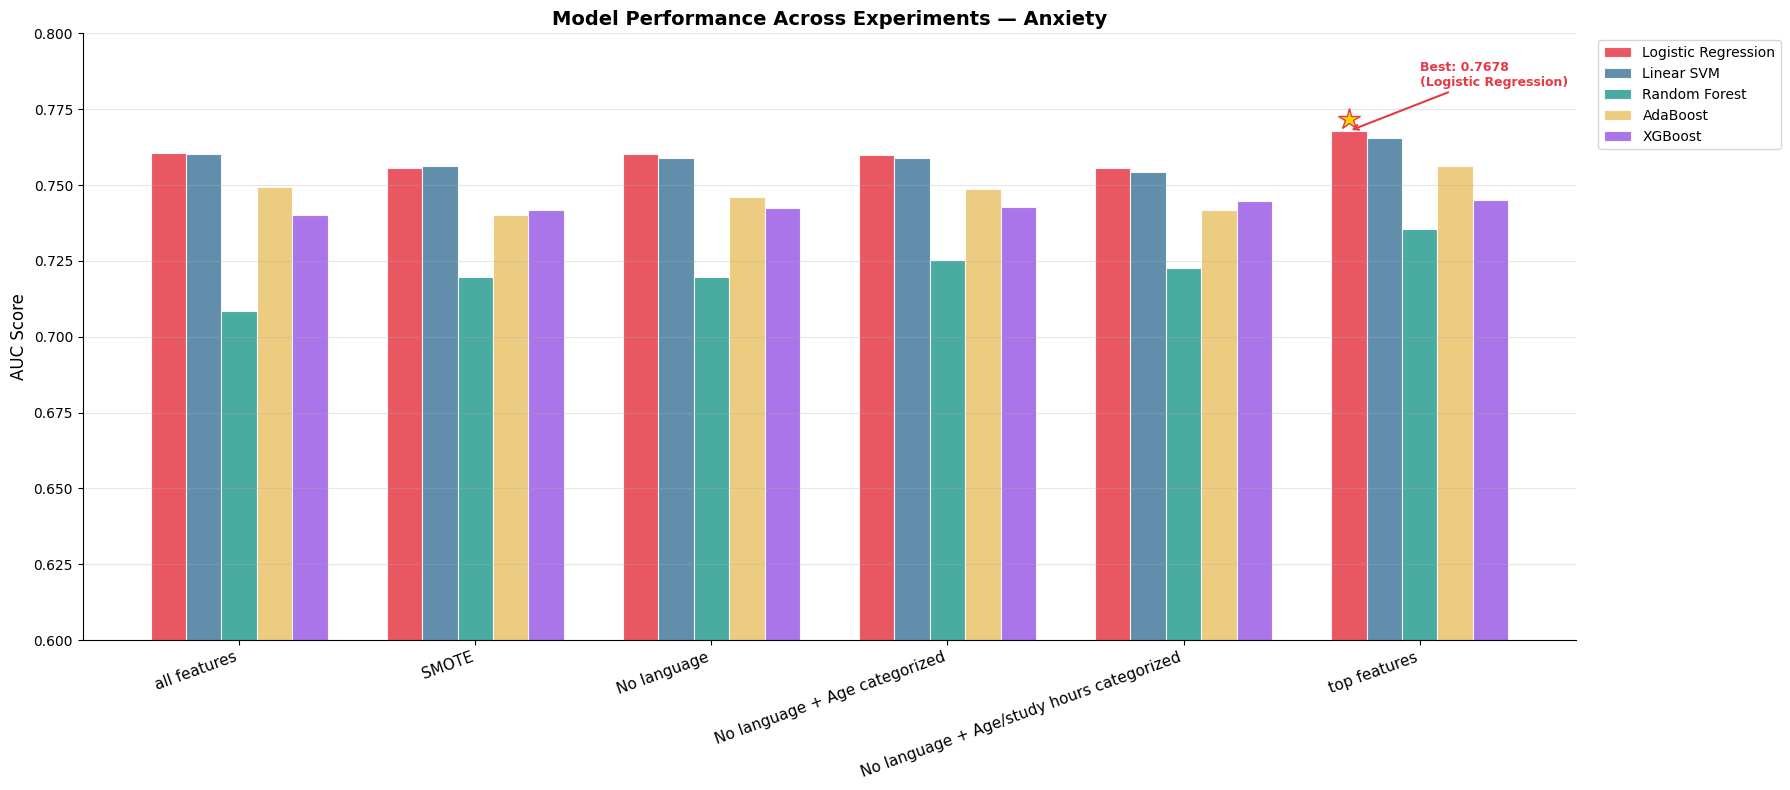

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

experiments = [
    'all features',
    'SMOTE',
    'No language',
    'No language + Age categorized',
    'No language + Age/study hours categorized',
    'top features'
]

models = ["Logistic Regression",
    "Linear SVM",
    "Random Forest",
    "AdaBoost",
    "XGBoost"]
colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#9B5DE5']

auc_results = {
    'Logistic Regression': [0.7604, 0.7557, 0.7602, 0.7599, 0.7555, 0.7678],
    'Linear SVM':          [0.7601, 0.7563, 0.759,  0.7588, 0.7544, 0.7655],
    'Random Forest':       [0.7086, 0.7197, 0.7197, 0.7252, 0.7226, 0.7354],
    'AdaBoost':            [0.7493, 0.7401, 0.7461, 0.7486, 0.7417, 0.7563],
    'XGBoost':             [0.7402, 0.7416, 0.7424, 0.7429, 0.7446, 0.745],
}
fig, ax = plt.subplots(figsize=(18, 8))
x     = np.arange(len(experiments))
width = 0.15
n     = len(models)

best_auc, best_model_i, best_exp_i = 0, 0, 0
for i, model in enumerate(models):
    for j, auc in enumerate(auc_results[model]):
        if auc > best_auc:
            best_auc, best_model_i, best_exp_i = auc, i, j

for i, (model, color) in enumerate(zip(models, colors)):
    offset = (i - n/2 + 0.5) * width
    ax.bar(x + offset, auc_results[model], width,
           label=model, color=color,
           alpha=0.85, edgecolor='white', linewidth=0.8)

best_x = x[best_exp_i] + (best_model_i - n/2 + 0.5) * width
ax.annotate(
    f'Best: {best_auc:.4f}\n({models[best_model_i]})',
    xy=(best_x, best_auc),
    xytext=(best_x + 0.3, best_auc + 0.015),
    fontsize=9, fontweight='bold', color=colors[best_model_i],
    arrowprops=dict(arrowstyle='->', color=colors[best_model_i], lw=1.5),
)
ax.plot(best_x, best_auc + 0.004, '*',
        markersize=16, color='gold',
        markeredgecolor=colors[best_model_i], markeredgewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(experiments, rotation=20, ha='right', fontsize=11)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_ylim(0.60, 0.8)
ax.set_title('Model Performance Across Experiments — Anxiety',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('anxiety_experiment_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

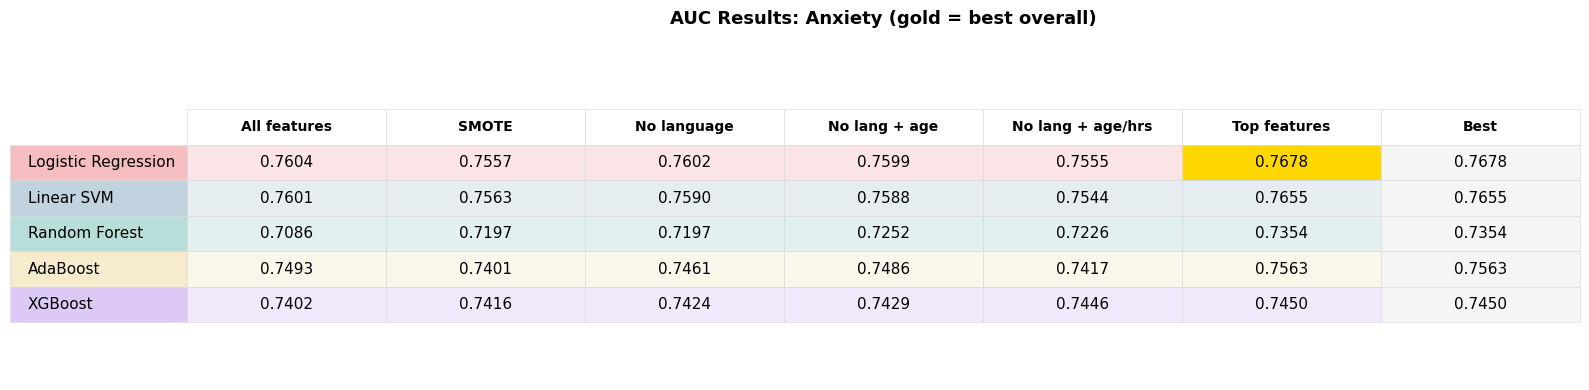

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

experiments = ['All features', 'SMOTE', 'No language', 'No lang + age', 'No lang + age/hrs', 'Top features']
models      = ['Logistic Regression', 'Linear SVM', 'Random Forest', 'AdaBoost', 'XGBoost']
colors      = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#9B5DE5']

auc_results = {
    'Logistic Regression': [0.7604, 0.7557, 0.7602, 0.7599, 0.7555, 0.7678],
    'Linear SVM':          [0.7601, 0.7563, 0.759,  0.7588, 0.7544, 0.7655],
    'Random Forest':       [0.7086, 0.7197, 0.7197, 0.7252, 0.7226, 0.7354],
    'AdaBoost':            [0.7493, 0.7401, 0.7461, 0.7486, 0.7417, 0.7563],
    'XGBoost':             [0.7402, 0.7416, 0.7424, 0.7429, 0.7446, 0.745],
}
global_best = max(v for vals in auc_results.values() for v in vals)

cell_text   = []
cell_colors = []

for model, color in zip(models, colors):
    row        = [f'{v:.4f}' for v in auc_results[model]]
    row.append(f'{max(auc_results[model]):.4f}')
    cell_text.append(row)

    row_colors = []
    for v in auc_results[model]:
        if v == global_best:
            row_colors.append('#FFD700')
        else:
            row_colors.append(color + '22')
    row_colors.append('#f5f5f5')
    cell_colors.append(row_colors)

col_labels  = experiments + ['Best']
row_colors  = [c + '55' for c in colors]

fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')

table = ax.table(
    cellText=cell_text,
    rowLabels=models,
    colLabels=col_labels,
    cellColours=cell_colors,
    rowColours=row_colors,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#dddddd')
    cell.set_linewidth(0.5)
    if row == 0:
        cell.set_text_props(fontweight='bold', fontsize=10)

ax.set_title('AUC Results: Anxiety (gold = best overall)',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('anx_auc_table.png', dpi=600, bbox_inches='tight')
plt.show()

### **3. How do demographic characteristics (sex, age, year of study, and mother tongue) and health traits relate to mental health outcomes burn out scores among medical students in Switzerland?**

Based on this offical [link](https://different.hr/wp-content/uploads/2020/05/Maslach-Burnout-Inventory-MBI.pdf), we can view 3 classes for each burn out score.

In [ ]:
def categorize_exhaustion(score):
    if score <= 17:   return 0  # low
    elif score <= 29: return 1  # moderate
    else:             return 2  # high

def categorize_cynicism(score):
    if score <= 5:    return 0  # low
    elif score <= 11: return 1  # moderate
    else:             return 2  # high

def categorize_efficacy(score):
    if score >= 40:   return 0  # low burnout
    elif score >= 34: return 1  # moderate
    else:             return 2  # high burnout

y_exhaustion_3class = y_train['burnout_exhaustion'].apply(categorize_exhaustion)
y_cynicism_3class   = y_train['burnout_cynicism'].apply(categorize_cynicism)
y_efficacy_3class   = y_train['burnout_efficacy'].apply(categorize_efficacy)



**Plot the distribution**

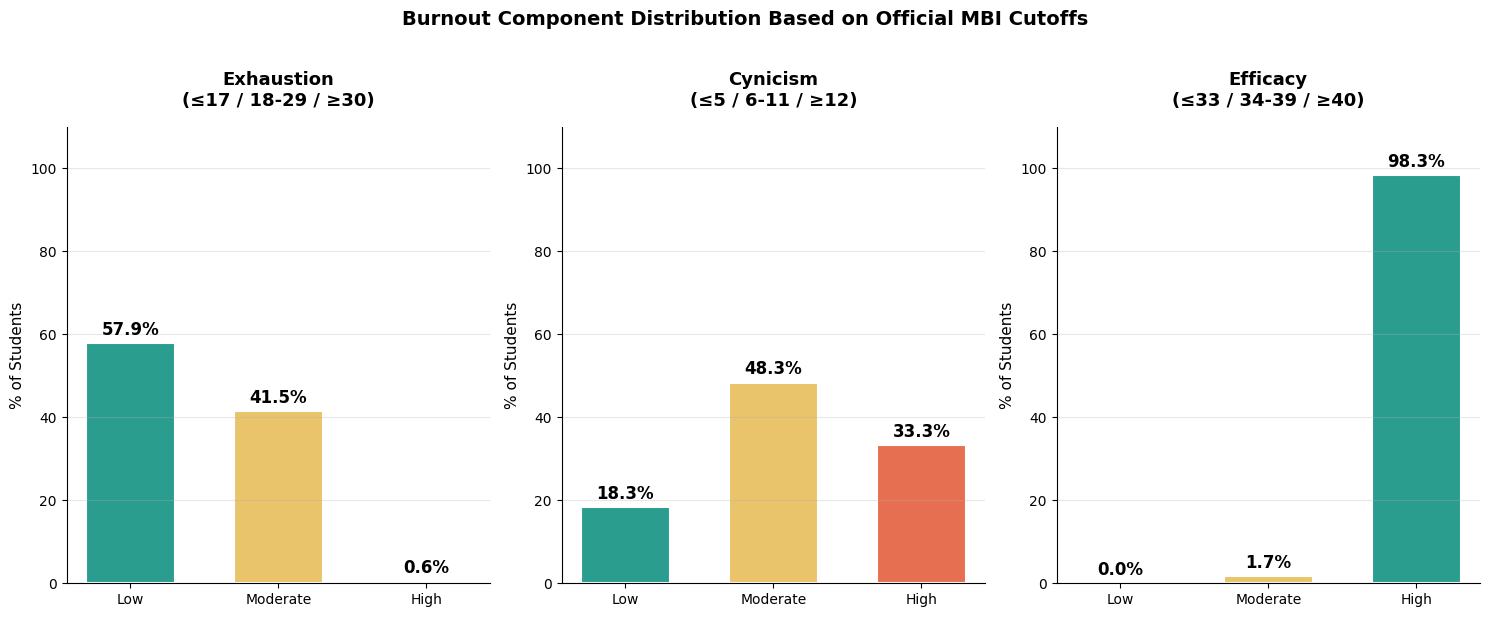

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

components = {
    'Exhaustion': {
        'data':    y_exhaustion_3class,
        'colors':  ['#2A9D8F', '#E9C46A', '#E76F51'],
        'cutoffs': '≤17 / 18-29 / ≥30'
    },
    'Cynicism': {
        'data':    y_cynicism_3class,
        'colors':  ['#2A9D8F', '#E9C46A', '#E76F51'],
        'cutoffs': '≤5 / 6-11 / ≥12'
    },
    'Efficacy': {
        'data':    y_efficacy_3class,
        'colors':  ['#E76F51', '#E9C46A', '#2A9D8F'],
        'cutoffs': '≤33 / 34-39 / ≥40'
    },
}

labels = ['Low', 'Moderate', 'High']

for ax, (name, info) in zip(axes, components.items()):
    pct    = info['data'].value_counts(normalize=True).sort_index() * 100
    values = [pct.get(i, 0) for i in range(3)]

    bars = ax.bar(labels, values, color=info['colors'],
                  edgecolor='white', linewidth=1.5, width=0.6)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'{val:.1f}%',
                ha='center', va='bottom',
                fontsize=12, fontweight='bold')

    ax.set_title(f'{name}\n({info["cutoffs"]})',
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_ylabel('% of Students', fontsize=11)
    ax.set_ylim(0, 110)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Burnout Component Distribution Based on Official MBI Cutoffs',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('burnout_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

The classes are too imbalanced to be used. So we can use the data-driven cuttoffs for our classification.

In [ ]:
for col in ['burnout_exhaustion', 'burnout_cynicism', 'burnout_efficacy']:
    mean = y_train[col].mean()
    std  = y_train[col].std()
    print(f"{col}: mean={mean:.2f}, std={std:.2f}, cutoff (mean + 0.5*std) = {mean + 0.5*std:.2f}")

burnout_exhaustion: mean=16.82, std=5.23, cutoff (mean + 0.5*std) = 19.44
burnout_cynicism: mean=9.94, std=4.55, cutoff (mean + 0.5*std) = 12.21
burnout_efficacy: mean=24.44, std=4.62, cutoff (mean + 0.5*std) = 26.74


In [ ]:
y_exhaustion = (y_train['burnout_exhaustion'] >= 19.44).astype(int)
y_cynicism   = (y_train['burnout_cynicism']   >= 12.21).astype(int)
y_efficacy   = (y_train['burnout_efficacy']   <= 26.74).astype(int)

for name, target in [('Exhaustion', y_exhaustion),
                      ('Cynicism',   y_cynicism),
                      ('Efficacy',   y_efficacy)]:
    pct = target.value_counts(normalize=True) * 100
    print(f"{name:12s}: {pct[0]:.1f}% not burned out / {pct[1]:.1f}% burned out")

Exhaustion  : 70.0% not burned out / 30.0% burned out
Cynicism    : 73.6% not burned out / 26.4% burned out
Efficacy    : 34.2% not burned out / 65.8% burned out


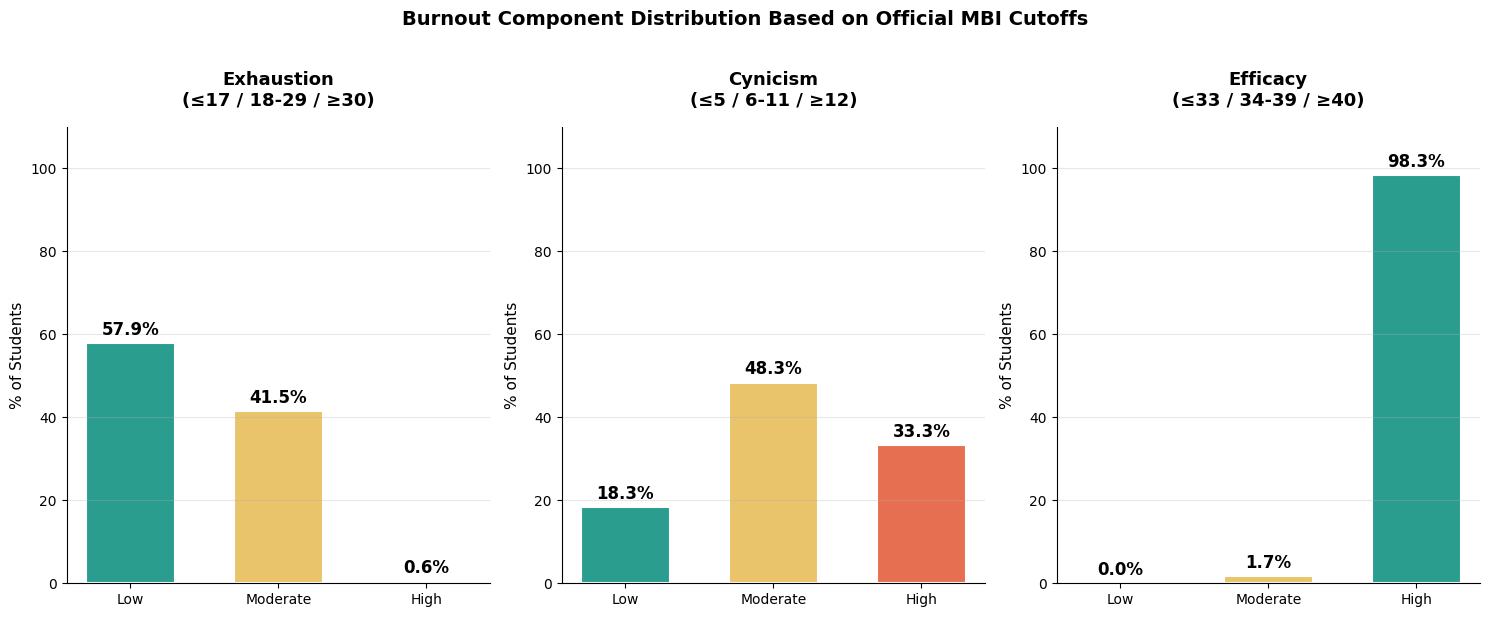

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

components = {
    'Exhaustion': {
        'data':    y_exhaustion_3class,
        'colors':  ['#2A9D8F', '#E9C46A', '#E76F51'],
        'cutoffs': '≤17 / 18-29 / ≥30'
    },
    'Cynicism': {
        'data':    y_cynicism_3class,
        'colors':  ['#2A9D8F', '#E9C46A', '#E76F51'],
        'cutoffs': '≤5 / 6-11 / ≥12'
    },
    'Efficacy': {
        'data':    y_efficacy_3class,
        'colors':  ['#E76F51', '#E9C46A', '#2A9D8F'],
        'cutoffs': '≤33 / 34-39 / ≥40'
    },
}

labels = ['Low', 'Moderate', 'High']

for ax, (name, info) in zip(axes, components.items()):
    pct    = info['data'].value_counts(normalize=True).sort_index() * 100
    values = [pct.get(i, 0) for i in range(3)]

    bars = ax.bar(labels, values, color=info['colors'],
                  edgecolor='white', linewidth=1.5, width=0.6)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'{val:.1f}%',
                ha='center', va='bottom',
                fontsize=12, fontweight='bold')

    ax.set_title(f'{name}\n({info["cutoffs"]})',
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_ylabel('% of Students', fontsize=11)
    ax.set_ylim(0, 110)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Burnout Component Distribution Based on Official MBI Cutoffs',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('burnout_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
y_train_burnouts = pd.DataFrame({
    'exhaustion': y_exhaustion,
    'cynicism':   y_cynicism,
    'efficacy':   y_efficacy
})

#### **multi label classification**

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

def train_multi_label(model, name, X, y):
    print(f"-------------{name}-------------")

    classifier = MultiOutputClassifier(model)

    # Predictions (labels)
    y_pred = cross_val_predict(classifier, X, y, cv=5)

    # Probabilities (for AUC)
    y_prob = cross_val_predict(classifier, X, y, cv=5, method='predict_proba')

    # y_prob is a list → convert to array
    y_prob = np.stack([p[:, 1] for p in y_prob], axis=1)

    aucs = []

    for i, col in enumerate(y.columns):
        print(f"\n{'='*40}")
        print(f"  {col.upper()}")
        print(f"{'='*40}")

        print(classification_report(
            y[col],
            y_pred[:, i],
            target_names=['No burnout', 'Burnout']
        ))

        auc = roc_auc_score(y[col], y_prob[:, i])
        aucs.append(auc)

        print(f"AUC: {auc:.4f}")

    print(f"\nMacro AUC: {np.mean(aucs):.4f}")

    return classifier

**all features**

In [ ]:
X_train_selected = X_train[['age_capped', 'year', 'sex', 'lang_final_French',
       'lang_final_German', 'lang_final_Italian', 'lang_final_Other', 'part',
       'job', 'study_hours', 'health', 'therapy', 'total_empathy', 'cog_empathy', 'aff_empathy',
       'motivation', 'emotion_rec_acc']]

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "AdaBoost": AdaBoostClassifier(n_estimators=100),
}

for name, model in models.items():
    train_multi_label(model, name, X_train_selected, y_train_burnouts)

-------------Logistic Regression-------------

  EXHAUSTION
              precision    recall  f1-score   support

  No burnout       0.73      0.91      0.81       462
     Burnout       0.52      0.22      0.31       198

    accuracy                           0.71       660
   macro avg       0.63      0.57      0.56       660
weighted avg       0.67      0.71      0.66       660

AUC: 0.6620

  CYNICISM
              precision    recall  f1-score   support

  No burnout       0.74      0.96      0.84       486
     Burnout       0.39      0.07      0.12       174

    accuracy                           0.73       660
   macro avg       0.56      0.51      0.48       660
weighted avg       0.65      0.73      0.65       660

AUC: 0.6109

  EFFICACY
              precision    recall  f1-score   support

  No burnout       0.61      0.32      0.42       226
     Burnout       0.72      0.89      0.79       434

    accuracy                           0.70       660
   macro avg       0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



  EXHAUSTION
              precision    recall  f1-score   support

  No burnout       0.72      0.92      0.81       462
     Burnout       0.46      0.15      0.23       198

    accuracy                           0.69       660
   macro avg       0.59      0.54      0.52       660
weighted avg       0.64      0.69      0.63       660

AUC: 0.6418

  CYNICISM
              precision    recall  f1-score   support

  No burnout       0.74      0.97      0.84       486
     Burnout       0.41      0.06      0.11       174

    accuracy                           0.73       660
   macro avg       0.57      0.52      0.47       660
weighted avg       0.65      0.73      0.65       660

AUC: 0.5620

  EFFICACY
              precision    recall  f1-score   support

  No burnout       0.53      0.28      0.36       226
     Burnout       0.70      0.87      0.77       434

    accuracy                           0.67       660
   macro avg       0.61      0.57      0.57       660
weighted avg

**no lang**

In [ ]:
X_train_selected = X_train[['age_capped', 'year', 'sex', 'part',
       'job', 'study_hours', 'health', 'therapy', 'total_empathy', 'cog_empathy', 'aff_empathy',
       'motivation', 'emotion_rec_acc']]

for name, model in models.items():
    train_multi_label(model, name, X_train_selected, y_train_burnouts)

-------------Logistic Regression-------------

  EXHAUSTION
              precision    recall  f1-score   support

  No burnout       0.73      0.92      0.82       462
     Burnout       0.53      0.21      0.30       198

    accuracy                           0.71       660
   macro avg       0.63      0.56      0.56       660
weighted avg       0.67      0.71      0.66       660

AUC: 0.6647

  CYNICISM
              precision    recall  f1-score   support

  No burnout       0.74      0.97      0.84       486
     Burnout       0.37      0.06      0.10       174

    accuracy                           0.73       660
   macro avg       0.56      0.51      0.47       660
weighted avg       0.64      0.73      0.64       660

AUC: 0.6167

  EFFICACY
              precision    recall  f1-score   support

  No burnout       0.61      0.32      0.42       226
     Burnout       0.72      0.89      0.80       434

    accuracy                           0.70       660
   macro avg       0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



  EXHAUSTION
              precision    recall  f1-score   support

  No burnout       0.72      0.93      0.81       462
     Burnout       0.48      0.16      0.24       198

    accuracy                           0.70       660
   macro avg       0.60      0.54      0.52       660
weighted avg       0.65      0.70      0.64       660

AUC: 0.6303

  CYNICISM
              precision    recall  f1-score   support

  No burnout       0.74      0.94      0.83       486
     Burnout       0.29      0.07      0.11       174

    accuracy                           0.71       660
   macro avg       0.52      0.50      0.47       660
weighted avg       0.62      0.71      0.64       660

AUC: 0.5513

  EFFICACY
              precision    recall  f1-score   support

  No burnout       0.52      0.26      0.35       226
     Burnout       0.69      0.87      0.77       434

    accuracy                           0.66       660
   macro avg       0.61      0.57      0.56       660
weighted avg

**age category**

In [ ]:
X_train_selected = X_train[["age_group_23_plus", "year", "sex", "part", "job", "health",
                   "study_hours", "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]

for name, model in models.items():
    train_multi_label(model, name, X_train_selected, y_train_burnouts)

-------------Logistic Regression-------------

  EXHAUSTION
              precision    recall  f1-score   support

  No burnout       0.73      0.92      0.81       462
     Burnout       0.53      0.21      0.30       198

    accuracy                           0.71       660
   macro avg       0.63      0.57      0.56       660
weighted avg       0.67      0.71      0.66       660

AUC: 0.6648

  CYNICISM
              precision    recall  f1-score   support

  No burnout       0.74      0.97      0.84       486
     Burnout       0.41      0.07      0.12       174

    accuracy                           0.73       660
   macro avg       0.58      0.52      0.48       660
weighted avg       0.66      0.73      0.65       660

AUC: 0.6196

  EFFICACY
              precision    recall  f1-score   support

  No burnout       0.59      0.31      0.40       226
     Burnout       0.71      0.89      0.79       434

    accuracy                           0.69       660
   macro avg       0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



  EXHAUSTION
              precision    recall  f1-score   support

  No burnout       0.72      0.92      0.81       462
     Burnout       0.45      0.15      0.22       198

    accuracy                           0.69       660
   macro avg       0.58      0.53      0.51       660
weighted avg       0.64      0.69      0.63       660

AUC: 0.6397

  CYNICISM
              precision    recall  f1-score   support

  No burnout       0.74      0.94      0.83       486
     Burnout       0.29      0.07      0.11       174

    accuracy                           0.71       660
   macro avg       0.52      0.50      0.47       660
weighted avg       0.62      0.71      0.64       660

AUC: 0.5602

  EFFICACY
              precision    recall  f1-score   support

  No burnout       0.54      0.30      0.38       226
     Burnout       0.70      0.87      0.78       434

    accuracy                           0.67       660
   macro avg       0.62      0.58      0.58       660
weighted avg

**study hours category**

In [ ]:
X_train_selected = X_train[["age_group_23_plus", "year", "sex", "part", "job", "health",
                   "study_group_low", "study_group_moderate", "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]


for name, model in models.items():
    train_multi_label(model, name, X_train_selected, y_train_burnouts)

-------------Logistic Regression-------------

  EXHAUSTION
              precision    recall  f1-score   support

  No burnout       0.73      0.92      0.82       462
     Burnout       0.53      0.21      0.30       198

    accuracy                           0.71       660
   macro avg       0.63      0.56      0.56       660
weighted avg       0.67      0.71      0.66       660

AUC: 0.6593

  CYNICISM
              precision    recall  f1-score   support

  No burnout       0.74      0.96      0.84       486
     Burnout       0.42      0.08      0.14       174

    accuracy                           0.73       660
   macro avg       0.58      0.52      0.49       660
weighted avg       0.66      0.73      0.65       660

AUC: 0.6136

  EFFICACY
              precision    recall  f1-score   support

  No burnout       0.58      0.29      0.38       226
     Burnout       0.71      0.89      0.79       434

    accuracy                           0.68       660
   macro avg       0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



  EXHAUSTION
              precision    recall  f1-score   support

  No burnout       0.72      0.92      0.80       462
     Burnout       0.43      0.15      0.22       198

    accuracy                           0.69       660
   macro avg       0.58      0.53      0.51       660
weighted avg       0.63      0.69      0.63       660

AUC: 0.6464

  CYNICISM
              precision    recall  f1-score   support

  No burnout       0.74      0.95      0.83       486
     Burnout       0.26      0.05      0.09       174

    accuracy                           0.71       660
   macro avg       0.50      0.50      0.46       660
weighted avg       0.61      0.71      0.63       660

AUC: 0.5500

  EFFICACY
              precision    recall  f1-score   support

  No burnout       0.52      0.29      0.38       226
     Burnout       0.70      0.86      0.77       434

    accuracy                           0.67       660
   macro avg       0.61      0.58      0.57       660
weighted avg

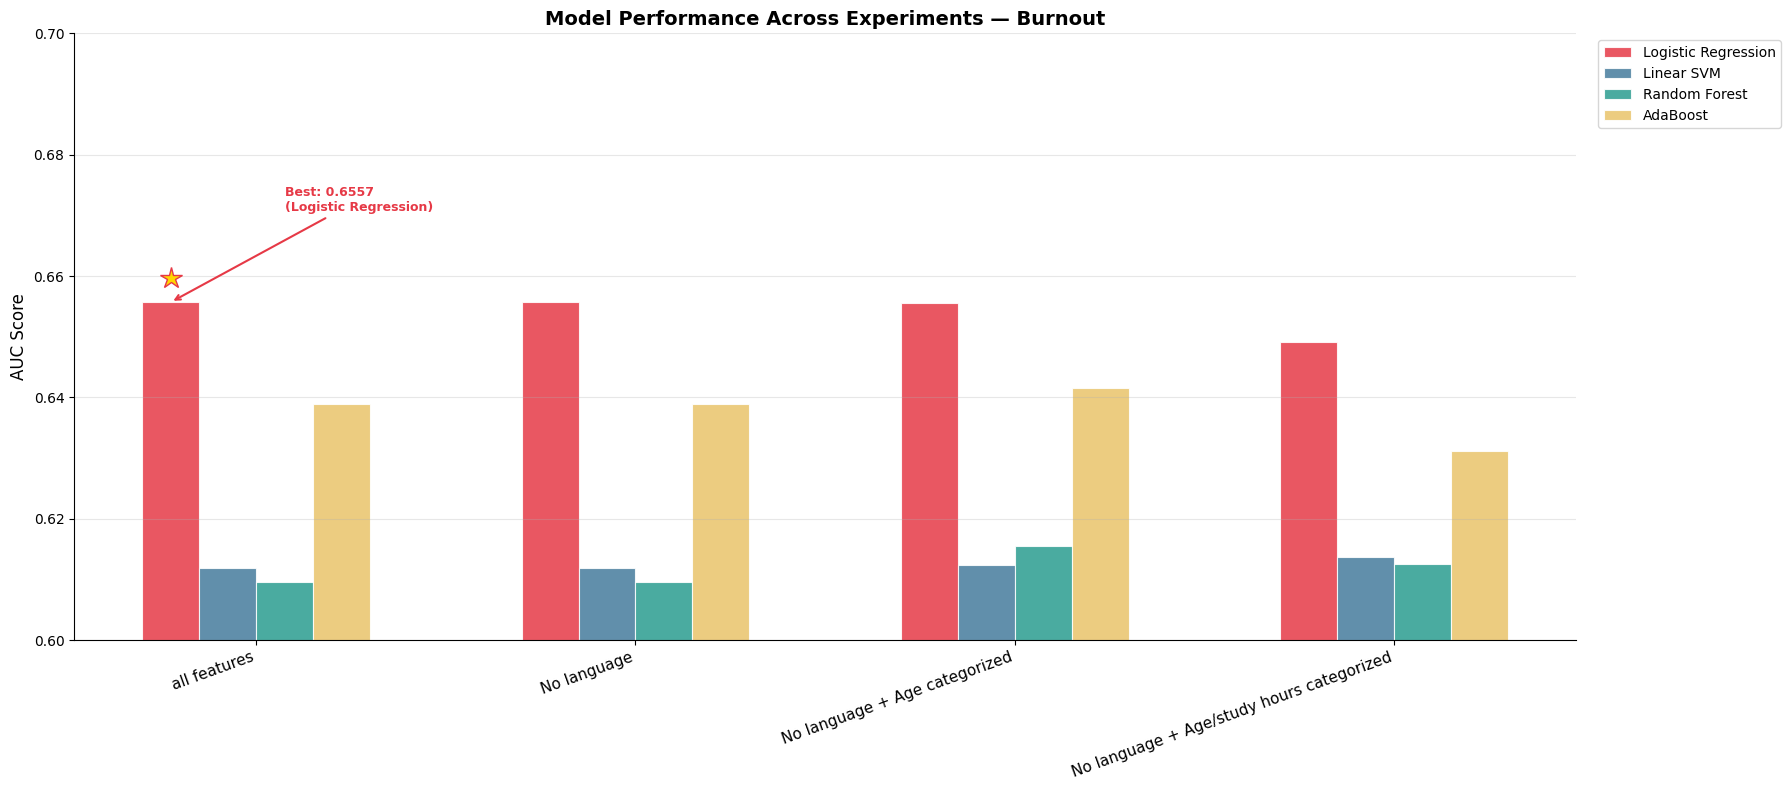

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

experiments = [
    'all features',
    'No language',
    'No language + Age categorized',
    'No language + Age/study hours categorized',
]

models = ["Logistic Regression",
    "Linear SVM",
    "Random Forest",
    "AdaBoost"]
colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#9B5DE5']

auc_results = {
    'Logistic Regression': [0.6557, 0.6557, 0.6556, 0.6491],
    'Linear SVM':          [0.6119, 0.6119, 0.6124, 0.6137],
    'Random Forest':       [0.6096, 0.6096, 0.6155, 0.6125],
    'AdaBoost':            [0.6389, 0.6389, 0.6415, 0.6312],
}

fig, ax = plt.subplots(figsize=(18, 8))
x     = np.arange(len(experiments))
width = 0.15
n     = len(models)

best_auc, best_model_i, best_exp_i = 0, 0, 0
for i, model in enumerate(models):
    for j, auc in enumerate(auc_results[model]):
        if auc > best_auc:
            best_auc, best_model_i, best_exp_i = auc, i, j

for i, (model, color) in enumerate(zip(models, colors)):
    offset = (i - n/2 + 0.5) * width
    ax.bar(x + offset, auc_results[model], width,
           label=model, color=color,
           alpha=0.85, edgecolor='white', linewidth=0.8)

best_x = x[best_exp_i] + (best_model_i - n/2 + 0.5) * width
ax.annotate(
    f'Best: {best_auc:.4f}\n({models[best_model_i]})',
    xy=(best_x, best_auc),
    xytext=(best_x + 0.3, best_auc + 0.015),
    fontsize=9, fontweight='bold', color=colors[best_model_i],
    arrowprops=dict(arrowstyle='->', color=colors[best_model_i], lw=1.5),
)
ax.plot(best_x, best_auc + 0.004, '*',
        markersize=16, color='gold',
        markeredgecolor=colors[best_model_i], markeredgewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(experiments, rotation=20, ha='right', fontsize=11)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_ylim(0.60, 0.7)
ax.set_title('Model Performance Across Experiments — Burnout',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('bo_experiment_comparison.png', dpi=1000, bbox_inches='tight')
plt.show()

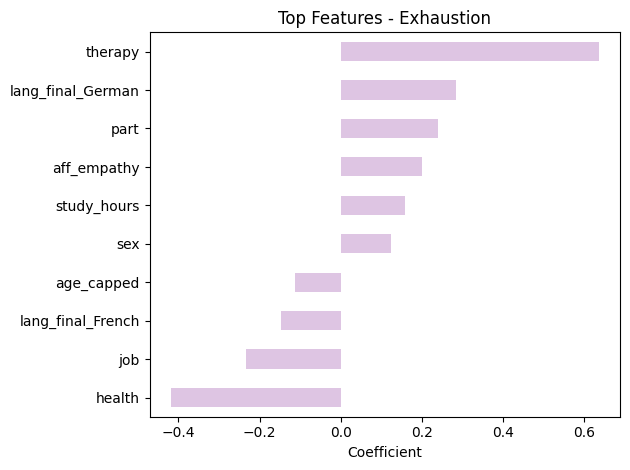

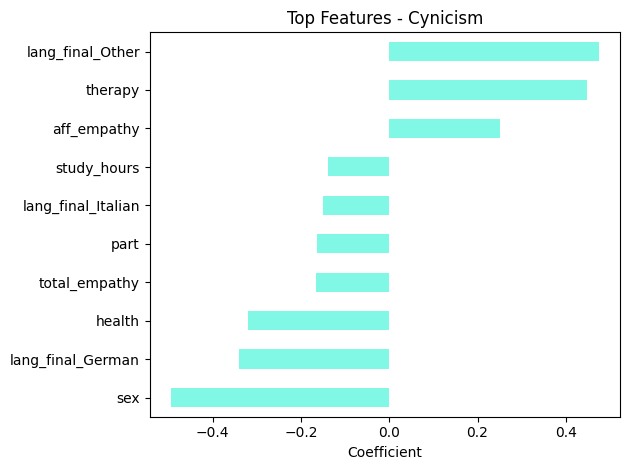

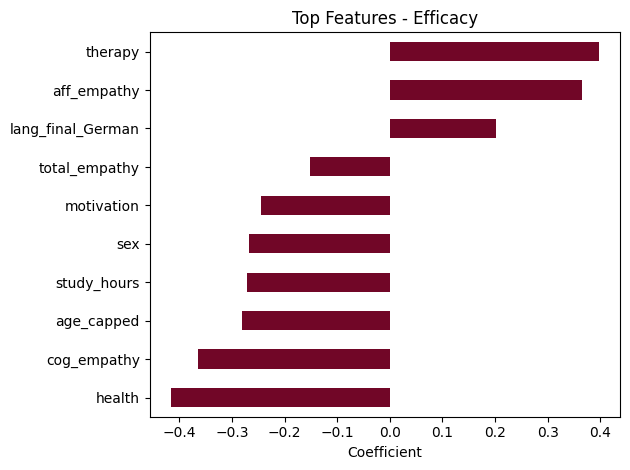

In [ ]:
X_train_selected = X_train[['age_capped', 'year', 'sex', 'lang_final_French',
       'lang_final_German', 'lang_final_Italian', 'lang_final_Other', 'part',
       'job', 'study_hours', 'health', 'therapy', 'total_empathy', 'cog_empathy', 'aff_empathy',
       'motivation', 'emotion_rec_acc']]

clf = LogisticRegression(max_iter=1000)
best_model = MultiOutputClassifier(clf)
best_model.fit(X_train_selected, y_train_burnouts)

labels = ['Exhaustion', 'Cynicism', 'Efficacy']

for i, label in enumerate(labels):
    coefs = best_model.estimators_[i].coef_[0]
    importance = pd.Series(coefs, index=X_train_selected.columns)

    top = importance.sort_values(key=abs, ascending=False).head(10)
    if i == 0:
        color = "#DEC5E3"
    elif i == 1:
        color = "#81F7E5"
    elif i == 2:
        color = "#710627"
    plt.figure()
    top.sort_values().plot(kind='barh', color=color)
    plt.title(f"Top Features - {label}")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

In [ ]:
X_test_selected = X_test[['age_capped', 'year', 'sex', 'lang_final_French',
       'lang_final_German', 'lang_final_Italian', 'lang_final_Other', 'part',
       'job', 'study_hours', 'health', 'therapy', 'total_empathy', 'cog_empathy', 'aff_empathy',
       'motivation', 'emotion_rec_acc']]

y_pred = best_model.predict(X_test_selected)

y_prob = np.column_stack([
    est.predict_proba(X_test_selected)[:, 1]
    for est in best_model.estimators_
])

y_test_exhaustion = (y_test['burnout_exhaustion'] >= 19.44).astype(int)
y_test_cynicism   = (y_test['burnout_cynicism']   >= 12.21).astype(int)
y_test_efficacy   = (y_test['burnout_efficacy']   <= 26.74).astype(int)

for name, target in [('Exhaustion', y_exhaustion),
                      ('Cynicism',   y_cynicism),
                      ('Efficacy',   y_efficacy)]:
    pct = target.value_counts(normalize=True) * 100
    print(f"{name:12s}: {pct[0]:.1f}% not burned out / {pct[1]:.1f}% burned out")

y_test_burnouts = pd.DataFrame({
    'exhaustion': y_test_exhaustion,
    'cynicism':   y_test_cynicism,
    'efficacy':   y_test_efficacy
})

labels = ['Exhaustion', 'Cynicism', 'Efficacy']
aucs = []

for i, label in enumerate(labels):
    print(f"\n{label}")
    print(classification_report(y_test_burnouts.iloc[:, i], y_pred[:, i]))

    auc = roc_auc_score(y_test_burnouts.iloc[:, i], y_prob[:, i])
    aucs.append(auc)

    print(f"AUC: {auc:.4f}")

print("\nMacro AUC:", np.mean(aucs))

Exhaustion  : 70.0% not burned out / 30.0% burned out
Cynicism    : 73.6% not burned out / 26.4% burned out
Efficacy    : 34.2% not burned out / 65.8% burned out

Exhaustion
              precision    recall  f1-score   support

           0       0.74      0.96      0.84       155
           1       0.70      0.21      0.33        66

    accuracy                           0.74       221
   macro avg       0.72      0.59      0.58       221
weighted avg       0.73      0.74      0.68       221

AUC: 0.7075

Cynicism
              precision    recall  f1-score   support

           0       0.74      0.98      0.84       160
           1       0.62      0.08      0.14        61

    accuracy                           0.73       221
   macro avg       0.68      0.53      0.49       221
weighted avg       0.71      0.73      0.65       221

AUC: 0.6115

Efficacy
              precision    recall  f1-score   support

           0       0.45      0.27      0.33        64
           1       

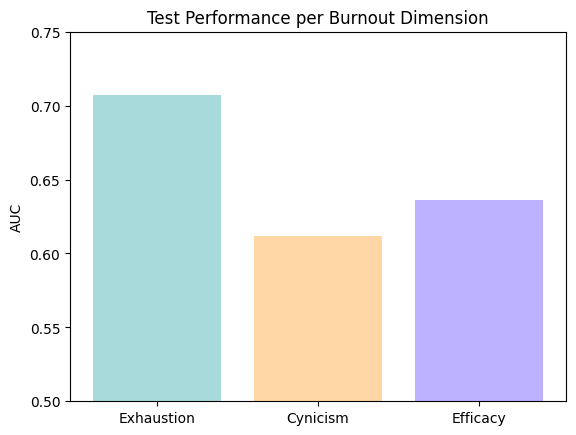

In [ ]:
import matplotlib.pyplot as plt

labels = ['Exhaustion', 'Cynicism', 'Efficacy']
aucs = [0.7075, 0.6115, 0.6364]

plt.bar(labels, aucs, color = ['#A8DADC', '#FFD6A5', '#BDB2FF'])
plt.ylabel("AUC")
plt.title("Test Performance per Burnout Dimension")
plt.ylim(0.5, 0.75)
plt.show()

#### **Classifier Chain**

In [ ]:
from sklearn.multioutput import ClassifierChain
from sklearn.model_selection import KFold


X_train_selected = X_train[['age_capped', 'year', 'sex', 'lang_final_French',
       'lang_final_German', 'lang_final_Italian', 'lang_final_Other', 'part',
       'job', 'study_hours', 'health', 'therapy', 'total_empathy', 'cog_empathy', 'aff_empathy',
       'motivation', 'emotion_rec_acc']]


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "AdaBoost": AdaBoostClassifier(n_estimators=100),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n{name}")

    aucs_all_folds = []

    for train_idx, val_idx in kf.split(X_train_selected):
        X_tr, X_val = X_train_selected.iloc[train_idx], X_train_selected.iloc[val_idx]
        y_tr, y_val = y_train_burnouts.iloc[train_idx], y_train_burnouts.iloc[val_idx]

        chain = ClassifierChain(model, order=[0,1,2], random_state=42)
        chain.fit(X_tr, y_tr)

        # probabilities
        y_prob = np.array(chain.predict_proba(X_val))
        # compute AUC per label
        aucs = []
        for i in range(y_val.shape[1]):
            auc = roc_auc_score(y_val.iloc[:, i], y_prob[:, i])
            aucs.append(auc)

        aucs_all_folds.append(np.mean(aucs))  # macro AUC per fold

    print(f"Classifier Chain Macro AUC: {np.mean(aucs_all_folds):.4f}")


Logistic Regression
Classifier Chain Macro AUC: 0.6386

SVM
Classifier Chain Macro AUC: 0.6300

Random Forest
Classifier Chain Macro AUC: 0.6192

AdaBoost
Classifier Chain Macro AUC: 0.6281


In [ ]:
from sklearn.multioutput import ClassifierChain
from sklearn.model_selection import KFold


X_train_selected = X_train[['age_capped', 'year', 'sex', 'part',
       'job', 'study_hours', 'health', 'therapy', 'total_empathy', 'cog_empathy', 'aff_empathy',
       'motivation', 'emotion_rec_acc']]

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "AdaBoost": AdaBoostClassifier(n_estimators=100),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n{name}")

    aucs_all_folds = []

    for train_idx, val_idx in kf.split(X_train_selected):
        X_tr, X_val = X_train_selected.iloc[train_idx], X_train_selected.iloc[val_idx]
        y_tr, y_val = y_train_burnouts.iloc[train_idx], y_train_burnouts.iloc[val_idx]

        chain = ClassifierChain(model, order=[0,1,2], random_state=42)
        chain.fit(X_tr, y_tr)

        # probabilities
        y_prob = np.array(chain.predict_proba(X_val))
        # compute AUC per label
        aucs = []
        for i in range(y_val.shape[1]):
            auc = roc_auc_score(y_val.iloc[:, i], y_prob[:, i])
            aucs.append(auc)

        aucs_all_folds.append(np.mean(aucs))  # macro AUC per fold

    print(f"Classifier Chain Macro AUC: {np.mean(aucs_all_folds):.4f}")


Logistic Regression
Classifier Chain Macro AUC: 0.6373

SVM
Classifier Chain Macro AUC: 0.6229

Random Forest
Classifier Chain Macro AUC: 0.6318

AdaBoost
Classifier Chain Macro AUC: 0.6352


In [ ]:
from sklearn.multioutput import ClassifierChain
from sklearn.model_selection import KFold

X_train_selected = X_train[["age_group_23_plus", "year", "sex", "part", "job", "health",
                   "study_hours", "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "AdaBoost": AdaBoostClassifier(n_estimators=100),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n{name}")

    aucs_all_folds = []

    for train_idx, val_idx in kf.split(X_train_selected):
        X_tr, X_val = X_train_selected.iloc[train_idx], X_train_selected.iloc[val_idx]
        y_tr, y_val = y_train_burnouts.iloc[train_idx], y_train_burnouts.iloc[val_idx]

        chain = ClassifierChain(model, order=[0,1,2], random_state=42)
        chain.fit(X_tr, y_tr)

        # probabilities
        y_prob = np.array(chain.predict_proba(X_val))
        # compute AUC per label
        aucs = []
        for i in range(y_val.shape[1]):
            auc = roc_auc_score(y_val.iloc[:, i], y_prob[:, i])
            aucs.append(auc)

        aucs_all_folds.append(np.mean(aucs))  # macro AUC per fold

    print(f"Classifier Chain Macro AUC: {np.mean(aucs_all_folds):.4f}")


Logistic Regression
Classifier Chain Macro AUC: 0.6424

SVM
Classifier Chain Macro AUC: 0.6322

Random Forest
Classifier Chain Macro AUC: 0.6223

AdaBoost
Classifier Chain Macro AUC: 0.6321


In [ ]:
from sklearn.multioutput import ClassifierChain
from sklearn.model_selection import KFold

X_train_selected = X_train[["age_group_23_plus", "year", "sex", "part", "job", "health",
                   "study_group_low", "study_group_moderate", "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "AdaBoost": AdaBoostClassifier(n_estimators=100),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n{name}")

    aucs_all_folds = []

    for train_idx, val_idx in kf.split(X_train_selected):
        X_tr, X_val = X_train_selected.iloc[train_idx], X_train_selected.iloc[val_idx]
        y_tr, y_val = y_train_burnouts.iloc[train_idx], y_train_burnouts.iloc[val_idx]

        chain = ClassifierChain(model, order=[0,1,2], random_state=42)
        chain.fit(X_tr, y_tr)

        # probabilities
        y_prob = np.array(chain.predict_proba(X_val))
        # compute AUC per label
        aucs = []
        for i in range(y_val.shape[1]):
            auc = roc_auc_score(y_val.iloc[:, i], y_prob[:, i])
            aucs.append(auc)

        aucs_all_folds.append(np.mean(aucs))  # macro AUC per fold

    print(f"Classifier Chain Macro AUC: {np.mean(aucs_all_folds):.4f}")


Logistic Regression
Classifier Chain Macro AUC: 0.6373

SVM
Classifier Chain Macro AUC: 0.6228

Random Forest
Classifier Chain Macro AUC: 0.6287

AdaBoost
Classifier Chain Macro AUC: 0.6352


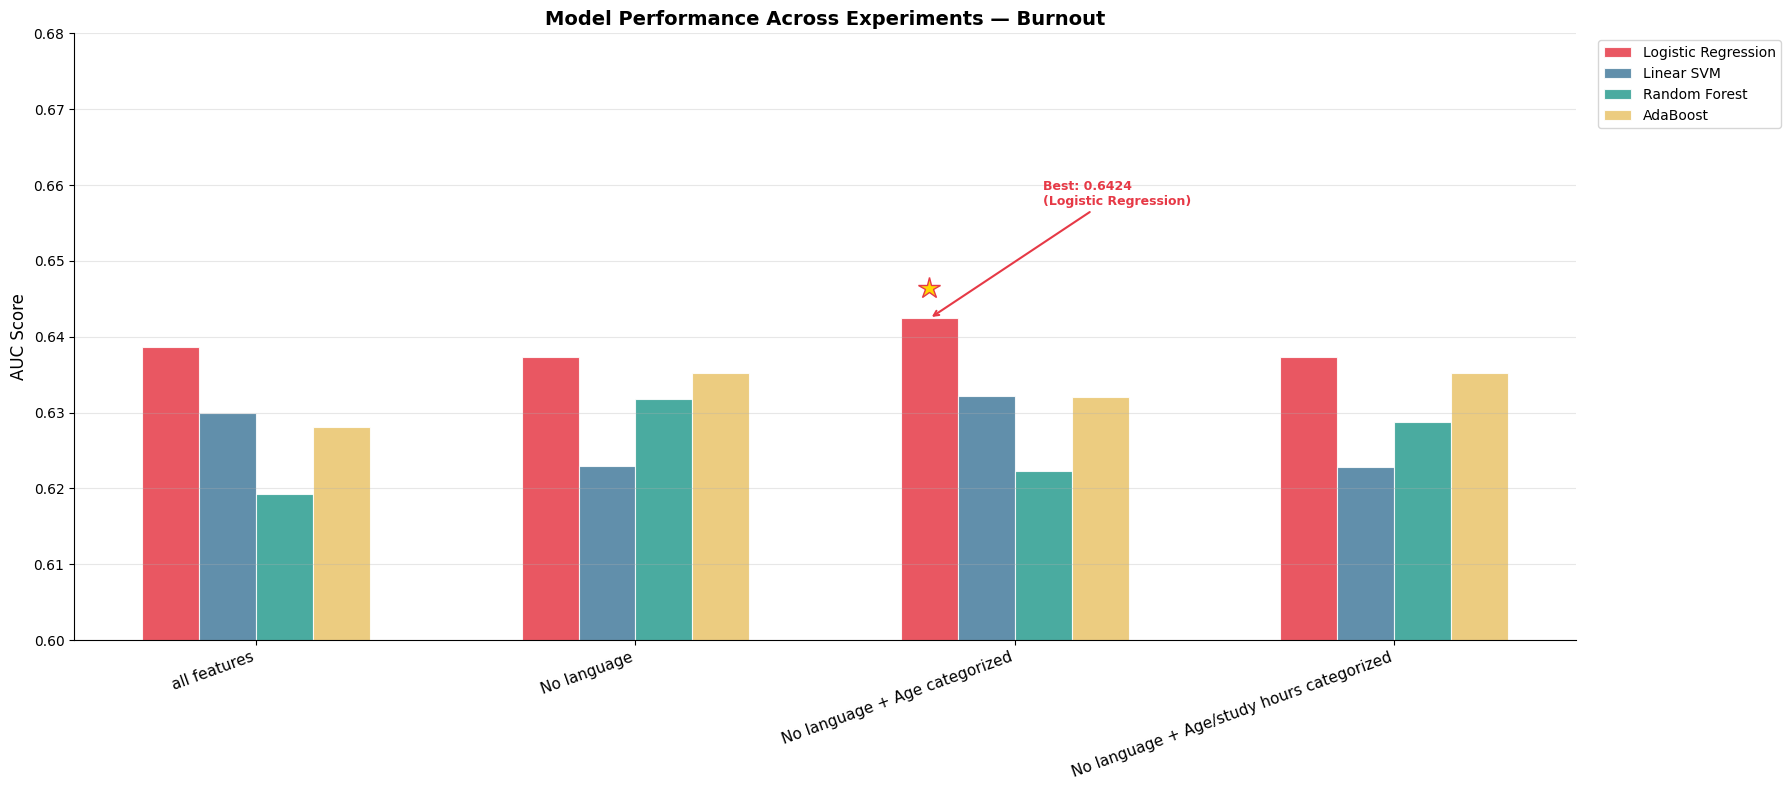

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

experiments = [
    'all features',
    'No language',
    'No language + Age categorized',
    'No language + Age/study hours categorized',
]

models = ["Logistic Regression",
    "Linear SVM",
    "Random Forest",
    "AdaBoost"]
colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#9B5DE5']

auc_results = {
    'Logistic Regression': [0.6386, 0.6373, 0.6424, 0.6373],
    'Linear SVM':          [0.6300, 0.6229, 0.6322, 0.6228],
    'Random Forest':       [0.6192, 0.6318, 0.6223, 0.6287],
    'AdaBoost':            [0.6281, 0.6352, 0.6321, 0.6352],
}
fig, ax = plt.subplots(figsize=(18, 8))
x     = np.arange(len(experiments))
width = 0.15
n     = len(models)

best_auc, best_model_i, best_exp_i = 0, 0, 0
for i, model in enumerate(models):
    for j, auc in enumerate(auc_results[model]):
        if auc > best_auc:
            best_auc, best_model_i, best_exp_i = auc, i, j

for i, (model, color) in enumerate(zip(models, colors)):
    offset = (i - n/2 + 0.5) * width
    ax.bar(x + offset, auc_results[model], width,
           label=model, color=color,
           alpha=0.85, edgecolor='white', linewidth=0.8)

best_x = x[best_exp_i] + (best_model_i - n/2 + 0.5) * width
ax.annotate(
    f'Best: {best_auc:.4f}\n({models[best_model_i]})',
    xy=(best_x, best_auc),
    xytext=(best_x + 0.3, best_auc + 0.015),
    fontsize=9, fontweight='bold', color=colors[best_model_i],
    arrowprops=dict(arrowstyle='->', color=colors[best_model_i], lw=1.5),
)
ax.plot(best_x, best_auc + 0.004, '*',
        markersize=16, color='gold',
        markeredgecolor=colors[best_model_i], markeredgewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(experiments, rotation=20, ha='right', fontsize=11)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_ylim(0.60, 0.68)
ax.set_title('Model Performance Across Experiments — Burnout',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('bo2_experiment_comparison.png', dpi=1000, bbox_inches='tight')
plt.show()

In [ ]:
X_train_selected = X_train[["age_group_23_plus", "year", "sex", "part", "job", "health",
                   "study_hours", "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]


clf = LogisticRegression(max_iter=1000)
chain = ClassifierChain(clf, order=[0,1,2], random_state=42)
best_model = chain.fit(X_train_selected, y_train_burnouts)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score

X_test_selected = X_test[[
    "age_group_23_plus", "year", "sex", "part", "job", "health",
    "study_hours", "therapy", "total_empathy", "cog_empathy",
    "aff_empathy", "motivation", "emotion_rec_acc"
]]

y_pred = best_model.predict(X_test_selected)

# For ClassifierChain
y_prob = np.column_stack(best_model.predict_proba(X_test_selected)).T

y_test_exhaustion = (y_test['burnout_exhaustion'] >= 19.44).astype(int)
y_test_cynicism   = (y_test['burnout_cynicism']   >= 12.21).astype(int)
y_test_efficacy   = (y_test['burnout_efficacy']   <= 26.74).astype(int)

for name, target in [('Exhaustion', y_test_exhaustion),
                     ('Cynicism',   y_test_cynicism),
                     ('Efficacy',   y_test_efficacy)]:
    pct = target.value_counts(normalize=True) * 100
    print(f"{name:12s}: {pct[0]:.1f}% not burned out / {pct[1]:.1f}% burned out")

y_test_burnouts = pd.DataFrame({
    'exhaustion': y_test_exhaustion,
    'cynicism':   y_test_cynicism,
    'efficacy':   y_test_efficacy
})

labels = ['Exhaustion', 'Cynicism', 'Efficacy']
aucs = []


for i, label in enumerate(labels):
    print(f"\n{label}")
    print(classification_report(y_test_burnouts.iloc[:, i], y_pred[:, i]))

    auc = roc_auc_score(y_test_burnouts.iloc[:, i], y_prob[:, i])
    aucs.append(auc)
    print(f"AUC: {auc:.4f}")

print("\nMacro AUC:", np.mean(aucs))

Exhaustion  : 70.1% not burned out / 29.9% burned out
Cynicism    : 72.4% not burned out / 27.6% burned out
Efficacy    : 29.0% not burned out / 71.0% burned out

Exhaustion
              precision    recall  f1-score   support

           0       0.74      0.95      0.83       155
           1       0.65      0.20      0.30        66

    accuracy                           0.73       221
   macro avg       0.69      0.58      0.57       221
weighted avg       0.71      0.73      0.67       221

AUC: 0.6976

Cynicism
              precision    recall  f1-score   support

           0       0.72      0.97      0.83       160
           1       0.17      0.02      0.03        61

    accuracy                           0.71       221
   macro avg       0.44      0.49      0.43       221
weighted avg       0.57      0.71      0.61       221

AUC: 0.6438

Efficacy
              precision    recall  f1-score   support

           0       0.37      0.44      0.40        64
           1       

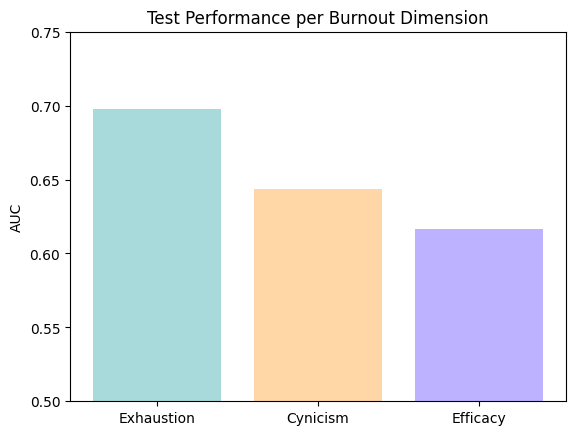

In [ ]:
import matplotlib.pyplot as plt

labels = ['Exhaustion', 'Cynicism', 'Efficacy']
aucs = [0.6976, 0.6438, 0.6162]

plt.bar(labels, aucs, color = ['#A8DADC', '#FFD6A5', '#BDB2FF'])
plt.ylabel("AUC")
plt.title("Test Performance per Burnout Dimension")
plt.ylim(0.5, 0.75)
plt.show()

#### **Burnout Scores Separately**

-----------model: Logistic Regression-----------
mean AUC: 0.6617378673957621
              precision    recall  f1-score   support

           0       0.67      0.60      0.63       382
           1       0.52      0.58      0.55       278

    accuracy                           0.60       660
   macro avg       0.59      0.59      0.59       660
weighted avg       0.60      0.60      0.60       660


Top 10 features:
health               0.426104
therapy              0.422022
aff_empathy          0.299391
study_group_low      0.203286
sex                  0.197463
year                 0.181111
part                 0.174848
age_group_23_plus    0.156860
emotion_rec_acc      0.063307
total_empathy        0.048551
dtype: float64


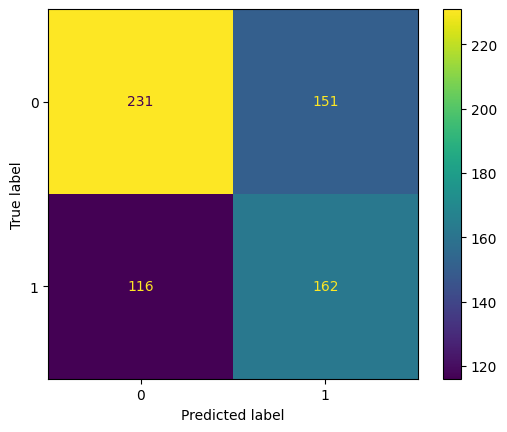

-----------model: Linear SVM-----------
mean AUC: 0.6586833561175666
              precision    recall  f1-score   support

           0       0.67      0.63      0.65       382
           1       0.53      0.58      0.55       278

    accuracy                           0.61       660
   macro avg       0.60      0.60      0.60       660
weighted avg       0.61      0.61      0.61       660


Top 10 features:
therapy                 0.572236
health                  0.506692
aff_empathy             0.386089
part                    0.380537
study_group_low         0.361910
year                    0.180156
age_group_23_plus       0.170553
sex                     0.135113
study_group_moderate    0.106604
emotion_rec_acc         0.088393
dtype: float64


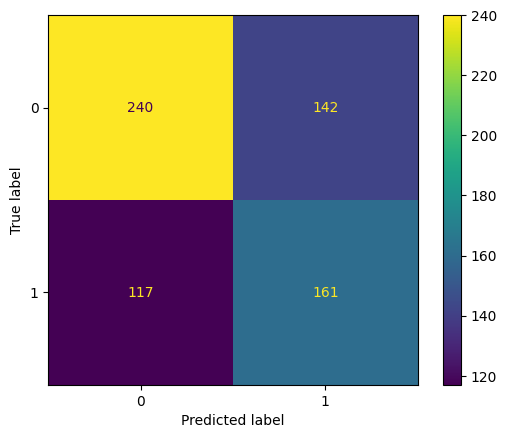

-----------model: Random Forest-----------
mean AUC: 0.6378421518672714
              precision    recall  f1-score   support

           0       0.64      0.69      0.66       382
           1       0.52      0.46      0.49       278

    accuracy                           0.60       660
   macro avg       0.58      0.58      0.58       660
weighted avg       0.59      0.60      0.59       660


Top 10 features:
aff_empathy        0.139937
cog_empathy        0.126975
total_empathy      0.126491
motivation         0.125672
health             0.119354
emotion_rec_acc    0.106683
year               0.082053
therapy            0.031457
job                0.025545
study_group_low    0.025112
dtype: float64


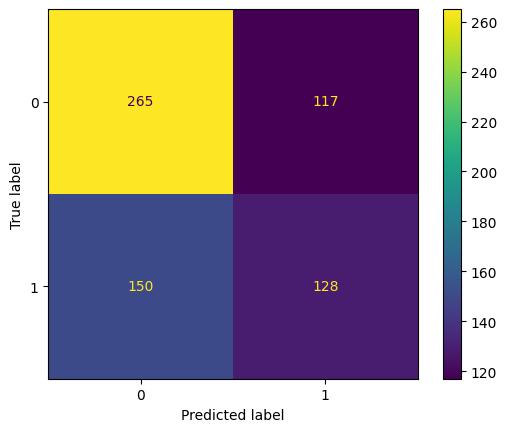

-----------model: AdaBoost-----------
mean AUC: 0.6724205011495681
              precision    recall  f1-score   support

           0       0.65      0.75      0.70       382
           1       0.57      0.45      0.50       278

    accuracy                           0.62       660
   macro avg       0.61      0.60      0.60       660
weighted avg       0.62      0.62      0.61       660


Top 10 features:
health               0.244234
total_empathy        0.181840
aff_empathy          0.164774
motivation           0.145539
emotion_rec_acc      0.114286
year                 0.087068
therapy              0.039839
cog_empathy          0.022420
sex                  0.000000
age_group_23_plus    0.000000
dtype: float64


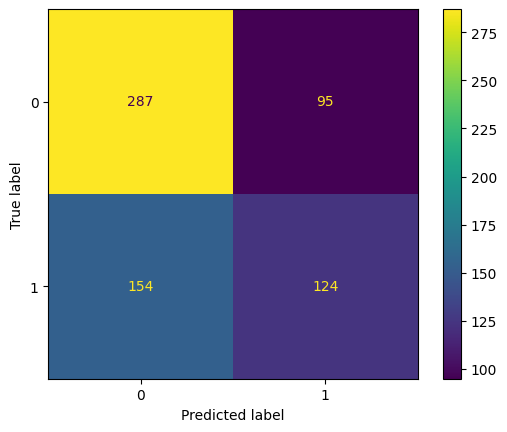

-----------model: XGBoost-----------
mean AUC: 0.6561206735847884
              precision    recall  f1-score   support

           0       0.66      0.73      0.69       382
           1       0.57      0.48      0.52       278

    accuracy                           0.63       660
   macro avg       0.61      0.61      0.61       660
weighted avg       0.62      0.63      0.62       660


Top 10 features:
health                  0.143843
therapy                 0.080431
sex                     0.078412
year                    0.077882
aff_empathy             0.074338
cog_empathy             0.068051
motivation              0.067673
part                    0.065371
study_group_moderate    0.064097
study_group_low         0.063021
dtype: float32


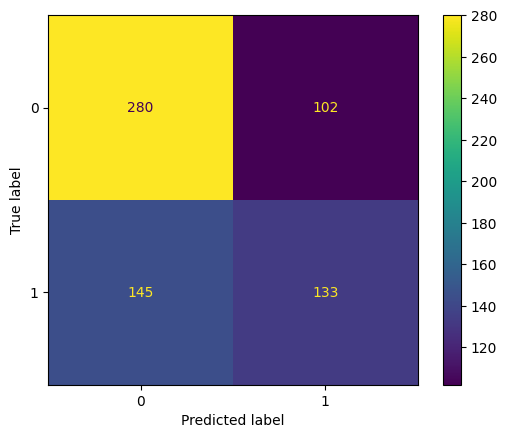

In [ ]:

X_train_selected = X_train[["age_group_23_plus", "year", "sex", "part", "job", "health",
                   "study_group_low", "study_group_moderate", "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]

for name, clf in zip(names, classifiers):
    clf_train(clf, name, X_train_selected, y_exhaustion)

-----------model: Logistic Regression-----------
mean AUC: 0.5901507764615797
              precision    recall  f1-score   support

           0       0.66      0.62      0.64       393
           1       0.49      0.54      0.52       267

    accuracy                           0.59       660
   macro avg       0.58      0.58      0.58       660
weighted avg       0.59      0.59      0.59       660


Top 10 features:
therapy              0.339452
health               0.278765
aff_empathy          0.230436
age_group_23_plus    0.201435
sex                  0.187918
total_empathy        0.161389
study_group_low      0.106584
job                  0.095683
emotion_rec_acc      0.094572
part                 0.074620
dtype: float64


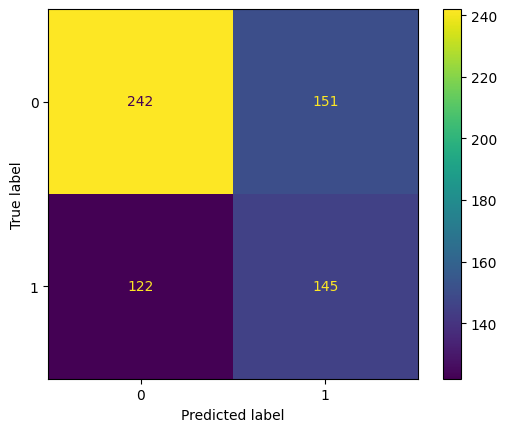

-----------model: Linear SVM-----------
mean AUC: 0.5884993482517565
              precision    recall  f1-score   support

           0       0.66      0.63      0.65       393
           1       0.49      0.52      0.51       267

    accuracy                           0.59       660
   macro avg       0.58      0.58      0.58       660
weighted avg       0.59      0.59      0.59       660


Top 10 features:
therapy              0.577636
health               0.455459
aff_empathy          0.354465
total_empathy        0.303855
sex                  0.288867
age_group_23_plus    0.272181
part                 0.159111
job                  0.091983
emotion_rec_acc      0.086956
year                 0.063049
dtype: float64


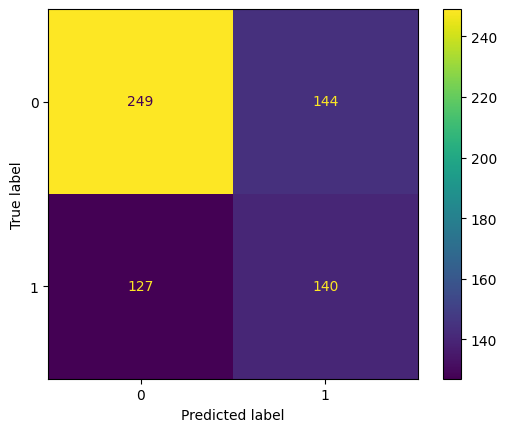

-----------model: Random Forest-----------
mean AUC: 0.5215545630202107
              precision    recall  f1-score   support

           0       0.59      0.70      0.64       393
           1       0.40      0.30      0.34       267

    accuracy                           0.54       660
   macro avg       0.50      0.50      0.49       660
weighted avg       0.52      0.54      0.52       660


Top 10 features:
total_empathy      0.145241
aff_empathy        0.140997
cog_empathy        0.137249
motivation         0.124862
emotion_rec_acc    0.112765
health             0.090899
year               0.074503
part               0.030868
therapy            0.029411
job                0.028258
dtype: float64


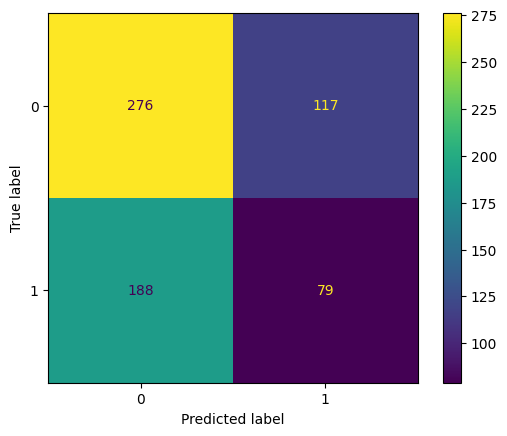

-----------model: AdaBoost-----------
mean AUC: 0.5825721476346427
              precision    recall  f1-score   support

           0       0.64      0.79      0.70       393
           1       0.52      0.34      0.41       267

    accuracy                           0.60       660
   macro avg       0.58      0.56      0.56       660
weighted avg       0.59      0.60      0.58       660


Top 10 features:
cog_empathy          0.396798
health               0.221227
aff_empathy          0.145029
emotion_rec_acc      0.088012
year                 0.044419
therapy              0.042680
sex                  0.032648
total_empathy        0.029188
age_group_23_plus    0.000000
part                 0.000000
dtype: float64


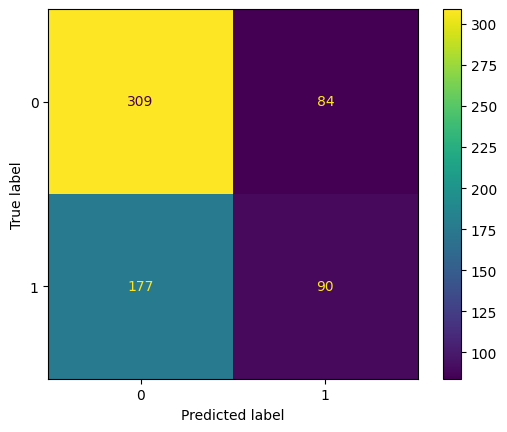

-----------model: XGBoost-----------
mean AUC: 0.5548282330942947
              precision    recall  f1-score   support

           0       0.61      0.79      0.69       393
           1       0.46      0.27      0.34       267

    accuracy                           0.58       660
   macro avg       0.54      0.53      0.52       660
weighted avg       0.55      0.58      0.55       660


Top 10 features:
health                  0.122257
therapy                 0.085546
year                    0.079281
aff_empathy             0.077885
age_group_23_plus       0.072752
motivation              0.071391
total_empathy           0.070812
emotion_rec_acc         0.069376
cog_empathy             0.068509
study_group_moderate    0.066216
dtype: float32


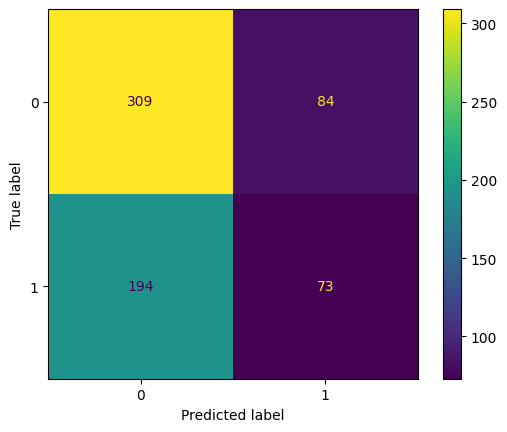

In [ ]:
X_train_selected = X_train[["age_group_23_plus", "year", "sex", "part", "job", "health",
                   "study_group_low", "study_group_moderate", "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]

for name, clf in zip(names, classifiers):
    clf_train(clf, name, X_train_selected, y_cynicism)

-----------model: Logistic Regression-----------
mean AUC: 0.6748341670291431
              precision    recall  f1-score   support

           0       0.56      0.66      0.60       277
           1       0.72      0.62      0.67       383

    accuracy                           0.64       660
   macro avg       0.64      0.64      0.64       660
weighted avg       0.65      0.64      0.64       660


Top 10 features:
health               0.438004
aff_empathy          0.324638
age_group_23_plus    0.310391
therapy              0.292019
study_group_low      0.290329
cog_empathy          0.203141
motivation           0.202816
part                 0.192020
total_empathy        0.183444
sex                  0.173014
dtype: float64


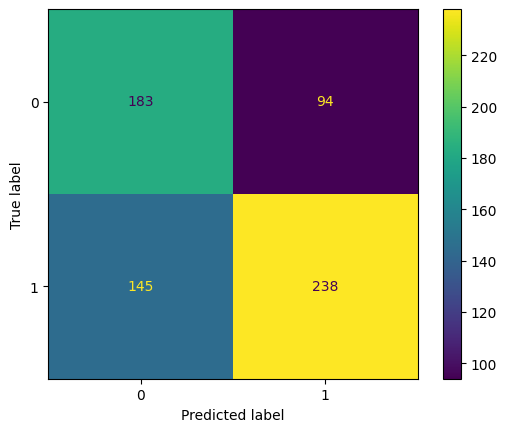

-----------model: Linear SVM-----------
mean AUC: 0.667903436276642
              precision    recall  f1-score   support

           0       0.55      0.66      0.60       277
           1       0.71      0.60      0.65       383

    accuracy                           0.63       660
   macro avg       0.63      0.63      0.63       660
weighted avg       0.64      0.63      0.63       660


Top 10 features:
health               0.590537
aff_empathy          0.419168
age_group_23_plus    0.385610
therapy              0.363932
part                 0.342191
study_group_low      0.267706
motivation           0.261542
total_empathy        0.218483
cog_empathy          0.195081
sex                  0.175283
dtype: float64


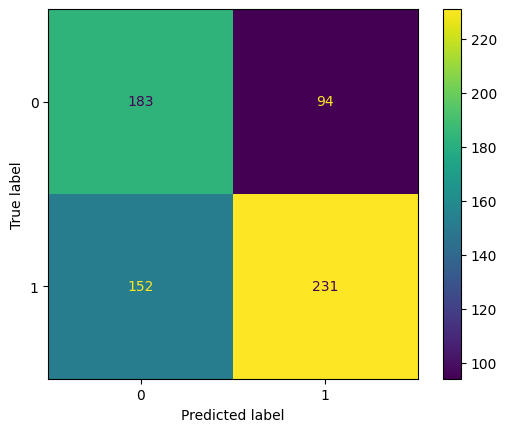

-----------model: Random Forest-----------
mean AUC: 0.6322416578636674
              precision    recall  f1-score   support

           0       0.53      0.41      0.46       277
           1       0.63      0.74      0.68       383

    accuracy                           0.60       660
   macro avg       0.58      0.58      0.57       660
weighted avg       0.59      0.60      0.59       660


Top 10 features:
total_empathy           0.140818
aff_empathy             0.138932
cog_empathy             0.137974
motivation              0.129856
emotion_rec_acc         0.110244
health                  0.109879
year                    0.061035
therapy                 0.031261
study_group_moderate    0.025213
sex                     0.025000
dtype: float64


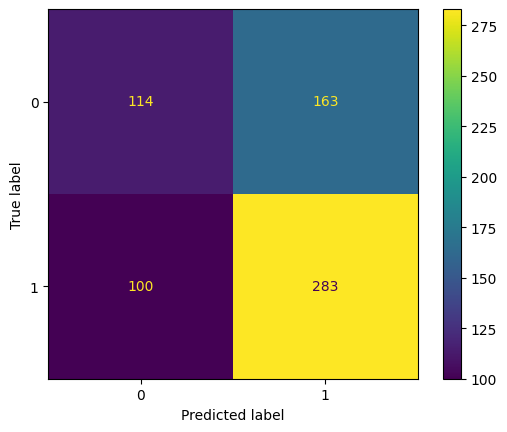

-----------model: AdaBoost-----------
mean AUC: 0.6564329988193625
              precision    recall  f1-score   support

           0       0.58      0.45      0.51       277
           1       0.66      0.76      0.70       383

    accuracy                           0.63       660
   macro avg       0.62      0.61      0.61       660
weighted avg       0.62      0.63      0.62       660


Top 10 features:
aff_empathy          0.212583
health               0.155336
total_empathy        0.151324
emotion_rec_acc      0.123189
motivation           0.092460
cog_empathy          0.071523
therapy              0.044316
year                 0.042051
age_group_23_plus    0.035821
part                 0.027450
dtype: float64


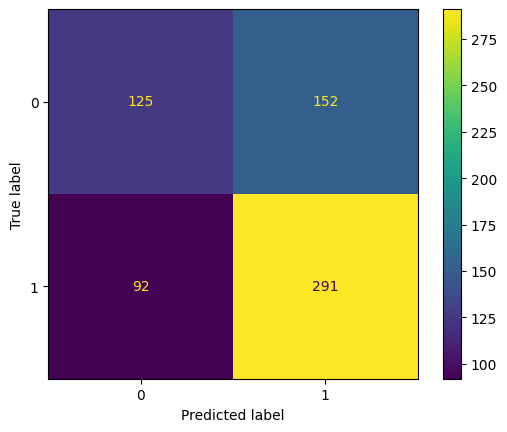

-----------model: XGBoost-----------
mean AUC: 0.6346501584539862
              precision    recall  f1-score   support

           0       0.57      0.42      0.48       277
           1       0.65      0.77      0.70       383

    accuracy                           0.62       660
   macro avg       0.61      0.59      0.59       660
weighted avg       0.61      0.62      0.61       660


Top 10 features:
health                  0.153981
cog_empathy             0.078082
aff_empathy             0.075110
total_empathy           0.073937
motivation              0.073465
therapy                 0.065177
sex                     0.063750
study_group_low         0.062712
study_group_moderate    0.061113
age_group_23_plus       0.059970
dtype: float32


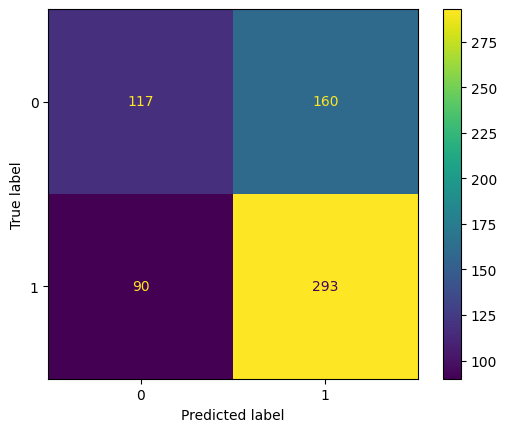

In [ ]:

X_train_selected = X_train[["age_group_23_plus", "year", "sex", "part", "job", "health",
                   "study_group_low", "study_group_moderate", "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]

for name, clf in zip(names, classifiers):
    clf_train(clf, name, X_train_selected, y_efficacy)

#### **Outliers**

In [ ]:
import pandas as pd

outlier_data = []
numeric_cols = X_train_orig[['study_hours', 'total_empathy', 'cog_empathy', 'aff_empathy', 'motivation',
       'emotion_rec_acc']]

for col in numeric_cols:
    Q1 = X_train_orig[col].quantile(0.25)
    Q3 = X_train_orig[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((X_train_orig[col] < lower_bound) | (X_train_orig[col] > upper_bound)).sum()
    percentage = (outliers_count / len(X_train_orig)) * 100

    outlier_data.append({
        'Variable': col,
        'Outlier Count': outliers_count,
        'Percentage (%)': round(percentage, 2)
    })
outlier_report = pd.DataFrame(outlier_data).sort_values(by='Percentage (%)', ascending=False)

print("--- Outlier Analysis ---")
print(outlier_report)

--- Outlier Analysis ---
          Variable  Outlier Count  Percentage (%)
5  emotion_rec_acc             10            1.52
1    total_empathy              9            1.36
2      cog_empathy              5            0.76
4       motivation              2            0.30
3      aff_empathy              1            0.15
0      study_hours              0            0.00


In [ ]:
X_train_capped = X_train_orig.copy()

for col in numeric_cols.columns:
    Q1 = X_train_orig[col].quantile(0.25)
    Q3 = X_train_orig[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    X_train_capped[col] = X_train_orig[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    print(f"{col:20s} | bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")

print(f"\nBefore capping:")
print(X_train_orig[numeric_cols.columns].describe().loc[['min', 'max']])
print(f"\nAfter capping:")
print(X_train_capped[numeric_cols.columns].describe().loc[['min', 'max']])

study_hours          | bounds: [-26.50, 73.50]
total_empathy        | bounds: [83.00, 131.00]
cog_empathy          | bounds: [40.50, 76.50]
aff_empathy          | bounds: [19.00, 51.00]
motivation           | bounds: [9.50, 37.50]
emotion_rec_acc      | bounds: [0.49, 0.96]

Before capping:
     study_hours  total_empathy  cog_empathy  aff_empathy  motivation  \
min          0.0           67.0         37.0         18.0         6.0   
max         70.0          125.0         75.0         48.0        35.0   

     emotion_rec_acc  
min         0.404762  
max         0.952381  

After capping:
     study_hours  total_empathy  cog_empathy  aff_empathy  motivation  \
min          0.0           83.0         40.5         19.0         9.5   
max         70.0          125.0         75.0         48.0        35.0   

     emotion_rec_acc  
min         0.488095  
max         0.952381  


In [ ]:
X_test_capped = X_test_orig.copy()

for col in numeric_cols.columns:
    Q1 = X_train_orig[col].quantile(0.25)
    Q3 = X_train_orig[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    X_test_capped[col] = X_test_orig[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_capped[num_cols] = scaler.fit_transform(X_train_capped[num_cols])
X_test_capped[num_cols] = scaler.transform(X_test_capped[num_cols])

In [ ]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

X_train_selected = X_train_capped[["age_group_23_plus", "year", "sex", "part", "job", "health",
                   "study_group_low", "study_group_moderate", "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]

# classifier = MultiOutputClassifier(
#     SVC(kernel='linear', C=0.01, probability=True,
#         class_weight='balanced', random_state=42)
# )


classifier = MultiOutputClassifier(LogisticRegression(max_iter=1000, class_weight='balanced'))
classifier.fit(X_train_selected, y_train_burnouts)
y_pred = cross_val_predict(classifier, X_train_selected, y_train_burnouts, cv=5)

for i, col in enumerate(y_train_burnouts.columns):
    print(f"\n{'='*40}")
    print(f"  {col.upper()}")
    print(f"{'='*40}")
    print(classification_report(
        y_train_burnouts[col],
        y_pred[:, i],
        target_names=['No burnout', 'Burnout']
    ))
    auc = roc_auc_score(y_train_burnouts[col], y_pred[:, i])
    print(f"AUC: {auc:.4f}")


  EXHAUSTION
              precision    recall  f1-score   support

  No burnout       0.68      0.62      0.65       382
     Burnout       0.53      0.59      0.56       278

    accuracy                           0.61       660
   macro avg       0.60      0.61      0.60       660
weighted avg       0.61      0.61      0.61       660

AUC: 0.6052

  CYNICISM
              precision    recall  f1-score   support

  No burnout       0.66      0.61      0.63       393
     Burnout       0.48      0.53      0.50       267

    accuracy                           0.58       660
   macro avg       0.57      0.57      0.57       660
weighted avg       0.59      0.58      0.58       660

AUC: 0.5700

  EFFICACY
              precision    recall  f1-score   support

  No burnout       0.54      0.64      0.59       277
     Burnout       0.70      0.61      0.65       383

    accuracy                           0.62       660
   macro avg       0.62      0.62      0.62       660
weighted avg

-----------model: Logistic Regression-----------
mean AUC: 0.7564481122589582
              precision    recall  f1-score   support

           0       0.72      0.67      0.69       351
           1       0.65      0.70      0.68       309

    accuracy                           0.68       660
   macro avg       0.69      0.69      0.68       660
weighted avg       0.69      0.68      0.69       660


Top 10 features:
therapy              0.661552
aff_empathy          0.538454
health               0.392946
sex                  0.356436
motivation           0.315354
study_group_low      0.234125
cog_empathy          0.183792
job                  0.131815
total_empathy        0.119569
age_group_23_plus    0.105664
dtype: float64


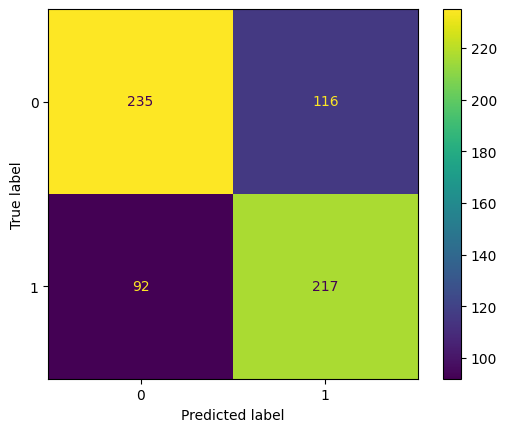

-----------model: Linear SVM-----------
mean AUC: 0.7527132865942349
              precision    recall  f1-score   support

           0       0.71      0.69      0.70       351
           1       0.66      0.68      0.67       309

    accuracy                           0.69       660
   macro avg       0.69      0.69      0.69       660
weighted avg       0.69      0.69      0.69       660


Top 10 features:
therapy                 0.618502
aff_empathy             0.605525
health                  0.393569
motivation              0.359634
sex                     0.357225
study_group_low         0.272907
cog_empathy             0.196664
study_group_moderate    0.133825
age_group_23_plus       0.124434
total_empathy           0.116237
dtype: float64


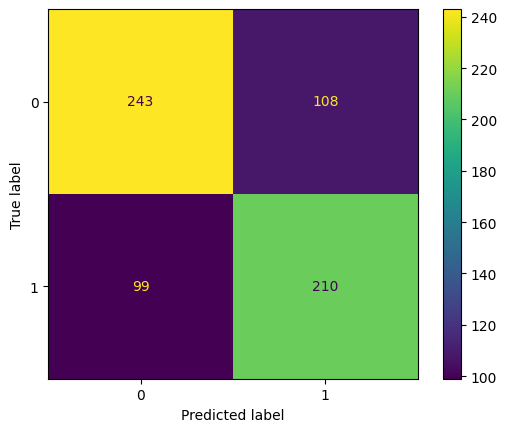

-----------model: Random Forest-----------
mean AUC: 0.7177234959199936
              precision    recall  f1-score   support

           0       0.67      0.70      0.68       351
           1       0.64      0.60      0.62       309

    accuracy                           0.65       660
   macro avg       0.65      0.65      0.65       660
weighted avg       0.65      0.65      0.65       660


Top 10 features:
aff_empathy        0.158276
motivation         0.130692
total_empathy      0.121951
cog_empathy        0.113990
emotion_rec_acc    0.107905
health             0.105687
year               0.064811
therapy            0.056611
sex                0.035636
job                0.025153
dtype: float64


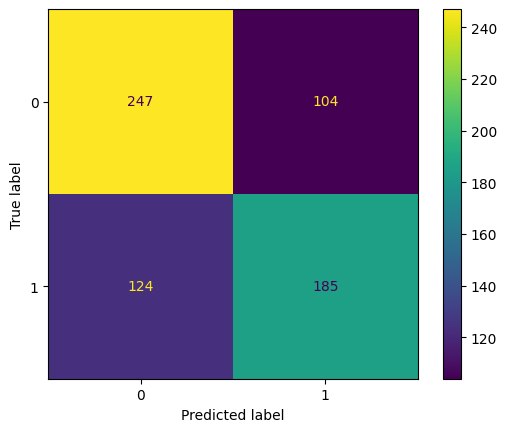

-----------model: AdaBoost-----------
mean AUC: 0.7428538816186383
              precision    recall  f1-score   support

           0       0.70      0.75      0.72       351
           1       0.69      0.63      0.66       309

    accuracy                           0.69       660
   macro avg       0.69      0.69      0.69       660
weighted avg       0.69      0.69      0.69       660


Top 10 features:
motivation         0.267551
aff_empathy        0.176254
health             0.148143
emotion_rec_acc    0.111789
therapy            0.099166
total_empathy      0.098196
cog_empathy        0.047873
study_group_low    0.029115
sex                0.021912
year               0.000000
dtype: float64


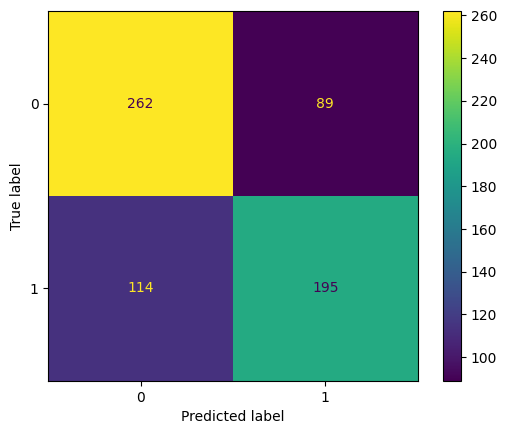

-----------model: XGBoost-----------
mean AUC: 0.7446388111854629
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       351
           1       0.67      0.63      0.65       309

    accuracy                           0.68       660
   macro avg       0.68      0.68      0.68       660
weighted avg       0.68      0.68      0.68       660


Top 10 features:
sex                     0.134960
therapy                 0.134067
health                  0.129871
aff_empathy             0.082413
motivation              0.073950
cog_empathy             0.057578
study_group_moderate    0.055233
emotion_rec_acc         0.052419
year                    0.051813
total_empathy           0.051001
dtype: float32


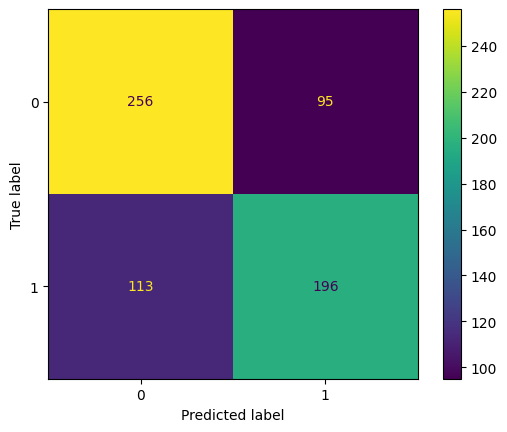

In [ ]:
X_train_selected = X_train_capped[["age_group_23_plus", "year", "sex", "part", "job", "health",
                   "study_group_low", "study_group_moderate", "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]]

for name, clf in zip(names, classifiers):
    clf_train(clf, name, X_train_selected, y_train_anxiety)